In [25]:
# ============================================================
# FULL LASSO + ELASTIC NET ANALYSIS
# ── Short (13 vars — EEG theory) vs Full (31 vars — robustness)
# ── 6 sectors × 6 outcomes × 2 models = 72 models per spec
# ── Evaluation metrics for comparison with Random Forest
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import warnings
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV, ElasticNetCV
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import r2_score
import statsmodels.api as sm

warnings.filterwarnings("ignore")
print("✅ Imports OK")

✅ Imports OK


In [26]:
# ============================================================
# 0. LOAD DATA
# ============================================================

df = pd.read_parquet(
    "G:/Mi unidad/Master_LSE/Git-hub/Economic_Observatory/"
    "data/processed_data/analysis_panel.parquet",
    engine="fastparquet"
)
df.columns = df.columns.str.strip().str.lower()
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

Loaded: 16,576 rows × 35 columns


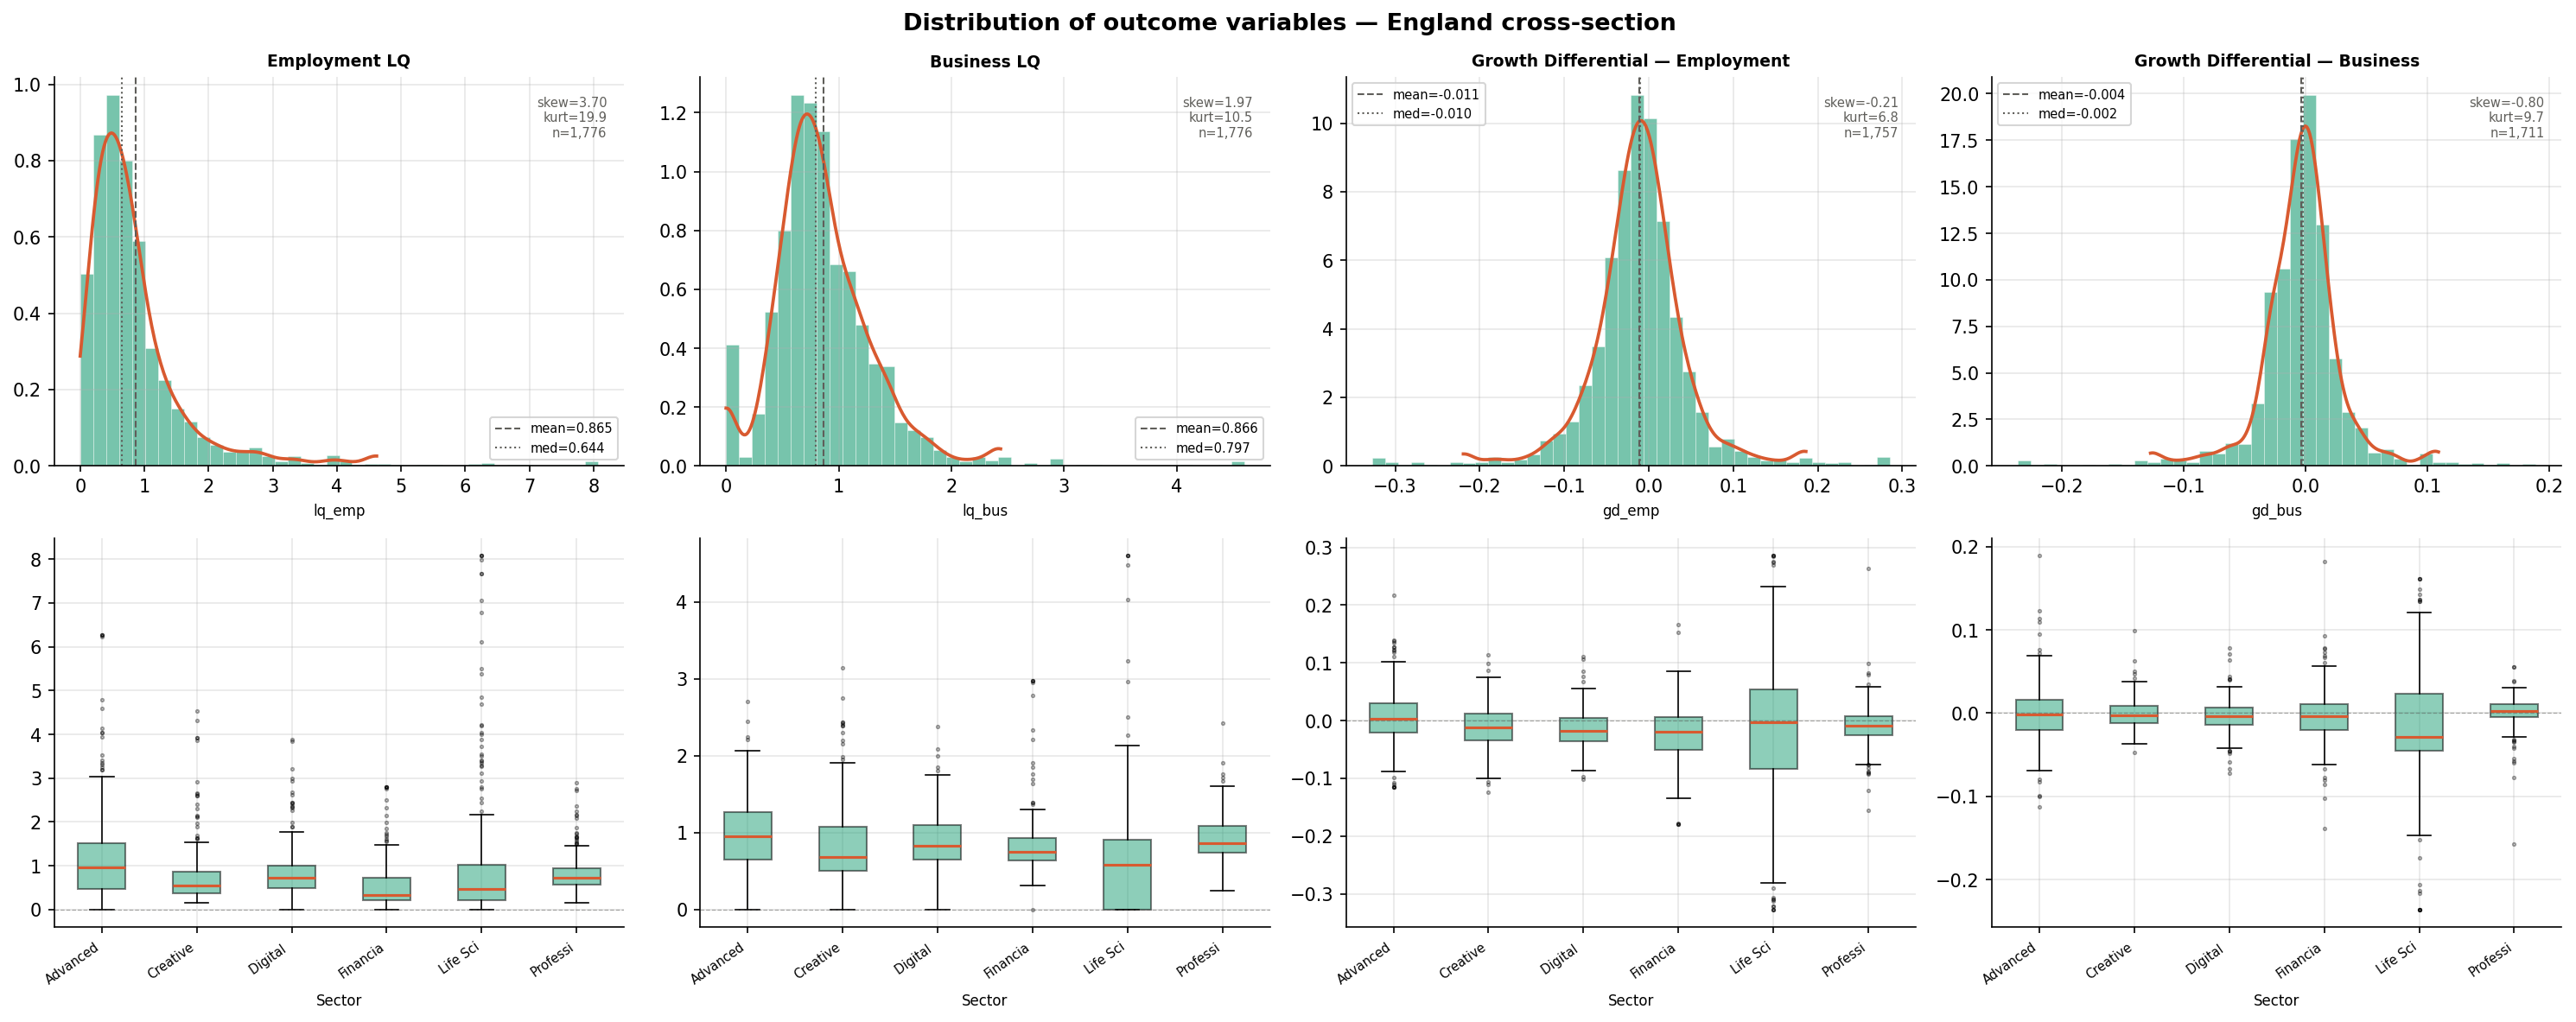

Saved → G:\Mi unidad\Master_LSE\Git-hub\Economic_Observatory\output\Diane_final_version/outcome_distributions_fv.png


In [27]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle("Distribution of outcome variables — England cross-section",
             fontsize=13, fontweight="bold")

OUTCOMES_PLOT = ["lq_emp", "lq_bus", "gd_emp", "gd_bus"]
LABELS = {
    "lq_emp": "Employment LQ",
    "lq_bus": "Business LQ",
    "gd_emp": "Growth Differential — Employment",
    "gd_bus": "Growth Differential — Business",
}

for col_idx, var in enumerate(OUTCOMES_PLOT):
    s = df_cs[var].dropna()

    # ── Row 1: histogram + KDE ────────────────────────────────
    ax1 = axes[0, col_idx]
    ax1.hist(s, bins=40, color="#1D9E75", alpha=0.6,
             edgecolor="white", linewidth=0.3, density=True)
    xmin, xmax = s.quantile(0.01), s.quantile(0.99)
    xs = np.linspace(xmin, xmax, 200)
    kde = stats.gaussian_kde(s.clip(xmin, xmax))
    ax1.plot(xs, kde(xs), color="#D85A30", linewidth=1.8)
    ax1.axvline(s.mean(),   color="#5F5E5A", linewidth=1,
                linestyle="--", label=f"mean={s.mean():.3f}")
    ax1.axvline(s.median(), color="#5F5E5A", linewidth=1,
                linestyle=":",  label=f"med={s.median():.3f}")
    ax1.set_title(LABELS[var], fontsize=9, fontweight="bold")
    ax1.set_xlabel(var, fontsize=8)
    ax1.legend(fontsize=7)
    ax1.text(0.97, 0.95,
             f"skew={s.skew():.2f}\nkurt={s.kurtosis():.1f}\nn={len(s):,}",
             transform=ax1.transAxes, fontsize=7,
             ha="right", va="top", color="#5F5E5A")

    # ── Row 2: boxplot by sector ──────────────────────────────
    ax2 = axes[1, col_idx]
    sector_data = [
        df_cs.loc[df_cs["is8_sector"] == sec, var].dropna().values
        for sec in SECTORS
    ]
    bp = ax2.boxplot(sector_data, vert=True, patch_artist=True,
                     medianprops=dict(color="#D85A30", linewidth=1.5),
                     whiskerprops=dict(linewidth=0.8),
                     capprops=dict(linewidth=0.8),
                     flierprops=dict(marker=".", markersize=3,
                                     alpha=0.4, color="#5F5E5A"))
    for patch in bp["boxes"]:
        patch.set_facecolor("#1D9E75")
        patch.set_alpha(0.5)
    short_names = [s[:8] for s in SECTORS]
    ax2.set_xticks(range(1, len(SECTORS)+1))
    ax2.set_xticklabels(short_names, rotation=35,
                        ha="right", fontsize=7)
    ax2.axhline(0, color="#5F5E5A", linewidth=0.6,
                linestyle="--", alpha=0.5)
    ax2.set_xlabel("Sector", fontsize=8)

plt.tight_layout()
plt.savefig(
    OUT_ROOT / "outcome_distributions_fv.png",
    dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {OUT_ROOT}/outcome_distributions_fv.png")

In [28]:
import pandas as pd
import numpy as np

print("=" * 65)
print("RAW VARIABLE DIAGNOSTICS")
print("=" * 65)

# 1. Observation counts per outcome
print("\n── Observation counts per outcome ──")
for var in ["lq_emp", "lq_bus", "gd_emp", "gd_bus"]:
    s = df_cs[var].dropna()
    print(f"  {var:10s} n={len(s):4d} | "
          f"mean={s.mean():7.4f} | "
          f"std={s.std():6.4f} | "
          f"min={s.min():7.4f} | "
          f"max={s.max():6.4f}")

# 2. Raw employees and businesses counts
print("\n── Raw employee and business counts ──")
for var in ["employees", "businesses"]:
    if var in df_cs.columns:
        s = df_cs[var].dropna()
        print(f"  {var:15s} n={len(s):4d} | "
              f"mean={s.mean():10.1f} | "
              f"std={s.std():10.1f} | "
              f"min={s.min():6.0f} | "
              f"max={s.max():8.0f}")

# 3. Cross-tab: n_years available per sector (explains GD nulls)
print("\n── Years of data available per sector (drives GD nulls) ──")
if "n_years_emp" in df_cs.columns:
    print("\n  n_years_emp distribution:")
    print(df_cs.groupby("is8_sector")["n_years_emp"]
          .describe()[["count","mean","min","max"]]
          .round(1).to_string())

if "n_years_bus" in df_cs.columns:
    print("\n  n_years_bus distribution:")
    print(df_cs.groupby("is8_sector")["n_years_bus"]
          .describe()[["count","mean","min","max"]]
          .round(1).to_string())

# 4. Size of activity — what % of LADs have very small counts
print("\n── Share of LADs with small business/employee base ──")
for var in ["employees", "businesses"]:
    if var in df_cs.columns:
        s = df_cs[var].dropna()
        for threshold in [100, 500, 1000]:
            pct = (s < threshold).mean() * 100
            print(f"  {var} < {threshold:5d}: {pct:.1f}% of LADs")

# 5. Correlation between raw size and GD values
print("\n── Correlation: raw size vs growth differential ──")
for size_var in ["employees", "businesses"]:
    for gd_var in ["gd_emp", "gd_bus"]:
        if size_var in df_cs.columns and gd_var in df_cs.columns:
            r = df_cs[[size_var, gd_var]].dropna().corr().iloc[0,1]
            print(f"  corr({size_var}, {gd_var}) = {r:.4f}")

RAW VARIABLE DIAGNOSTICS

── Observation counts per outcome ──
  lq_emp     n=1776 | mean= 0.8653 | std=0.9006 | min= 0.0000 | max=8.0725
  lq_bus     n=1776 | mean= 0.8655 | std=0.4797 | min= 0.0000 | max=4.5992
  gd_emp     n=1757 | mean=-0.0112 | std=0.0615 | min=-0.3275 | max=0.2853
  gd_bus     n=1711 | mean=-0.0038 | std=0.0368 | min=-0.2362 | max=0.1889

── Raw employee and business counts ──
  employees       n=1776 | mean=    6343.9 | std=   18664.4 | min=     0 | max=  383800
  businesses      n=1776 | mean=     787.8 | std=    1547.6 | min=     0 | max=   25105

── Years of data available per sector (drives GD nulls) ──

  n_years_emp distribution:
                                    count  mean  min  max
is8_sector                                               
Advanced Manufacturing              296.0   8.0  1.0  8.0
Creative Industries                 296.0   8.0  8.0  8.0
Defence                               0.0   NaN  NaN  NaN
Digital and Technologies            296.0 

In [29]:
 # ============================================================
# 01_METHODOLOGY ASSUMPTIONS, DELETIONS & WARNINGS
# ── Run this cell to export the Excel feasibility document ──
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

OUT_DIR = Path(r"G:\Mi unidad\Master_LSE\Git-hub\Economic_Observatory\output\Diane_final_version")
OUT_DIR.mkdir(exist_ok=True)
# ============================================================
# A. STAGE-BY-STAGE ASSUMPTIONS
# ============================================================
stages = [
    {
        "stage": "1 — Data preparation",
        "what_happens": (
            "df is filtered to England-only (geography_code starts with E) "
            "and to the latest available year (END_YEAR). "
            "This produces df_cs: one row per English LAD."
        ),
        "key_assumptions": (
            "1. The latest year is representative of the structural state "
            "of each sector. "
            "2. England-only scope is intentional (devolved policies differ). "
            "3. Cross-section ignores panel dynamics — no fixed effects, "
            "no time trends."
        ),
        "what_is_deleted": (
            "All non-English LADs (W, S, N codes). "
            "All years except END_YEAR. "
            "Any LAD missing any variable used in a given model run "
            "(listwise deletion via .dropna())."
        ),
        "warning": (
            "HIGH RISK: listwise deletion with PREDICTORS_FULL (31 vars) "
            "may silently drop 30-50% of LADs due to missing data "
            "in health/education variables. Always check n per run."
        ),
    },
    {
        "stage": "2 — Standardisation",
        "what_happens": (
            "X (predictors) are standardised with StandardScaler "
            "(mean=0, std=1). "
            "y (outcome) is manually standardised: "
            "y = (y_raw - y_mean) / y_std."
        ),
        "key_assumptions": (
            "1. Linear relationships between predictors and outcome. "
            "2. Standardisation makes penalty (lambda) comparable "
            "across outcomes with different variances "
            "(e.g. cagr_bus std=0.148 vs growth_bus std=0.346). "
            "3. y_mean and y_std are stored so predictions can be "
            "back-transformed to original units."
        ),
        "what_is_deleted": (
            "Any sector-outcome combination where y_std < 1e-8 "
            "(effectively constant outcome — returns None). "
            "This can happen in small sectors with few LADs."
        ),
        "warning": (
            "MEDIUM RISK: StandardScaler is fit on the full sector sample "
            "before KFold split. This is a mild form of data leakage "
            "for the scaling step. "
            "In large samples (n>100) the effect is negligible. "
            "In small sectors (n=30-50) it can slightly overfit the scale."
        ),
    },
    {
        "stage": "3 — Adaptive KFold CV",
        "what_happens": (
            "Number of folds = max(min(5, n//10), 3). "
            "For n=35: 3 folds. For n=100: 5 folds. "
            "shuffle=True with random_state=42 for reproducibility."
        ),
        "key_assumptions": (
            "1. LADs are exchangeable (no spatial autocorrelation "
            "in the error term). "
            "2. The fold assignment is random — not stratified by region "
            "or sector size."
        ),
        "what_is_deleted": "Nothing deleted at this stage.",
        "warning": (
            "MEDIUM RISK: KFold does not account for spatial autocorrelation. "
            "Neighbouring LADs may share unobserved characteristics "
            "(e.g. regional policy, agglomeration effects). "
            "This can inflate CV R² by 0.02-0.05 in spatially "
            "clustered data. "
            "Consider spatial CV (e.g. leave-one-region-out) as robustness."
        ),
    },
    {
        "stage": "4 — LASSO fitting",
        "what_happens": (
            "LassoCV searches 100 alpha values from 1e-4 to 100 "
            "(log scale). "
            "Best alpha chosen by minimum mean CV error. "
            "max_iter=10000 to ensure convergence."
        ),
        "key_assumptions": (
            "1. Sparsity: most predictors have zero true effect — "
            "LASSO is appropriate. "
            "2. L1 penalty: drives weak coefficients to exactly zero "
            "(variable selection). "
            "3. Coefficients are standardised betas — "
            "not in original units."
        ),
        "what_is_deleted": (
            "Variables with coefficients = 0 after penalisation. "
            "Among correlated predictors LASSO picks one arbitrarily "
            "and zeros the rest."
        ),
        "warning": (
            "HIGH RISK for correlated predictors: "
            "new_enterprises, deaths_of_enterprises, active_enterprises "
            "are highly correlated. LASSO will keep one and drop the others "
            "inconsistently across sectors. "
            "This is not a modelling error but limits interpretability. "
            "Elastic Net handles this better."
        ),
    },
    {
        "stage": "5 — Elastic Net fitting",
        "what_happens": (
            "ElasticNetCV searches l1_ratio in [0.1,0.5,0.7,0.9,0.95,1.0] "
            "and 50 alphas per ratio. "
            "Best combination chosen by minimum mean CV error. "
            "l1_ratio=1.0 is pure LASSO; l1_ratio=0.1 is nearly Ridge."
        ),
        "key_assumptions": (
            "1. L1+L2 mix: groups correlated predictors together "
            "rather than picking one arbitrarily. "
            "2. More stable than LASSO when p > 0.1*n "
            "(many predictors relative to sample size). "
            "3. Always at least as good as LASSO in theory."
        ),
        "what_is_deleted": (
            "Variables with coefficients = 0 after penalisation. "
            "Fewer than LASSO typically — Elastic Net is less sparse."
        ),
        "warning": (
            "LOW-MEDIUM RISK: Elastic Net with l1_ratio close to 0 "
            "approaches Ridge and keeps all variables. "
            "If enet_l1_ratio < 0.3, inspect whether the model "
            "is genuinely sparse or just Ridge in disguise."
        ),
    },
    {
        "stage": "6 — Variable selection rule",
        "what_happens": (
            "selected_both = selected by BOTH LASSO AND Elastic Net. "
            "This is the conservative rule: a variable must survive "
            "two independent penalisation approaches."
        ),
        "key_assumptions": (
            "1. Agreement between two methods = stronger evidence "
            "of genuine signal. "
            "2. Variables selected by only one method are noted "
            "but not passed to OLS."
        ),
        "what_is_deleted": (
            "Variables selected by LASSO only or Elastic Net only "
            "are excluded from post-OLS. "
            "This may exclude genuinely useful variables that one "
            "method missed."
        ),
        "warning": (
            "MEDIUM RISK: selected_both is conservative. "
            "In small sectors where LASSO and ENet agree on very few "
            "variables, OLS may run on 1-2 predictors only. "
            "Check n_sig in OLS results — if 0, the model has no "
            "significant variables after selection."
        ),
    },
    {
        "stage": "7 — Post-selection OLS",
        "what_happens": (
            "OLS run on selected_both variables only. "
            "Clustered standard errors by geography_code "
            "(LAD-level clustering). "
            "y is in ORIGINAL units (not standardised) for "
            "coefficient interpretability."
        ),
        "key_assumptions": (
            "1. Post-selection inference: standard errors and p-values "
            "are valid conditional on the selected model. "
            "2. Clustering accounts for within-LAD correlation "
            "across sectors (if panel data used). "
            "3. OLS linearity assumption holds for selected variables."
        ),
        "what_is_deleted": "Intercept removed from reported results.",
        "warning": (
            "CRITICAL WARNING — Post-selection inference bias: "
            "Running OLS after LASSO on the SAME data inflates "
            "t-statistics and deflates p-values. "
            "The model was already tuned to this data. "
            "P-values should be interpreted as DESCRIPTIVE, "
            "not as valid hypothesis tests. "
            "For valid inference, use a held-out test set "
            "or PoSI (post-selection inference) corrections. "
            "This is standard practice in applied work but must "
            "be disclosed in your methodology chapter."
        ),
    },
    {
        "stage": "8 — CAGR outcomes specific warning",
        "what_happens": (
            "cagr_bus and cagr_emp have std ~0.148 and ~0.178 "
            "vs growth_bus std ~0.346. "
            "y standardisation corrects for this scale difference."
        ),
        "key_assumptions": (
            "After standardisation, all four outcomes are on the same "
            "unit-variance scale and results are comparable."
        ),
        "what_is_deleted": "Nothing additional.",
        "warning": (
            "HIGH RISK: cagr_bus has negative skewness (-5.63) "
            "and kurtosis 37. "
            "The heavy left tail means a few LADs with large negative "
            "CAGR values may drive results. "
            "Inspect influential observations (Cook's D) in OLS. "
            "Consider winsorising cagr_bus at p1/p99 before modelling."
        ),
    },
]

# ============================================================
# B. WHAT IS KEPT vs DELETED SUMMARY
# ============================================================
kept_deleted = [
    {"item": "English LADs only",            "kept": "Yes", "deleted": "W/S/N codes"},
    {"item": "Latest year only (END_YEAR)",  "kept": "Yes", "deleted": "All prior years"},
    {"item": "LADs with complete data",       "kept": "Yes", "deleted": "LADs with any NA in model vars"},
    {"item": "Sectors with n >= 30",          "kept": "Yes", "deleted": "Sectors with n < 30 (returns None)"},
    {"item": "Outcomes with variance > 1e-8", "kept": "Yes", "deleted": "Constant outcomes (returns None)"},
    {"item": "Vars selected by BOTH models",  "kept": "selected_both=True", "deleted": "selected by one model only"},
    {"item": "Intercept in OLS results",      "kept": "In model", "deleted": "Removed from reported table"},
    {"item": "4g_area_coverage",              "kept": "In PREDICTORS_FULL", "deleted": "Excluded from PREDICTORS_SHORT (near-constant)"},
    {"item": "size_large_share",              "kept": "In PREDICTORS_FULL", "deleted": "Excluded from PREDICTORS_SHORT (88% zeros)"},
    {"item": "Health/wellbeing vars",         "kept": "In PREDICTORS_FULL", "deleted": "Excluded from PREDICTORS_SHORT (no EEG mechanism)"},
    {"item": "Transport vars",                "kept": "In PREDICTORS_FULL", "deleted": "Excluded from PREDICTORS_SHORT (17 LADs missing)"},
    {"item": "gva_per_hour / weekly_pay",     "kept": "Not used", "deleted": "Both specs (reverse causality)"},
    {"item": "gdhi_per_head",                 "kept": "Not used", "deleted": "Both specs (reverse causality)"},
    {"item": "employment_rate",               "kept": "Not used", "deleted": "Both specs (reverse causality)"},
    {"item": "ks2_attainment / ofsted",       "kept": "Not used", "deleted": "Both specs (county level only, not LAD)"},
]

# ============================================================
# C. METRIC INTERPRETATION GUIDE
# ============================================================
metrics_guide = [
    {
        "metric": "CV R²",
        "what_it_measures": "Out-of-sample explained variance (0 to 1)",
        "good_value": ">= 0.30",
        "marginal_value": "0.10 – 0.29",
        "bad_value": "< 0.10 or negative",
        "notes": (
            "Negative CV R² means model is worse than predicting the mean. "
            "Compare across LASSO / ENet / RF on same CV folds."
        ),
    },
    {
        "metric": "CV RMSE",
        "what_it_measures": (
            "Root mean squared error on held-out folds "
            "(standardised scale)"
        ),
        "good_value": "< 0.80",
        "marginal_value": "0.80 – 1.00",
        "bad_value": "> 1.00 (worse than std dev of outcome)",
        "notes": (
            "Multiply by y_std to get raw-scale RMSE in original units. "
            "Lower is better. "
            "RF and LASSO RMSE are directly comparable if same CV folds used."
        ),
    },
    {
        "metric": "CV MAE",
        "what_it_measures": "Mean absolute error on held-out folds",
        "good_value": "< 0.65",
        "marginal_value": "0.65 – 0.85",
        "bad_value": "> 0.85",
        "notes": (
            "More robust to outliers than RMSE. "
            "If MAE << RMSE, the model has a few large errors "
            "but is generally accurate."
        ),
    },
    {
        "metric": "lasso_n_vars / enet_n_vars",
        "what_it_measures": "Number of non-zero coefficients",
        "good_value": "2 – 6 (sparse, interpretable)",
        "marginal_value": "7 – 10",
        "bad_value": "0 (model collapsed) or > 10 (not sparse)",
        "notes": (
            "0 vars = lambda too large, model predicts mean only. "
            "This was the original cagr_bus problem before y standardisation."
        ),
    },
    {
        "metric": "enet_l1_ratio",
        "what_it_measures": "Mix of L1 (LASSO) vs L2 (Ridge) penalty",
        "good_value": ">= 0.70 (mostly LASSO-like, sparse)",
        "marginal_value": "0.30 – 0.69",
        "bad_value": (
            "< 0.30 (mostly Ridge — model not sparse, "
            "all vars kept with small coefficients)"
        ),
        "notes": (
            "If l1_ratio < 0.30, Elastic Net is behaving like Ridge. "
            "This suggests no clear sparse structure in the data "
            "for that sector-outcome combination."
        ),
    },
    {
        "metric": "lasso_r2_train vs lasso_cv_r2",
        "what_it_measures": "Train R² minus CV R² = overfitting gap",
        "good_value": "Gap < 0.05",
        "marginal_value": "Gap 0.05 – 0.15",
        "bad_value": "Gap > 0.15 (overfitting)",
        "notes": (
            "Large gap means model fits training data well but "
            "generalises poorly. "
            "More common in PREDICTORS_FULL (31 vars) than SHORT (14 vars)."
        ),
    },
    {
        "metric": "OLS R² adjusted",
        "what_it_measures": (
            "In-sample explained variance corrected for number of vars"
        ),
        "good_value": ">= 0.25",
        "marginal_value": "0.10 – 0.24",
        "bad_value": "< 0.10",
        "notes": (
            "Do NOT use to compare with LASSO CV R². "
            "OLS R² is in-sample; LASSO CV R² is out-of-sample. "
            "OLS will always appear higher."
        ),
    },
    {
        "metric": "n_sig (OLS)",
        "what_it_measures": "Number of variables significant at p < 0.05",
        "good_value": ">= 2",
        "marginal_value": "1",
        "bad_value": (
            "0 (selection found variables but none significant — "
            "post-selection inflation did not help)"
        ),
        "notes": (
            "Remember: p-values after LASSO selection are descriptive only. "
            "See post-selection inference warning."
        ),
    },
]

# ============================================================
# D. RF COMPARISON GUIDE
# ============================================================
rf_guide = [
    {
        "metric": "CV R²",
        "how_to_compare": (
            "Use SAME KFold splits for RF and LASSO/ENet. "
            "If RF uses different splits, comparison is invalid."
        ),
        "lasso_advantage": "Interpretable coefficients, sparse model",
        "rf_advantage": "Captures non-linear relationships, interactions",
        "when_rf_wins": (
            "RF CV R² > LASSO CV R² by > 0.05 = strong evidence "
            "of non-linearity in the data"
        ),
        "when_lasso_wins": (
            "LASSO CV R² within 0.05 of RF = prefer LASSO "
            "for interpretability"
        ),
    },
    {
        "metric": "CV RMSE",
        "how_to_compare": (
            "Both must be on the same scale. "
            "If LASSO uses standardised y, "
            "RF must also use standardised y OR "
            "both must report raw-scale RMSE."
        ),
        "lasso_advantage": "Stable, lower variance across folds",
        "rf_advantage": "Lower bias in non-linear settings",
        "when_rf_wins": "RF RMSE < LASSO RMSE by > 5%",
        "when_lasso_wins": "Similar RMSE — LASSO preferred for parsimony",
    },
    {
        "metric": "n variables used",
        "how_to_compare": (
            "LASSO: lasso_n_vars (explicit). "
            "RF: feature importance — count vars with importance > 0.05."
        ),
        "lasso_advantage": "Explicit zeros — variable exclusion is hard",
        "rf_advantage": "All vars used but ranked by importance",
        "when_rf_wins": "N/A — different concept of variable use",
        "when_lasso_wins": (
            "When parsimony matters for policy interpretation"
        ),
    },
    {
        "metric": "Interpretability",
        "how_to_compare": (
            "LASSO: signed standardised coefficients. "
            "RF: unsigned feature importance (no direction). "
            "For policy, LASSO coefficients are more useful."
        ),
        "lasso_advantage": "Direction of effect (positive/negative)",
        "rf_advantage": "Relative importance ranking, handles non-linearity",
        "when_rf_wins": "Prediction task only",
        "when_lasso_wins": "Policy analysis, causal interpretation needed",
    },
]

# ============================================================
# EXPORT TO EXCEL
# ============================================================
excel_path = OUT_DIR / "01_methodology_feasibility_fv.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    pd.DataFrame(stages).to_excel(
        writer, sheet_name="1_stage_assumptions", index=False)
    pd.DataFrame(kept_deleted).to_excel(
        writer, sheet_name="2_kept_vs_deleted", index=False)
    pd.DataFrame(metrics_guide).to_excel(
        writer, sheet_name="3_metric_guide", index=False)
    pd.DataFrame(rf_guide).to_excel(
        writer, sheet_name="4_rf_comparison_guide", index=False)

print(f"Exported → {excel_path}")
print("Sheets: 1_stage_assumptions | 2_kept_vs_deleted | "
      "3_metric_guide | 4_rf_comparison_guide")

Exported → G:\Mi unidad\Master_LSE\Git-hub\Economic_Observatory\output\Diane_final_version\01_methodology_feasibility_fv.xlsx
Sheets: 1_stage_assumptions | 2_kept_vs_deleted | 3_metric_guide | 4_rf_comparison_guide


In [30]:
# ============================================================
# 02_CONFIGURATION — all outcomes, sectors, predictor sets
# ── Edit ONLY this file when you want to change the setup ───
# ============================================================

OUT_ROOT  = Path(r"G:\Mi unidad\Master_LSE\Git-hub\Economic_Observatory\output\Diane_final_version")
OUT_SHORT = OUT_ROOT / "lasso_short"
OUT_FULL  = OUT_ROOT / "lasso_full"
OUT_ROOT.mkdir(exist_ok=True)
OUT_SHORT.mkdir(exist_ok=True)
OUT_FULL.mkdir(exist_ok=True)

# ── Short predictor list — EEG theory-driven (MAIN MODEL) ────
# Column names confirmed from df.columns
# Enterprise variables use rates (per var_assumptions_flags.md)
PREDICTORS_SHORT = [
    # Human capital
    "nvq_level3",                    # was: level_3+_qualifications
    "gcse_age19",                    # was: gcse_by_age_19
    "apprenticeship_starts",
    "apprenticeship_achievements",
    "fe_participation",              # was: fe_and_skills_participation
    # Entrepreneurial discovery — rates not raw counts
    "enterprise_birth_rate",         # was: new_enterprises (raw)
    "enterprise_death_rate",         # was: deaths_of_enterprises (raw)
    # active_enterprises DROPPED — used only as denominator for rates
    # Connectivity
    "broadband",                     # was: broadband_availability
    "coverage_4g",                   # was: 4g_area_coverage
    # Place conditions
    "housing_net_additions",         # was: net_additions
    # Relatedness — EEG core
    "related_variety",
    "n_universities_feecap_lad",
]

# ── Full predictor list — robustness check ────────────────────
PREDICTORS_FULL = [
    # Entrepreneurial discovery
    "enterprise_birth_rate",
    "enterprise_death_rate",
    # Connectivity
    "broadband",
    "coverage_4g",
    "transport_to_employer",         # was: public_transport_to_employer
    "drive_to_employer",
    "cycle_to_employer",
    # Human capital
    "nvq_level3",
    "gcse_age19",
    "apprenticeship_starts",
    "apprenticeship_achievements",
    "fe_participation",
    # Labour market
    "unemployment_rate",
    # Place conditions
    "housing_net_additions",
    "size_large_share",
    "size_micro_share",
    # Relatedness
    "related_variety",
    "within_sector_diversity",       # additional EEG variable
    "n_universities_feecap_lad",
]

# ── Outcomes — confirmed from var_assumptions_flags.md ───────
# gd_emp and gd_bus = Growth Differential (log-linear OLS slope)
# NOT cagr — the document uses GD as the growth measure
OUTCOMES = {
    "lq_emp": "Presence — Employment LQ",
    "lq_bus": "Presence — Business LQ",
    "gd_emp": "Growth Differential — Employment",
    "gd_bus": "Growth Differential — Business",
}

# ── Sectors — Defence excluded per var_assumptions_flags.md ──
SECTORS = [
    "Advanced Manufacturing",
    "Creative Industries",
    "Digital and Technologies",
    "Financial Services",
    "Life Sciences",
    "Professional and Business Services",
]

# ── Winsorisation thresholds — from var_assumptions_flags.md ─
# Applied per sector in Cell 4
WINSOR_CONFIG = {
    # (outcome, sector): (lower_pct, upper_pct)
    ("lq_emp", "Life Sciences"):           (None, 0.99),
    ("lq_emp", "Advanced Manufacturing"):  (None, 0.99),
    ("lq_emp", "Financial Services"):      (None, 0.99),
    ("lq_bus", "Life Sciences"):           (None, 0.99),
    ("lq_bus", "Financial Services"):      (None, 0.99),
    ("gd_emp", "Life Sciences"):           (0.01, 0.99),
    ("gd_bus", "Life Sciences"):           (0.01, 0.99),
    ("gd_emp", "Financial Services"):      (0.01, None),
    ("gd_emp", "Advanced Manufacturing"):  (0.01, None),
}

# ── Colours and plot style ────────────────────────────────────
TEAL  = "#1D9E75"
CORAL = "#D85A30"
GRAY  = "#5F5E5A"

plt.rcParams.update({
    "figure.dpi":        150,
    "font.family":       "sans-serif",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.3,
})

def stars(p):
    if p < 0.01: return "***"
    if p < 0.05: return "**"
    if p < 0.10: return "*"
    return ""

def quality_label(r2):
    if r2 >= 0.30:  return "Good"
    if r2 >= 0.10:  return "Marginal"
    return "Not recommended"

print("✅ Configuration OK")
print(f"   SHORT predictors : {len(PREDICTORS_SHORT)}")
print(f"   FULL predictors  : {len(PREDICTORS_FULL)}")
print(f"   Outcomes         : {list(OUTCOMES.keys())}")
print(f"   Sectors          : {len(SECTORS)}")
print(f"   Total runs       : {2 * len(SECTORS) * len(OUTCOMES)}")

✅ Configuration OK
   SHORT predictors : 12
   FULL predictors  : 19
   Outcomes         : ['lq_emp', 'lq_bus', 'gd_emp', 'gd_bus']
   Sectors          : 6
   Total runs       : 48


In [31]:
# ============================================================
# CELL 3 — CORE MODELLING FUNCTIONS
# Unchanged from previous version — no column name dependency
# ============================================================

def run_lasso_enet(sector_df, y_col, predictors,
                   sector_name, outcome_label):
    cols     = ["geography_code"] + predictors + [y_col]
    model_df = sector_df[cols].dropna()
    n        = len(model_df)
    if n < 30:
        return None

    X = StandardScaler().fit_transform(
            model_df[predictors].values.astype(float))

    y_raw  = model_df[y_col].values.astype(float)
    y_mean = y_raw.mean()
    y_std  = y_raw.std()
    if y_std < 1e-8:
        return None
    y = (y_raw - y_mean) / y_std

    n_splits = max(min(5, n // 10), 3)
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    lasso = LassoCV(alphas=np.logspace(-4, 2, 100),
                    cv=cv, max_iter=10_000, random_state=42)
    lasso.fit(X, y)

    enet = ElasticNetCV(
        l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 1.0],
        alphas=np.logspace(-4, 2, 50),
        cv=cv, max_iter=10_000, random_state=42)
    enet.fit(X, y)

    results = pd.DataFrame({
        "variable":   predictors,
        "lasso_coef": lasso.coef_,
        "enet_coef":  enet.coef_,
    })
    results["selected_lasso"] = results["lasso_coef"] != 0
    results["selected_enet"]  = results["enet_coef"]  != 0
    results["selected_both"]  = (results["selected_lasso"]
                                 & results["selected_enet"])

    def cv_metrics(estimator):
        r2   = cross_val_score(estimator, X, y, cv=cv,
                               scoring="r2")
        rmse = cross_val_score(estimator, X, y, cv=cv,
                               scoring="neg_root_mean_squared_error")
        mae  = cross_val_score(estimator, X, y, cv=cv,
                               scoring="neg_mean_absolute_error")
        return (round(r2.mean(), 3),    round(r2.std(), 3),
                round(-rmse.mean(), 3), round(-mae.mean(), 3))

    l_r2, l_r2s, l_rmse, l_mae = cv_metrics(lasso)
    e_r2, e_r2s, e_rmse, e_mae = cv_metrics(enet)
    l_rmse_raw = round(l_rmse * y_std, 6)
    e_rmse_raw = round(e_rmse * y_std, 6)

    return {
        "sector":          sector_name,
        "outcome":         y_col,
        "outcome_label":   outcome_label,
        "n":               n,
        "results":         results,
        "geography_code":  model_df["geography_code"].values,
        "X": X, "y": y,
        "y_mean": y_mean, "y_std": y_std,
        "lasso_lambda":    round(lasso.alpha_, 6),
        "lasso_cv_r2":     l_r2,
        "lasso_cv_r2_std": l_r2s,
        "lasso_cv_rmse":   l_rmse,
        "lasso_cv_mae":    l_mae,
        "lasso_rmse_raw":  l_rmse_raw,
        "lasso_r2_train":  round(r2_score(y, lasso.predict(X)), 3),
        "lasso_n_vars":    int((lasso.coef_ != 0).sum()),
        "enet_lambda":     round(enet.alpha_, 6),
        "enet_l1_ratio":   round(enet.l1_ratio_, 2),
        "enet_cv_r2":      e_r2,
        "enet_cv_r2_std":  e_r2s,
        "enet_cv_rmse":    e_rmse,
        "enet_cv_mae":     e_mae,
        "enet_rmse_raw":   e_rmse_raw,
        "enet_r2_train":   round(r2_score(y, enet.predict(X)), 3),
        "enet_n_vars":     int((enet.coef_ != 0).sum()),
        "best_model":      "LASSO" if l_r2 >= e_r2 else "ElasticNet",
        "best_cv_r2":      max(l_r2, e_r2),
    }


def run_post_ols(sector_df, y_col, selected_vars,
                 sector_name, outcome_label):
    if not selected_vars:
        return None
    cols     = ["geography_code"] + selected_vars + [y_col]
    model_df = sector_df[cols].dropna()
    n        = len(model_df)
    if n < 30:
        return None
    X_ols  = sm.add_constant(
        model_df[selected_vars].values.astype(float))
    y_ols  = model_df[y_col].values.astype(float)
    groups = model_df["geography_code"].values
    model  = sm.OLS(y_ols, X_ols).fit(
        cov_type="cluster",
        cov_kwds={"groups": groups})
    res = pd.DataFrame({
        "variable": ["Intercept"] + selected_vars,
        "coef":     model.params,
        "se":       model.bse,
        "t":        model.tvalues,
        "p_value":  model.pvalues,
        "ci_low":   model.conf_int()[:, 0],
        "ci_high":  model.conf_int()[:, 1],
    })
    res["stars"] = res["p_value"].apply(stars)
    res = res[res["variable"] != "Intercept"].copy()
    return {
        "sector":        sector_name,
        "outcome":       y_col,
        "outcome_label": outcome_label,
        "n":             n,
        "r2":     round(model.rsquared,     3),
        "r2_adj": round(model.rsquared_adj, 3),
        "n_sig":  int((res["p_value"] < 0.05).sum()),
        "results": res,
    }

print("✅ Modelling functions OK")
print("   run_lasso_enet:", callable(run_lasso_enet))
print("   run_post_ols:  ", callable(run_post_ols))

✅ Modelling functions OK
   run_lasso_enet: True
   run_post_ols:   True


In [32]:
# ============================================================
# CELL 4 — CROSS-SECTION PREPARATION
# Changes vs previous version:
#   - Defence excluded via SECTORS filter
#   - Winsorisation added per var_assumptions_flags.md
#   - Null rate printed per outcome (gd_bus 17.5% flagged)
#   - Log transforms removed — enterprise rates already normalised
# ============================================================

END_YEAR = df["year"].max()

df_cs = df[
    df["geography_code"].str.startswith("E") &
    (df["year"] == END_YEAR) &
    (df["is8_sector"].isin(SECTORS))          # excludes Defence
].copy()

print(f"✅ Cross-section OK")
print(f"   Rows : {df_cs.shape[0]:,}")
print(f"   LADs : {df_cs['geography_code'].nunique()}")
print(f"   Year : {END_YEAR}")
print(f"   Sectors: {sorted(df_cs['is8_sector'].unique())}")

# ── Null rate check per outcome ───────────────────────────────
# var_assumptions_flags.md: gd_bus 17.5% null, gd_emp 13.3%
# Accept as NaN — do not impute
print("\n── Null rates per outcome ──")
for y_col in OUTCOMES.keys():
    if y_col in df_cs.columns:
        null_pct = df_cs[y_col].isna().mean() * 100
        flag = " ⚠️ HIGH" if null_pct > 10 else ""
        print(f"   {y_col:10s}: {null_pct:.1f}% missing{flag}")

# ── Winsorisation per sector × outcome ───────────────────────
# var_assumptions_flags.md Part 2 — Winsorisation Required
# Applied ONLY to outcome variables, per sector
# Panel stores true values — winsorisation at analysis stage only
print("\n── Applying winsorisation per sector × outcome ──")

def winsorise_series(s, lower_pct=None, upper_pct=None):
    s = s.copy()
    if lower_pct is not None:
        lo = s.quantile(lower_pct)
        s  = s.clip(lower=lo)
    if upper_pct is not None:
        hi = s.quantile(upper_pct)
        s  = s.clip(upper=hi)
    return s

for (y_col, sector), (lo, hi) in WINSOR_CONFIG.items():
    mask = df_cs["is8_sector"] == sector
    if mask.sum() == 0 or y_col not in df_cs.columns:
        continue
    before_max = df_cs.loc[mask, y_col].max()
    before_min = df_cs.loc[mask, y_col].min()
    df_cs.loc[mask, y_col] = winsorise_series(
        df_cs.loc[mask, y_col], lo, hi)
    after_max = df_cs.loc[mask, y_col].max()
    after_min = df_cs.loc[mask, y_col].min()
    print(f"   {y_col} | {sector[:25]:<25} "
          f"min: {before_min:.3f}→{after_min:.3f} "
          f"max: {before_max:.3f}→{after_max:.3f}")

# ── Predictor availability check ─────────────────────────────
print("\n── Predictor column check ──")
all_preds = list(set(PREDICTORS_SHORT + PREDICTORS_FULL))
missing = [p for p in all_preds if p not in df_cs.columns]
if missing:
    print(f"   ❌ Missing columns: {missing}")
else:
    print(f"   ✅ All {len(all_preds)} predictors found in df")

print(f"\n✅ Cell 4 complete — df_cs ready for modelling")

✅ Cross-section OK
   Rows : 1,776
   LADs : 296
   Year : 2023
   Sectors: ['Advanced Manufacturing', 'Creative Industries', 'Digital and Technologies', 'Financial Services', 'Life Sciences', 'Professional and Business Services']

── Null rates per outcome ──
   lq_emp    : 0.0% missing
   lq_bus    : 0.0% missing
   gd_emp    : 1.1% missing
   gd_bus    : 3.7% missing

── Applying winsorisation per sector × outcome ──
   lq_emp | Life Sciences             min: 0.000→0.000 max: 12.733→8.073
   lq_emp | Advanced Manufacturing    min: 0.000→0.000 max: 13.647→6.272
   lq_emp | Financial Services        min: 0.000→0.000 max: 10.268→2.801
   lq_bus | Life Sciences             min: 0.000→0.000 max: 10.387→4.599
   lq_bus | Financial Services        min: 0.000→0.000 max: 7.446→2.979
   gd_emp | Life Sciences             min: -0.416→-0.328 max: 1.226→0.285
   gd_bus | Life Sciences             min: -0.299→-0.236 max: 0.187→0.162
   gd_emp | Financial Services        min: -0.294→-0.180 max: 0.

In [33]:
# ============================================================
# CELL 5 — PLOT FUNCTIONS (unchanged from previous version)
# ============================================================

def _plot_selection_heatmap(all_models, predictors,
                             spec_label, out_dir):
    sel_records = []
    for (sec, y_col), r in all_models.items():
        for _, row in r["results"].iterrows():
            sel_records.append({
                "variable": row["variable"],
                "sector":   sec,
                "outcome":  y_col,
                "selected": int(row["selected_both"]),
            })
    sel_df = pd.DataFrame(sel_records)
    n_cols = 2
    n_rows = math.ceil(len(OUTCOMES) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(20, n_rows * 8))
    axes = axes.flatten()
    for ax_idx, (y_col, out_label) in enumerate(OUTCOMES.items()):
        ax     = axes[ax_idx]
        subset = sel_df[sel_df["outcome"] == y_col]
        pivot  = subset.pivot(
            index="variable", columns="sector",
            values="selected"
        ).reindex(columns=SECTORS,
                  index=predictors).fillna(0).astype(int)
        sns.heatmap(pivot, ax=ax, annot=True, fmt="d",
                    cmap="Blues", linewidths=0.5,
                    linecolor="white", cbar=False,
                    vmin=0, vmax=1)
        ax.set_title(out_label, fontsize=11,
                     fontweight="bold", pad=8)
        ax.set_xlabel(""); ax.set_ylabel("")
        ax.tick_params(axis="x", rotation=35)
        ax.tick_params(axis="y", rotation=0)
    for i in range(len(OUTCOMES), len(axes)):
        axes[i].set_visible(False)
    plt.suptitle(
        f"Variable Selection [{spec_label}]\n"
        "1 = selected by BOTH LASSO and Elastic Net",
        fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig(
        out_dir / f"01_selection_heatmap_{spec_label}_fv.png",
        dpi=150, bbox_inches="tight")
    plt.show()


def _plot_lasso_coefs(all_models, spec_label, out_dir):
    n_cols = 2
    n_rows = math.ceil(len(OUTCOMES) / n_cols)
    for sector in SECTORS:
        fig, axes = plt.subplots(n_rows, n_cols,
                                 figsize=(20, n_rows * 6))
        axes = axes.flatten()
        fig.suptitle(
            f"LASSO + Elastic Net Coefficients "
            f"[{spec_label}] — {sector}\n"
            "(bars=LASSO | dots=Elastic Net | standardised betas)",
            fontsize=11, fontweight="bold")
        for ax_idx, (y_col, out_label) in enumerate(OUTCOMES.items()):
            ax = axes[ax_idx]
            if (sector, y_col) not in all_models:
                ax.text(0.5, 0.5, "Insufficient data",
                        ha="center", va="center",
                        transform=ax.transAxes, color=GRAY)
                ax.set_title(out_label, fontsize=10)
                continue
            res = all_models[(sector, y_col)]["results"]
            sel = res[res["selected_both"]].sort_values("lasso_coef")
            if sel.empty:
                ax.text(0.5, 0.5, "No variables\nselected",
                        ha="center", va="center",
                        transform=ax.transAxes,
                        color=GRAY, fontsize=10)
                ax.set_title(out_label, fontsize=10)
                ax.axvline(0, color="black", linewidth=0.8)
                continue
            colors = [CORAL if c < 0 else TEAL
                      for c in sel["lasso_coef"]]
            ax.barh(sel["variable"], sel["lasso_coef"],
                    color=colors, alpha=0.85, height=0.6)
            ax.scatter(sel["enet_coef"], sel["variable"],
                       color="black", zorder=5, s=35,
                       label="Elastic Net")
            ax.axvline(0, color="black", linewidth=0.8)
            ax.set_title(out_label, fontsize=10)
            ax.set_xlabel("Standardised beta", fontsize=9)
            r = all_models[(sector, y_col)]
            ax.text(0.98, 0.02,
                    f"N={r['n']} | λ={r['lasso_lambda']:.4f}"
                    f" | {r['lasso_n_vars']} vars"
                    f" | CV R²={r['lasso_cv_r2']:.3f}",
                    transform=ax.transAxes, fontsize=7,
                    ha="right", va="bottom", color=GRAY)
            if ax_idx == 0:
                ax.legend(fontsize=8, loc="lower right")
        for i in range(len(OUTCOMES), len(axes)):
            axes[i].set_visible(False)
        plt.tight_layout()
        slug = sector.lower().replace(" ", "_")
        plt.savefig(
            out_dir / f"02_coefs_{slug}_{spec_label}_fv.png",
            dpi=150, bbox_inches="tight")
        plt.show()


def _plot_ols_coefs(all_ols, spec_label, out_dir):
    n_cols = 2
    n_rows = math.ceil(len(OUTCOMES) / n_cols)
    for sector in SECTORS:
        fig, axes = plt.subplots(n_rows, n_cols,
                                 figsize=(20, n_rows * 6))
        axes = axes.flatten()
        fig.suptitle(
            f"Post-Selection OLS [{spec_label}] — {sector}\n"
            "(*p<0.10  **p<0.05  ***p<0.01 | "
            "whiskers=95% CI | clustered SE)\n"
            "⚠ P-values descriptive only — "
            "post-selection inference bias applies",
            fontsize=10, fontweight="bold")
        for ax_idx, (y_col, out_label) in enumerate(OUTCOMES.items()):
            ax = axes[ax_idx]
            if (sector, y_col) not in all_ols:
                ax.text(0.5, 0.5, "No variables\nselected",
                        ha="center", va="center",
                        transform=ax.transAxes,
                        color=GRAY, fontsize=10)
                ax.set_title(out_label, fontsize=10)
                continue
            ols = all_ols[(sector, y_col)]
            res = ols["results"].sort_values("coef")
            y_pos = np.arange(len(res))
            colors = [CORAL if c < 0 else TEAL
                      for c in res["coef"]]
            ax.barh(y_pos, res["coef"].values,
                    color=colors, alpha=0.75, height=0.5)
            ax.errorbar(
                x=res["coef"].values, y=y_pos,
                xerr=[
                    res["coef"].values - res["ci_low"].values,
                    res["ci_high"].values - res["coef"].values
                ],
                fmt="none", color="black",
                linewidth=1.2, capsize=3)
            x_max = max(abs(res["ci_high"]).max(),
                        abs(res["ci_low"]).max()) * 1.15
            for i, (_, row) in enumerate(res.iterrows()):
                if row["stars"]:
                    ax.text(x_max, i, row["stars"],
                            va="center", fontsize=9,
                            fontweight="bold")
            ax.axvline(0, color="black", linewidth=0.8)
            ax.set_yticks(y_pos)
            ax.set_yticklabels(res["variable"].values, fontsize=8)
            ax.set_title(out_label, fontsize=10)
            ax.set_xlabel("Coefficient (original units)", fontsize=8)
            ax.text(0.98, 0.02,
                    f"N={ols['n']} | R²={ols['r2']:.3f} | "
                    f"Adj R²={ols['r2_adj']:.3f}",
                    transform=ax.transAxes, fontsize=7,
                    ha="right", va="bottom", color=GRAY)
        for i in range(len(OUTCOMES), len(axes)):
            axes[i].set_visible(False)
        plt.tight_layout()
        slug = sector.lower().replace(" ", "_")
        plt.savefig(
            out_dir / f"03_ols_{slug}_{spec_label}_fv.png",
            dpi=150, bbox_inches="tight")
        plt.show()


def _plot_cv_r2_heatmap(lasso_df, spec_label, out_dir):
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))
    for ax, col, title in zip(
        axes,
        ["lasso_cv_r2", "enet_cv_r2"],
        ["LASSO CV R²", "Elastic Net CV R²"]
    ):
        piv = lasso_df.pivot(
            index="sector", columns="outcome",
            values=col
        ).reindex(columns=list(OUTCOMES.keys()),
                  index=SECTORS).fillna(np.nan)
        sns.heatmap(piv, ax=ax, annot=True, fmt=".3f",
                    cmap="Blues", linewidths=0.5,
                    linecolor="white", vmin=0, vmax=0.6)
        ax.set_title(f"{title} [{spec_label}]",
                     fontsize=11, fontweight="bold")
        ax.set_xticklabels(
            [OUTCOMES.get(c, c) for c in piv.columns],
            rotation=30, ha="right", fontsize=9)
        ax.set_ylabel("")
    plt.tight_layout()
    plt.savefig(
        out_dir / f"04_cv_r2_heatmap_{spec_label}_fv.png",
        dpi=150, bbox_inches="tight")
    plt.show()


def _plot_best_model(lasso_df, spec_label, out_dir):
    piv = lasso_df.pivot(
        index="sector", columns="outcome",
        values="best_model"
    ).reindex(columns=list(OUTCOMES.keys()), index=SECTORS)
    piv_num = (piv == "LASSO").astype(float)
    fig, ax = plt.subplots(figsize=(12, 5))
    sns.heatmap(piv_num, ax=ax, annot=piv, fmt="",
                cmap="Blues", linewidths=0.5,
                linecolor="white", vmin=0, vmax=1, cbar=False)
    ax.set_title(
        f"Best Model by CV R² [{spec_label}]\n"
        "(dark=LASSO wins | light=Elastic Net wins)",
        fontsize=11, fontweight="bold")
    ax.set_xticklabels(
        [OUTCOMES.get(c, c) for c in piv.columns],
        rotation=30, ha="right", fontsize=9)
    ax.set_ylabel("")
    plt.tight_layout()
    plt.savefig(
        out_dir / f"05_best_model_{spec_label}_fv.png",
        dpi=150, bbox_inches="tight")
    plt.show()


def _plot_overfit_check(lasso_df, spec_label, out_dir):
    fig, axes = plt.subplots(1, len(OUTCOMES),
                             figsize=(20, 4), sharey=False)
    for ax, (y_col, out_label) in zip(axes, OUTCOMES.items()):
        sub = lasso_df[lasso_df["outcome"] == y_col]
        if sub.empty:
            ax.set_visible(False)
            continue
        x = np.arange(len(sub))
        ax.bar(x - 0.2, sub["lasso_r2_train"], 0.4,
               label="Train R²", color=CORAL, alpha=0.8)
        ax.bar(x + 0.2, sub["lasso_cv_r2"],    0.4,
               label="CV R²",    color=TEAL,  alpha=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels(sub["sector"], rotation=40,
                           ha="right", fontsize=7)
        ax.set_title(out_label, fontsize=9, fontweight="bold")
        ax.set_ylabel("R²")
        ax.axhline(0, color="black", linewidth=0.5)
        if list(OUTCOMES.keys()).index(y_col) == 0:
            ax.legend(fontsize=8)
    plt.suptitle(
        f"Overfitting Check [{spec_label}] — "
        "Train R² vs CV R²\nLarge gap = overfitting",
        fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.savefig(
        out_dir / f"06_overfit_check_{spec_label}_fv.png",
        dpi=150, bbox_inches="tight")
    plt.show()

print("✅ Plot functions OK")

✅ Plot functions OK



SPEC: SHORT_12 (12 predictors)

── Advanced Manufacturing (n=296) ──
  lq_emp     n=294 | LASSO R²=0.029 [Not recommended] | ENet R²=0.057 | Best=ElasticNet
  lq_bus     n=294 | LASSO R²=0.366 [Good] | ENet R²=0.363 | Best=LASSO
  gd_emp     n=294 | LASSO R²=-0.059 [Not recommended] | ENet R²=-0.055 | Best=ElasticNet
  gd_bus     n=294 | LASSO R²=-0.014 [Not recommended] | ENet R²=-0.009 | Best=ElasticNet

── Creative Industries (n=296) ──
  lq_emp     n=294 | LASSO R²=0.398 [Good] | ENet R²=0.411 | Best=ElasticNet
  lq_bus     n=294 | LASSO R²=0.633 [Good] | ENet R²=0.637 | Best=ElasticNet
  gd_emp     n=294 | LASSO R²=-0.010 [Not recommended] | ENet R²=-0.014 | Best=LASSO
  gd_bus     n=294 | LASSO R²=0.066 [Not recommended] | ENet R²=0.068 | Best=ElasticNet

── Digital and Technologies (n=296) ──
  lq_emp     n=294 | LASSO R²=0.343 [Good] | ENet R²=0.348 | Best=ElasticNet
  lq_bus     n=294 | LASSO R²=0.592 [Good] | ENet R²=0.593 | Best=ElasticNet
  gd_emp     n=294 | LASSO R²=0.03

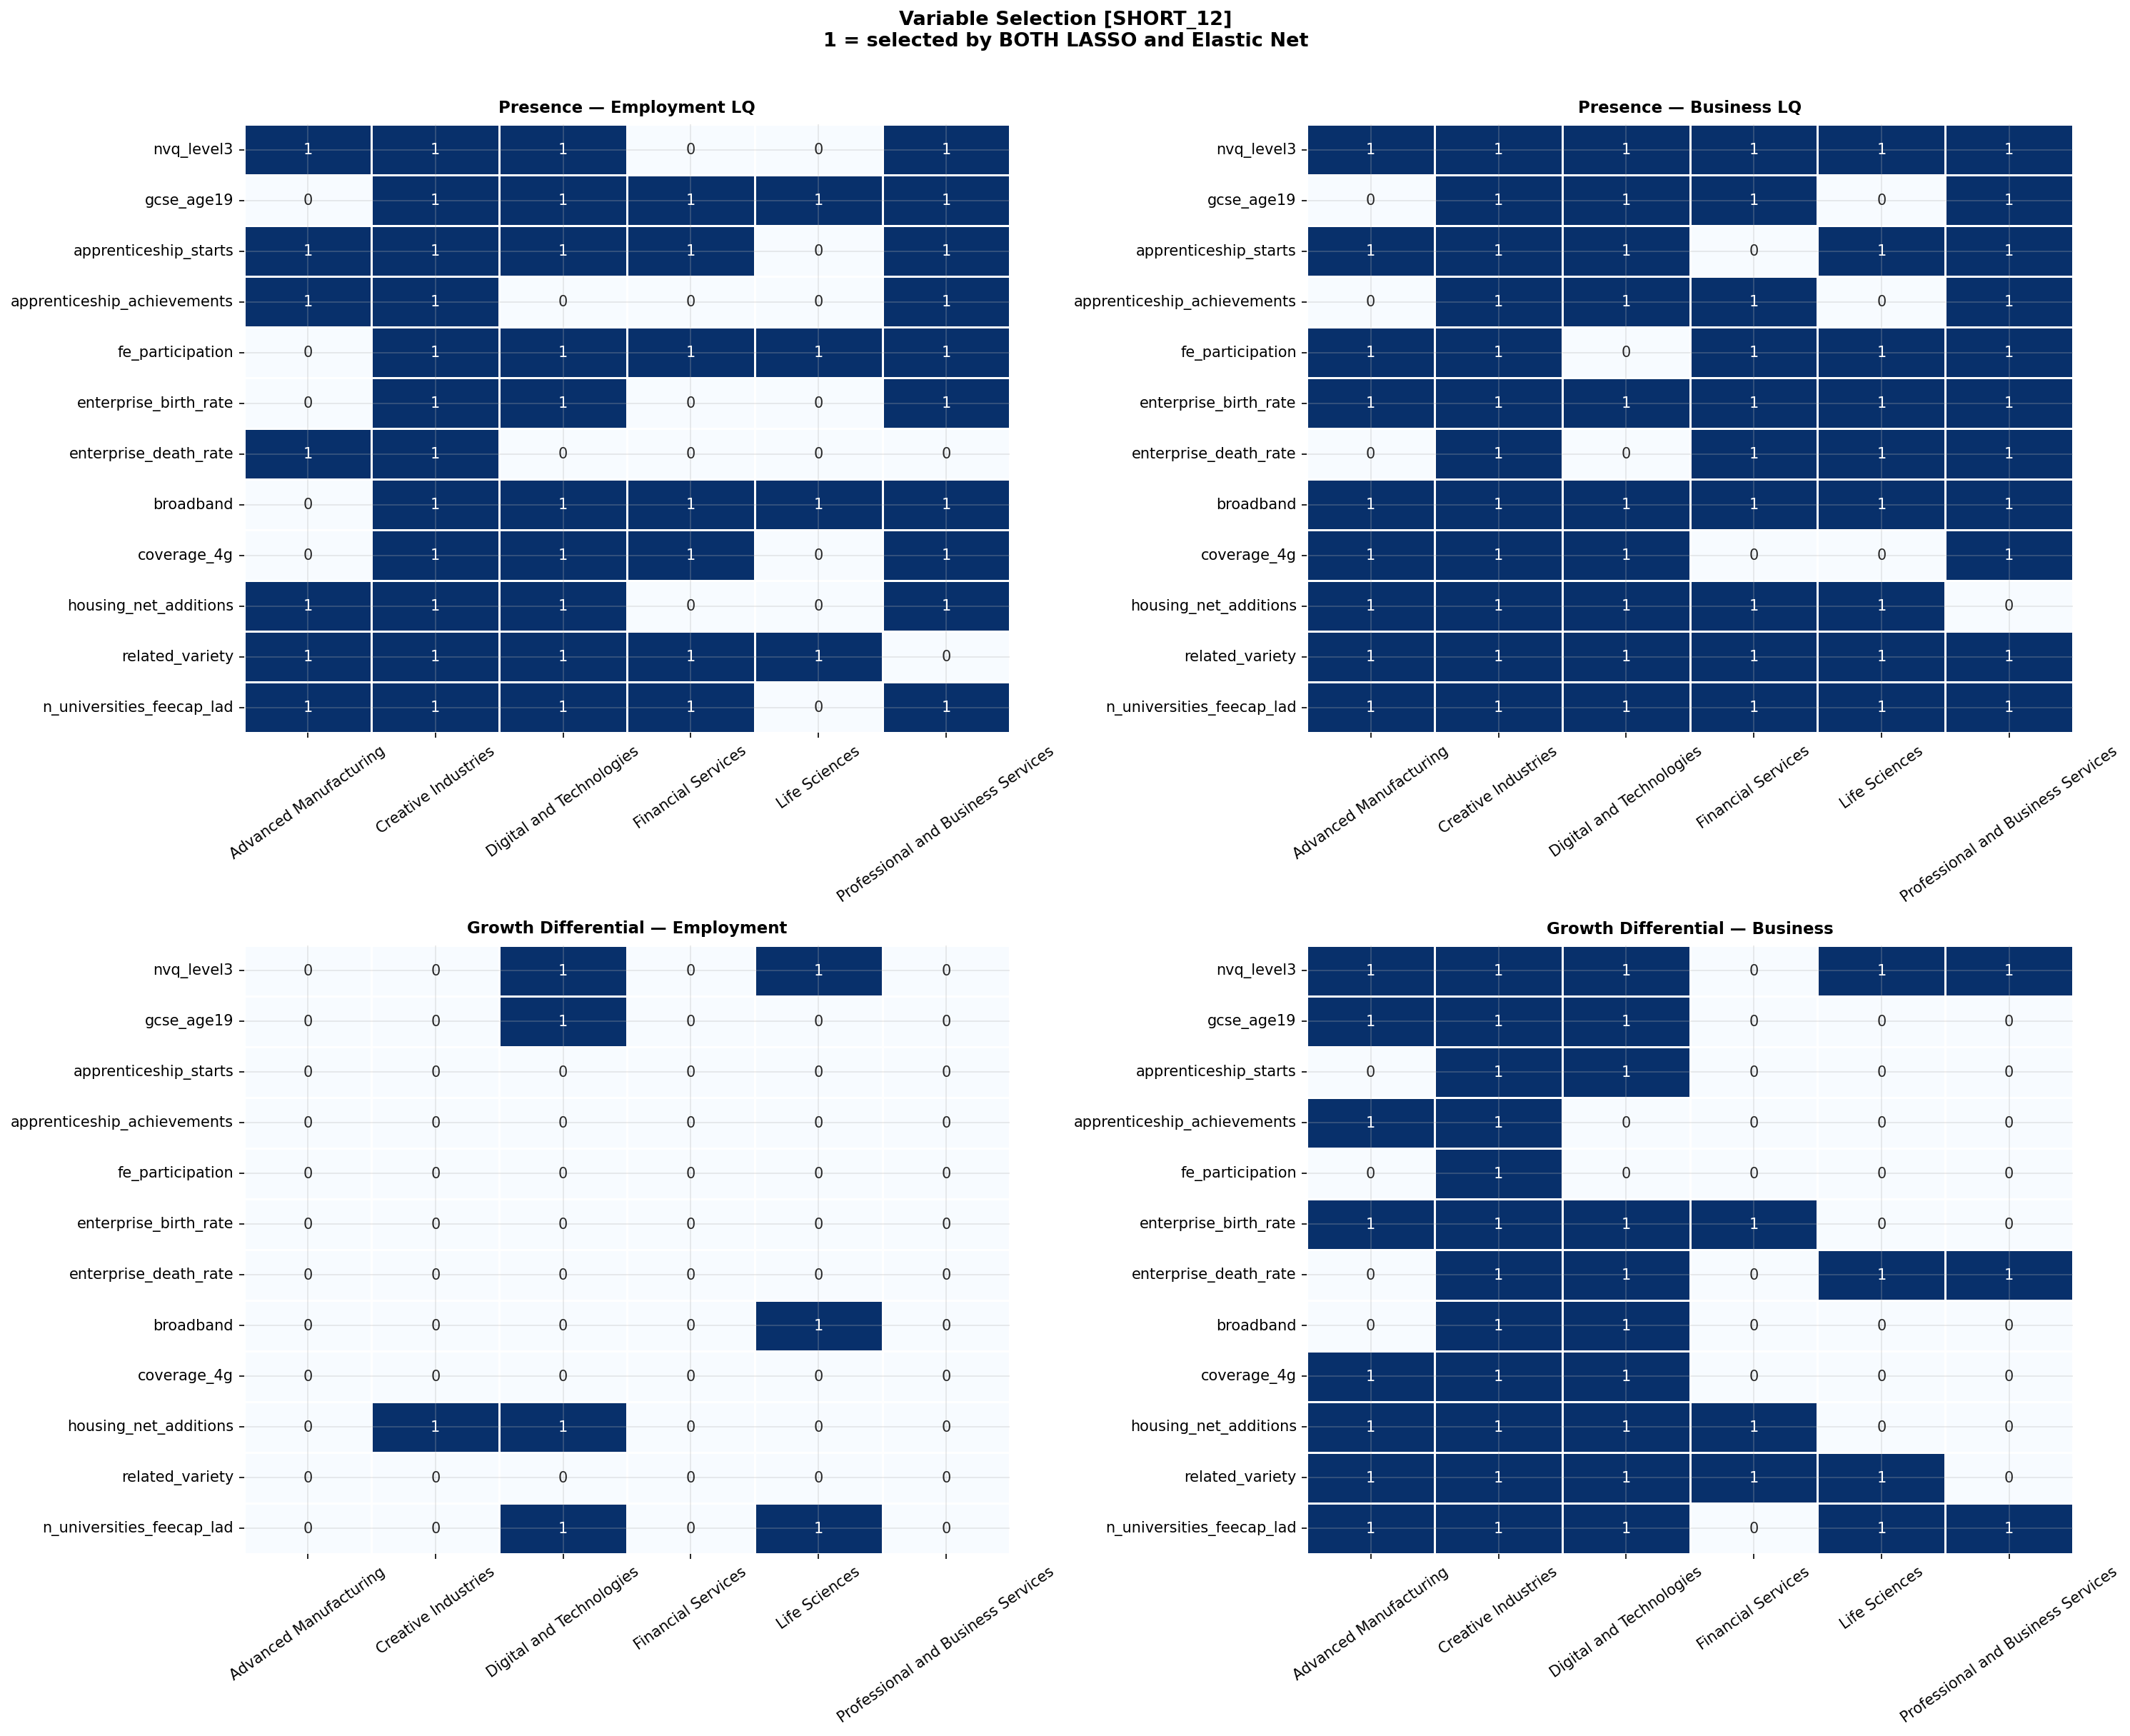

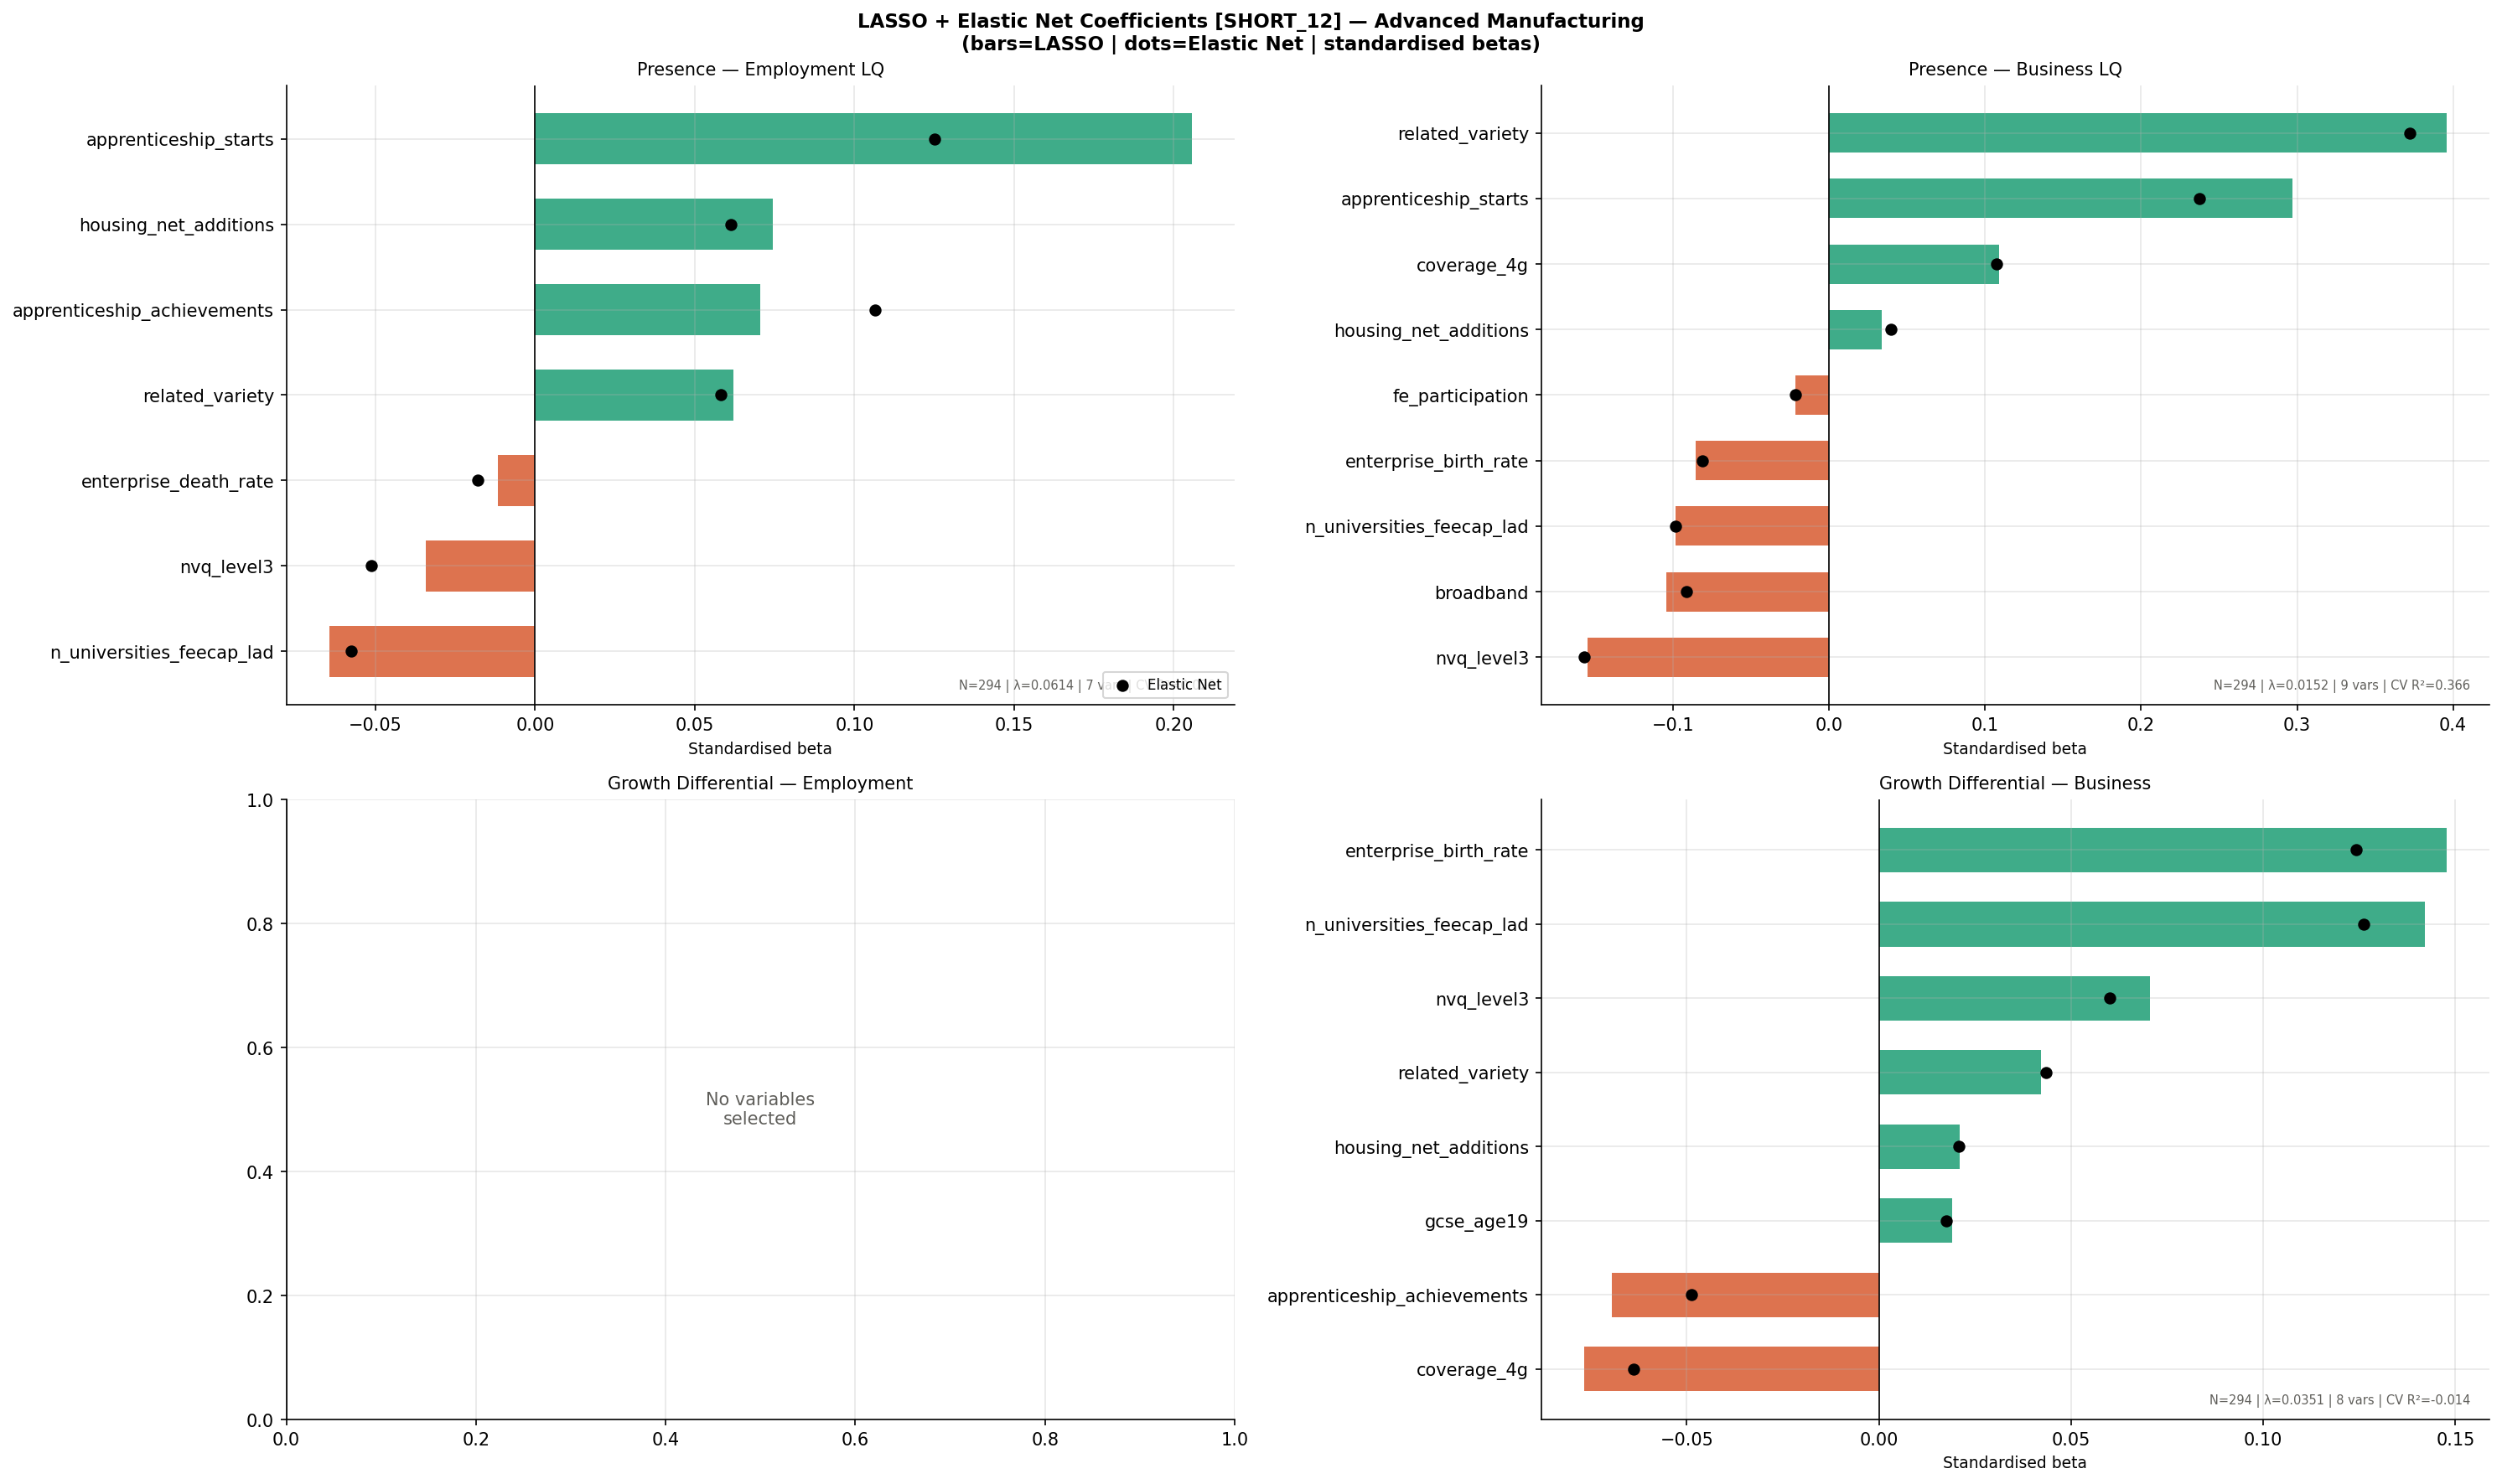

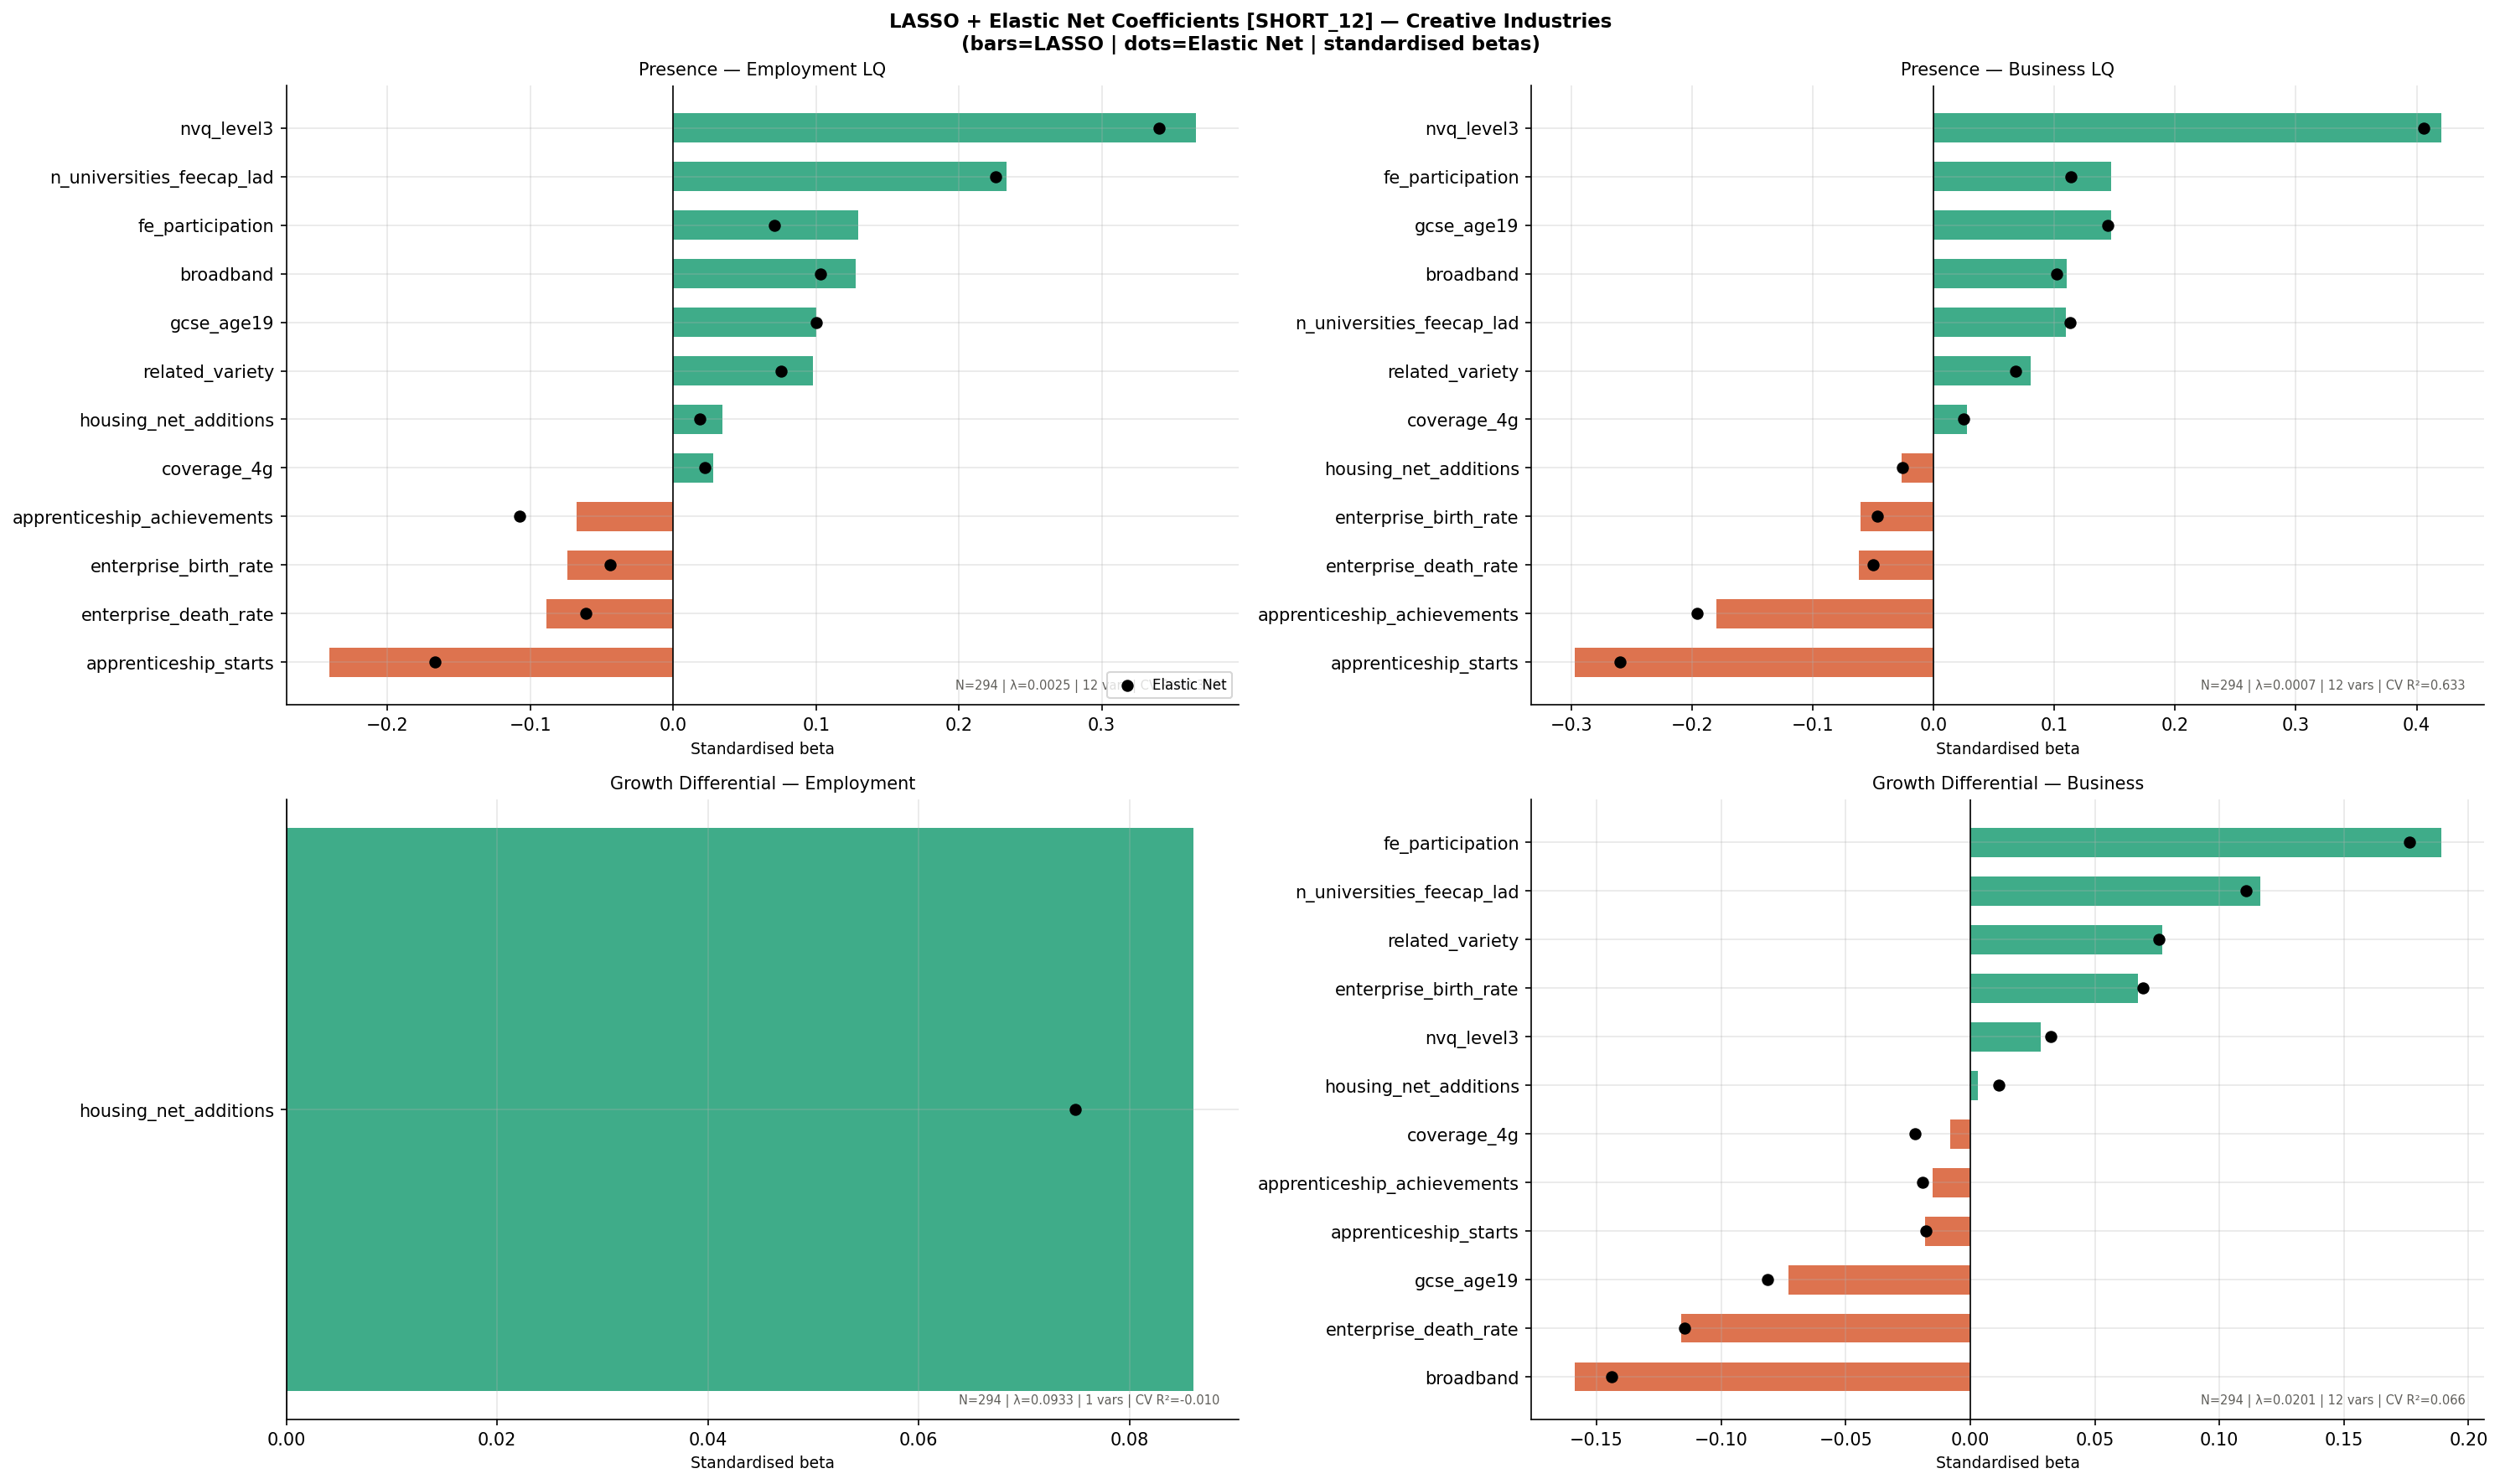

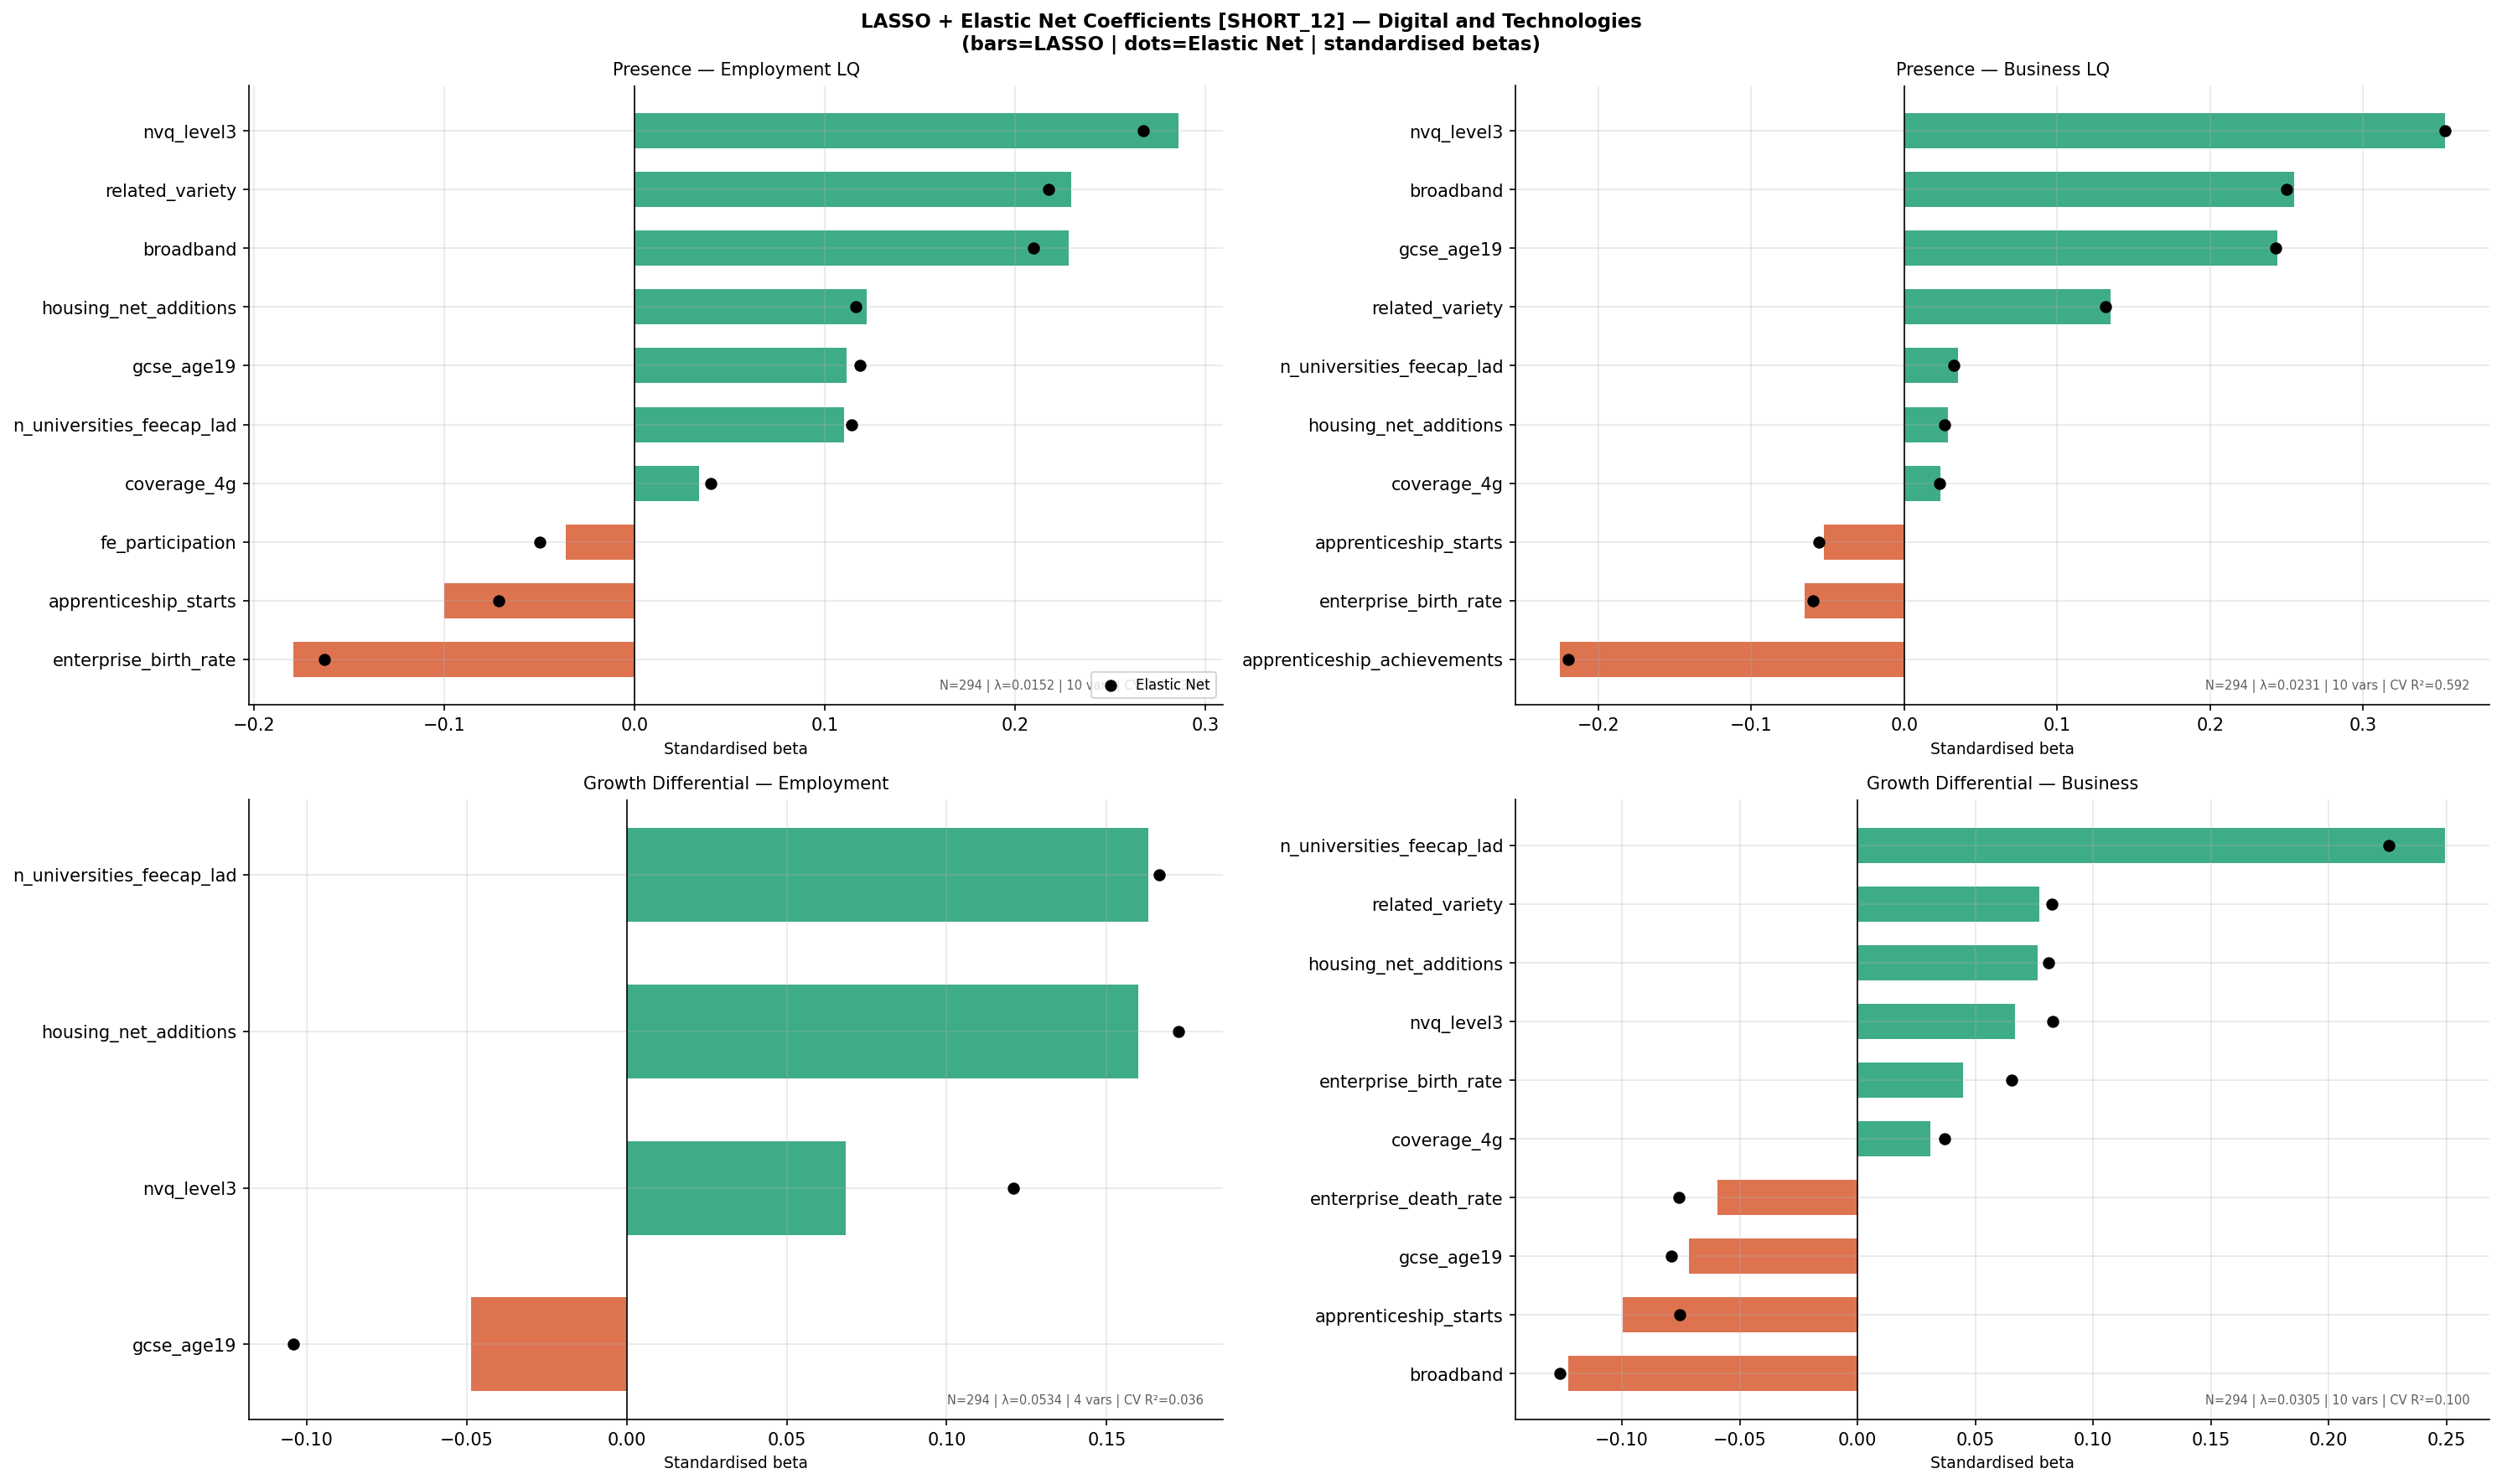

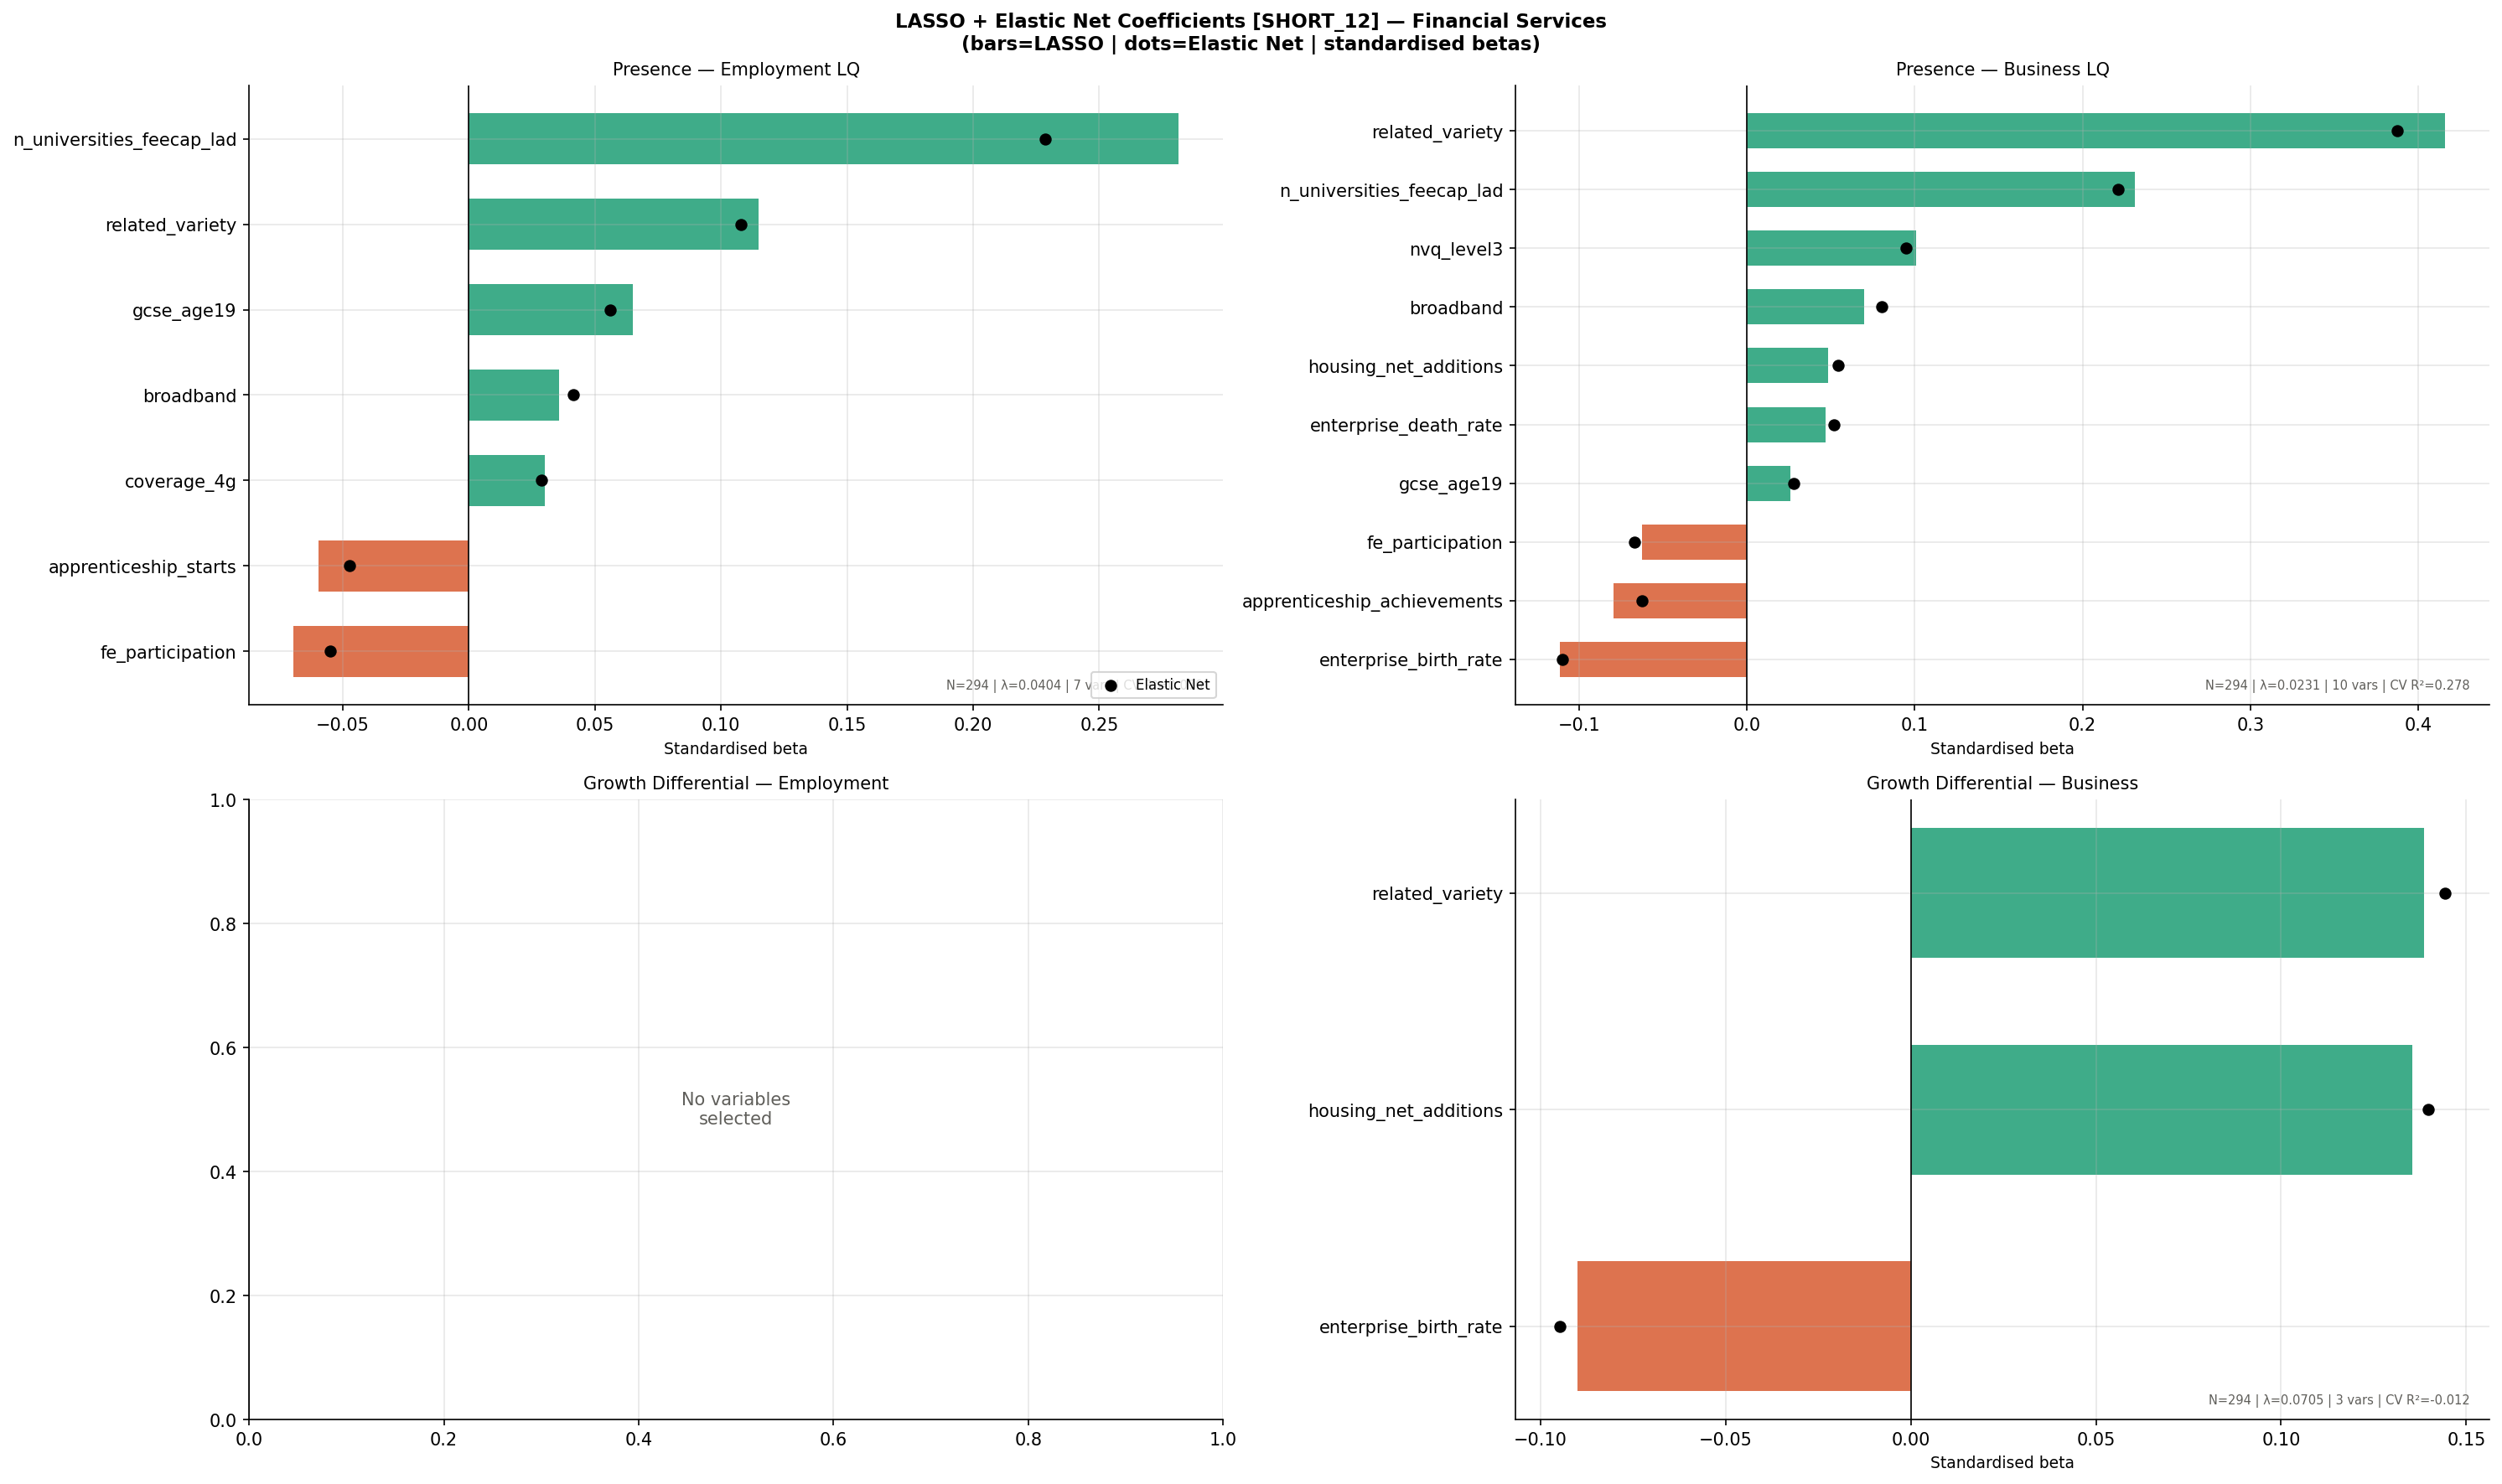

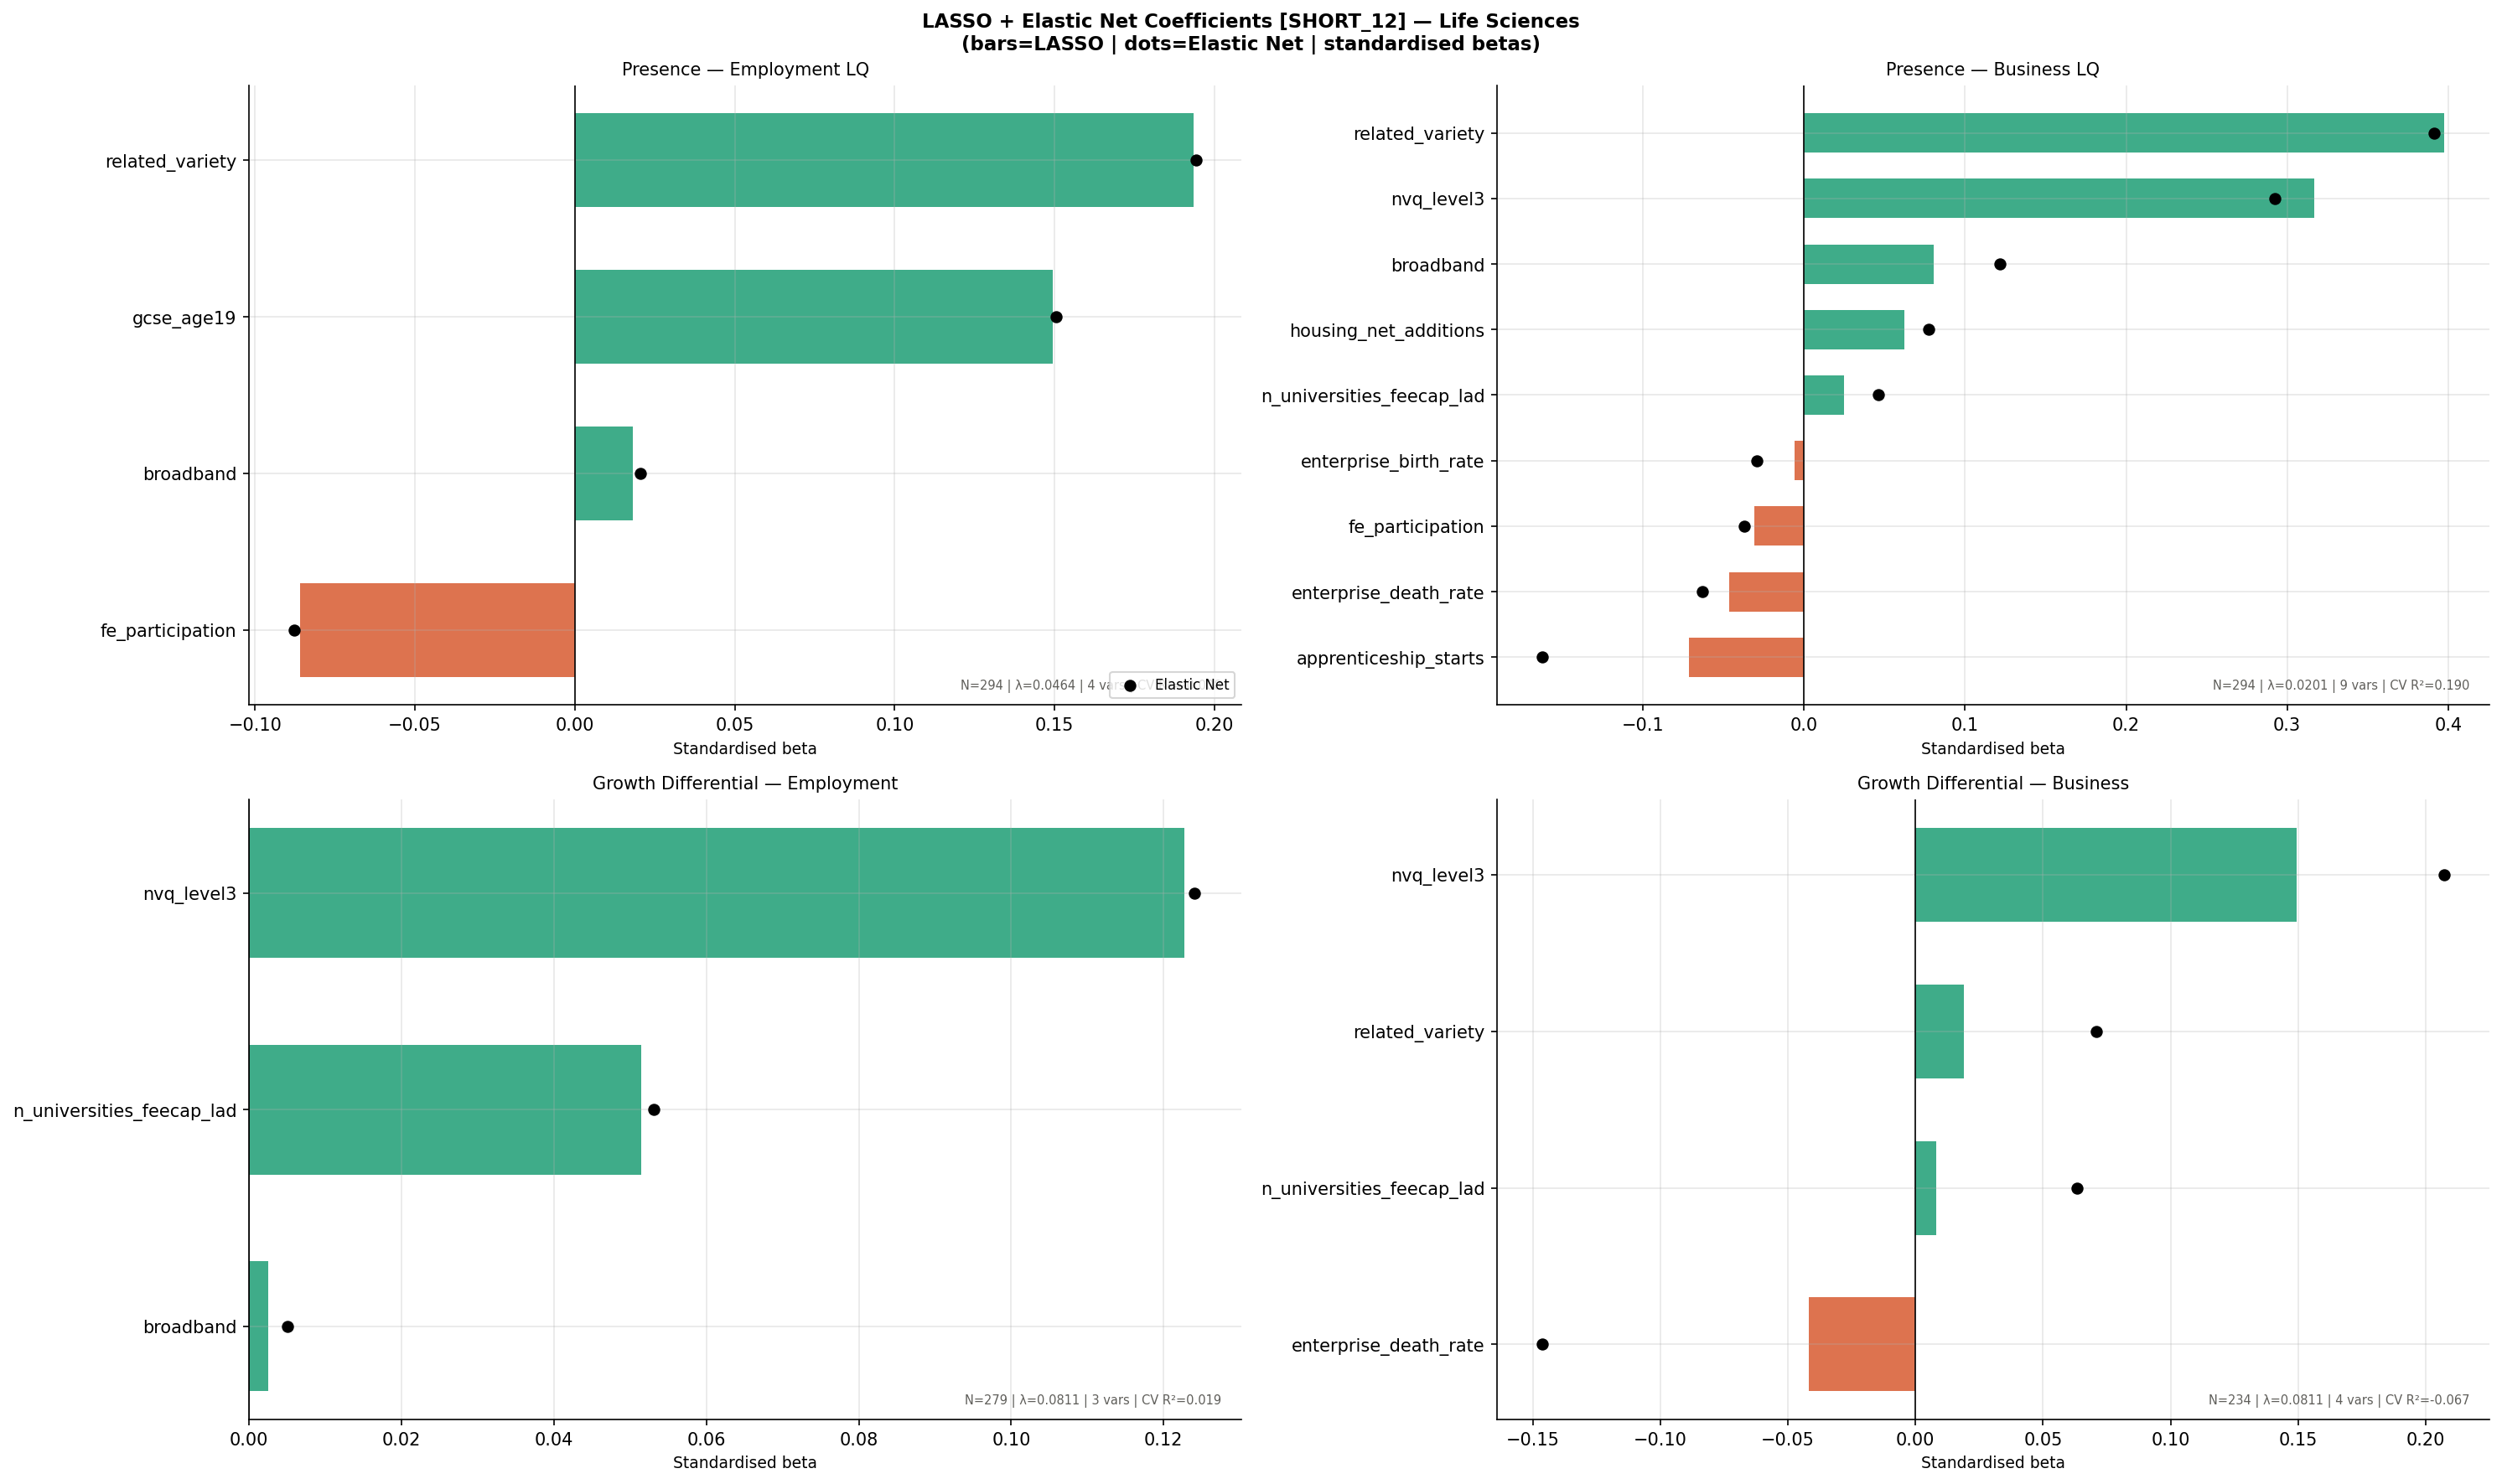

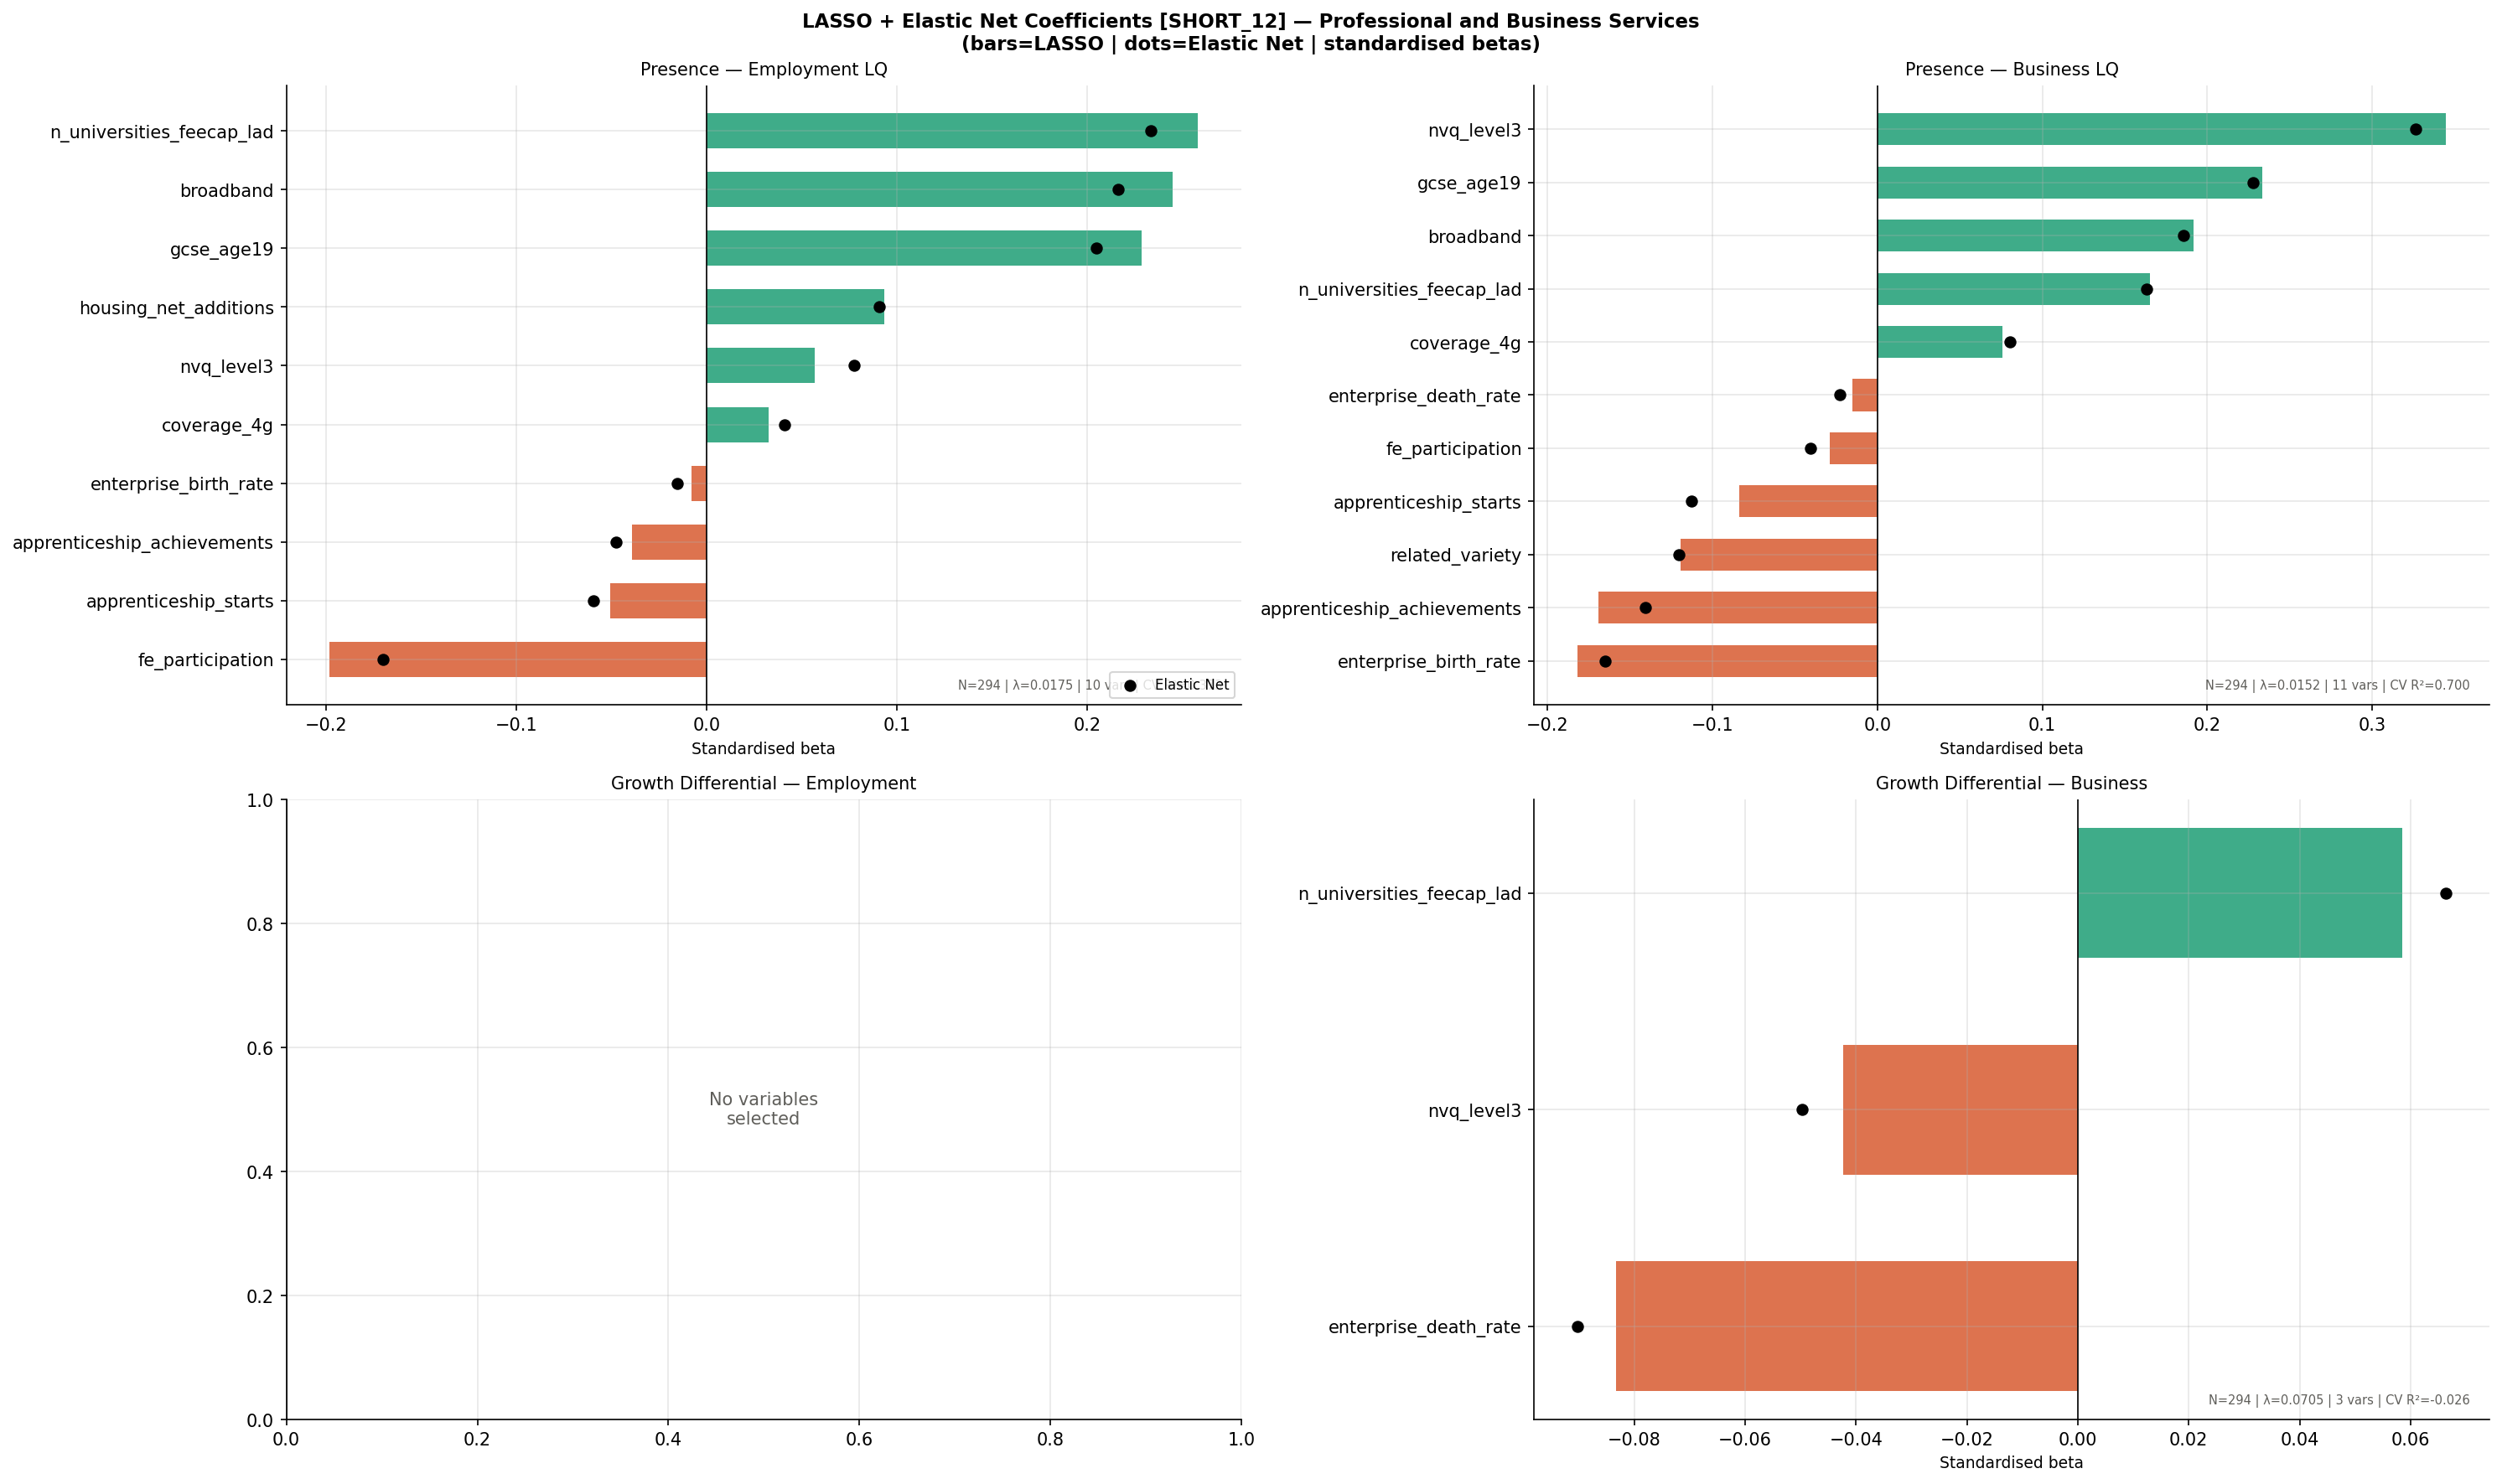

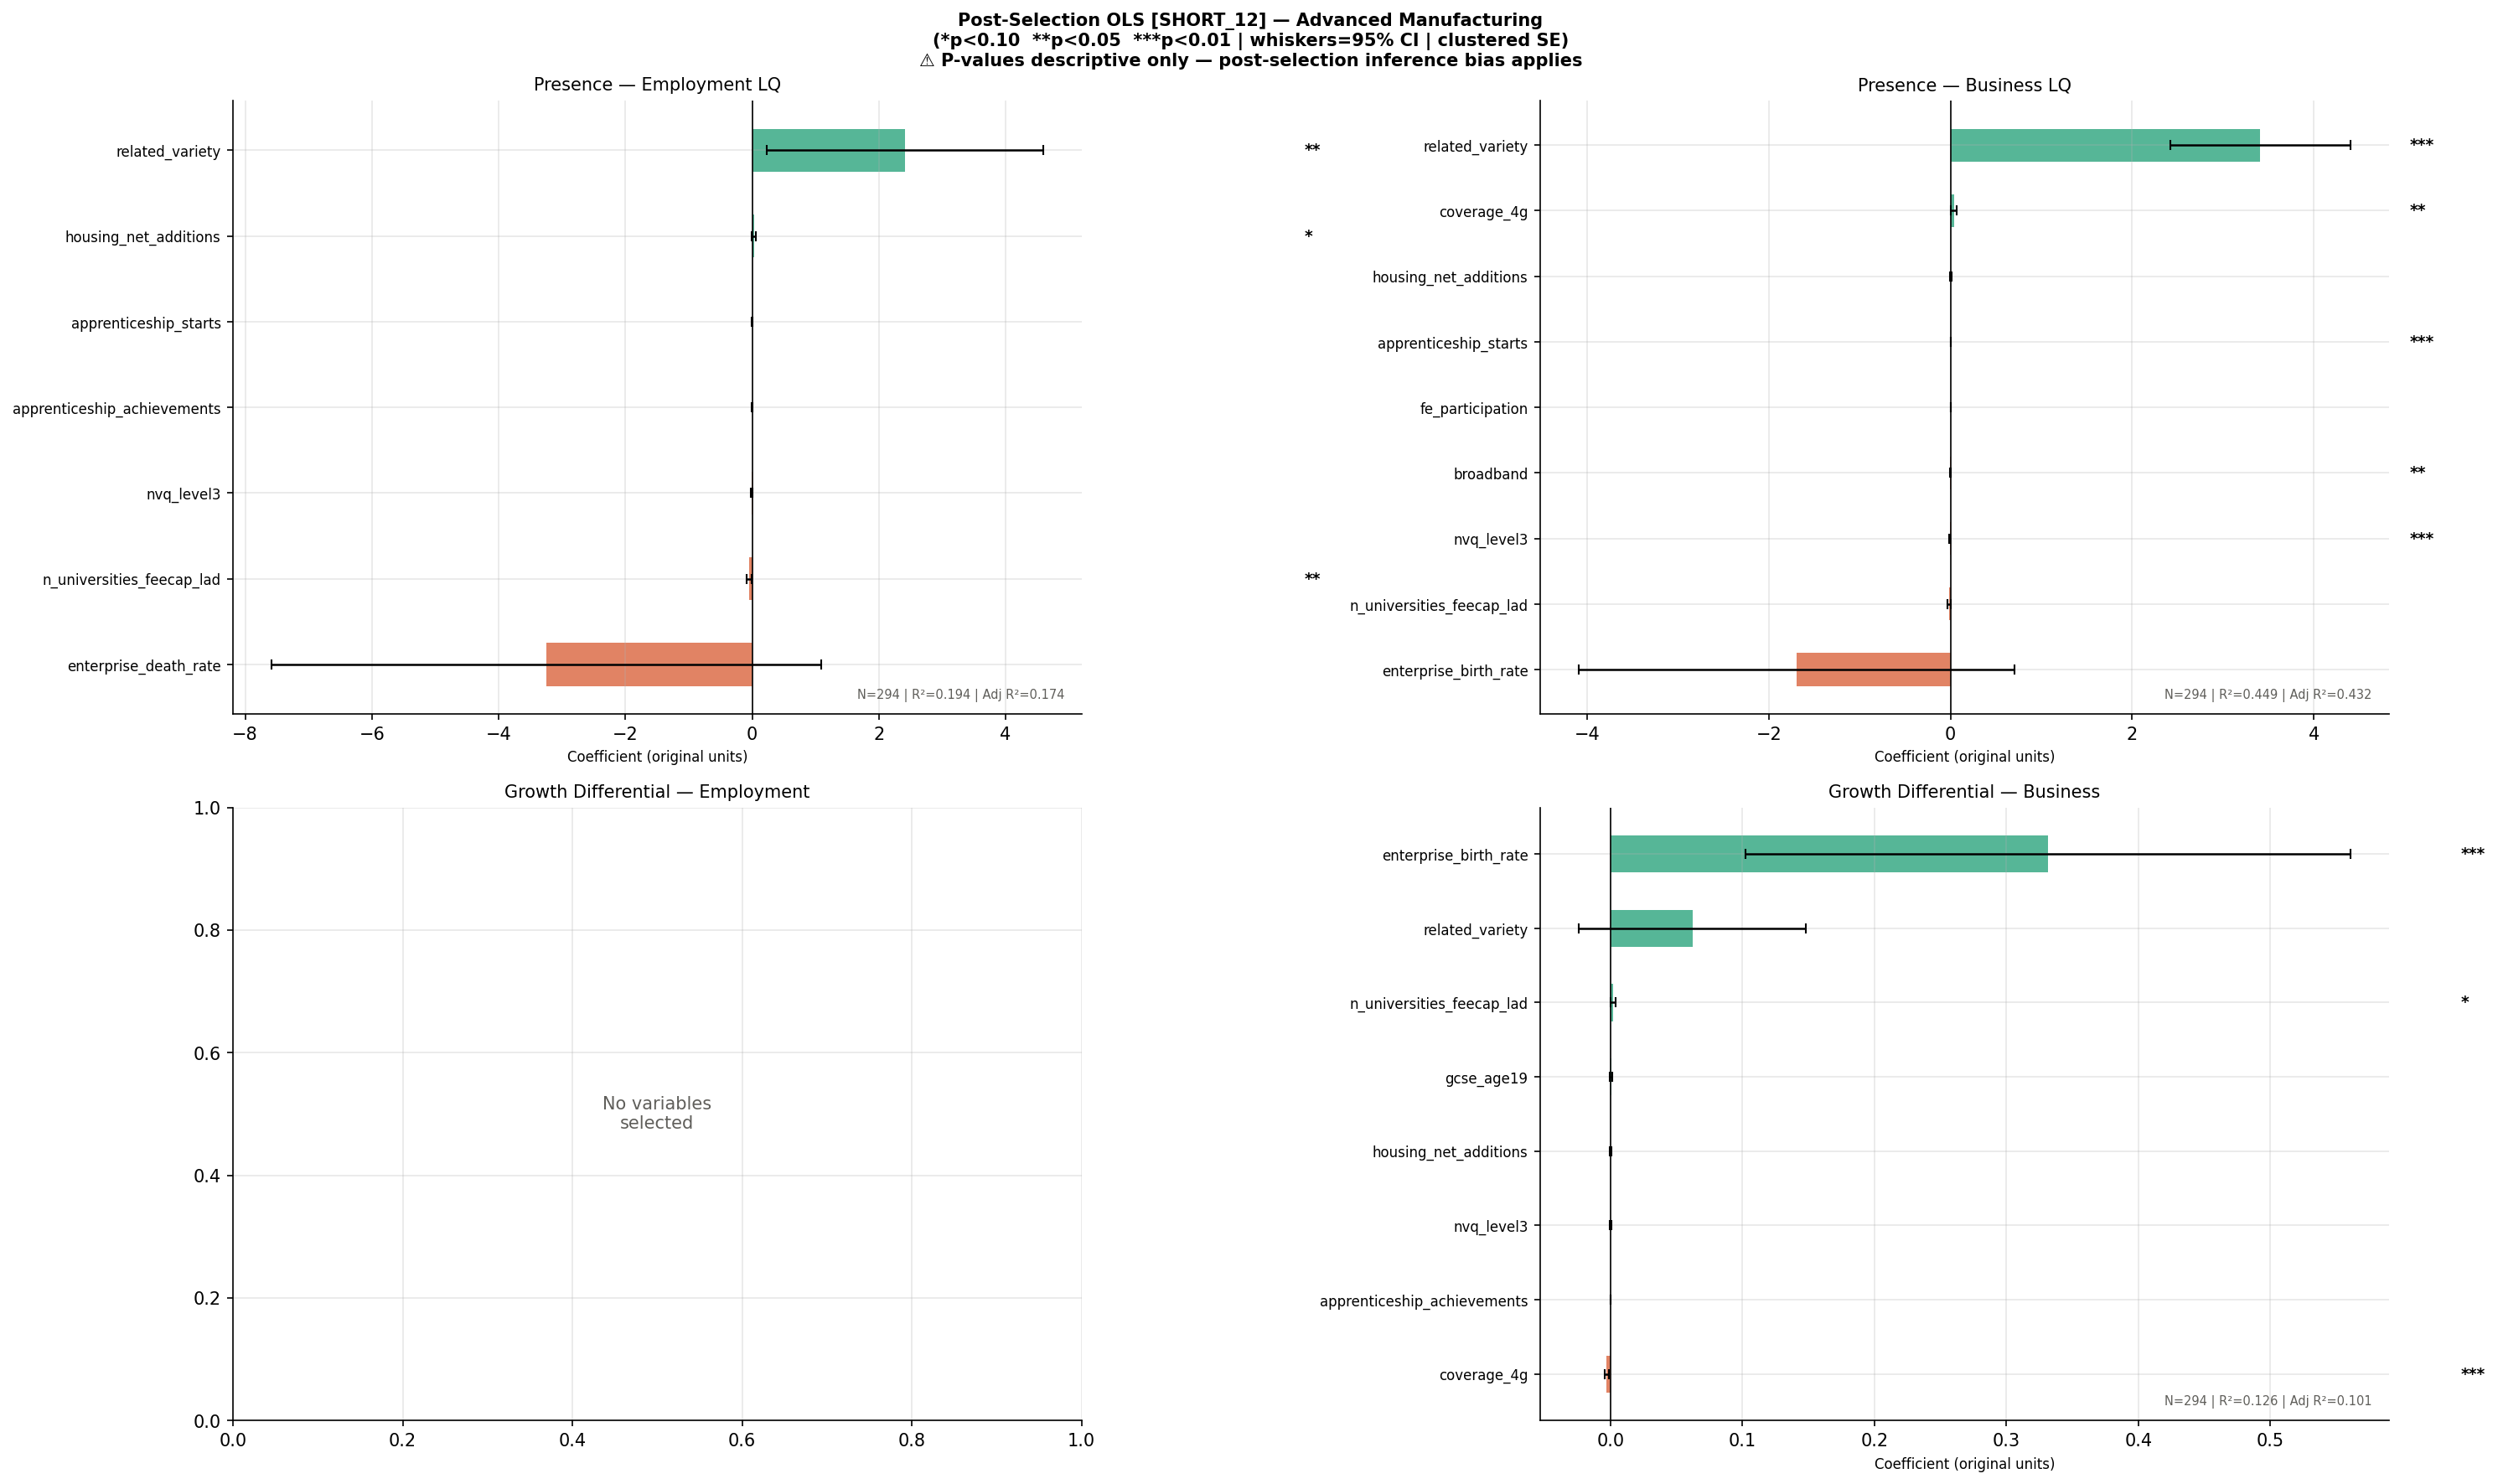

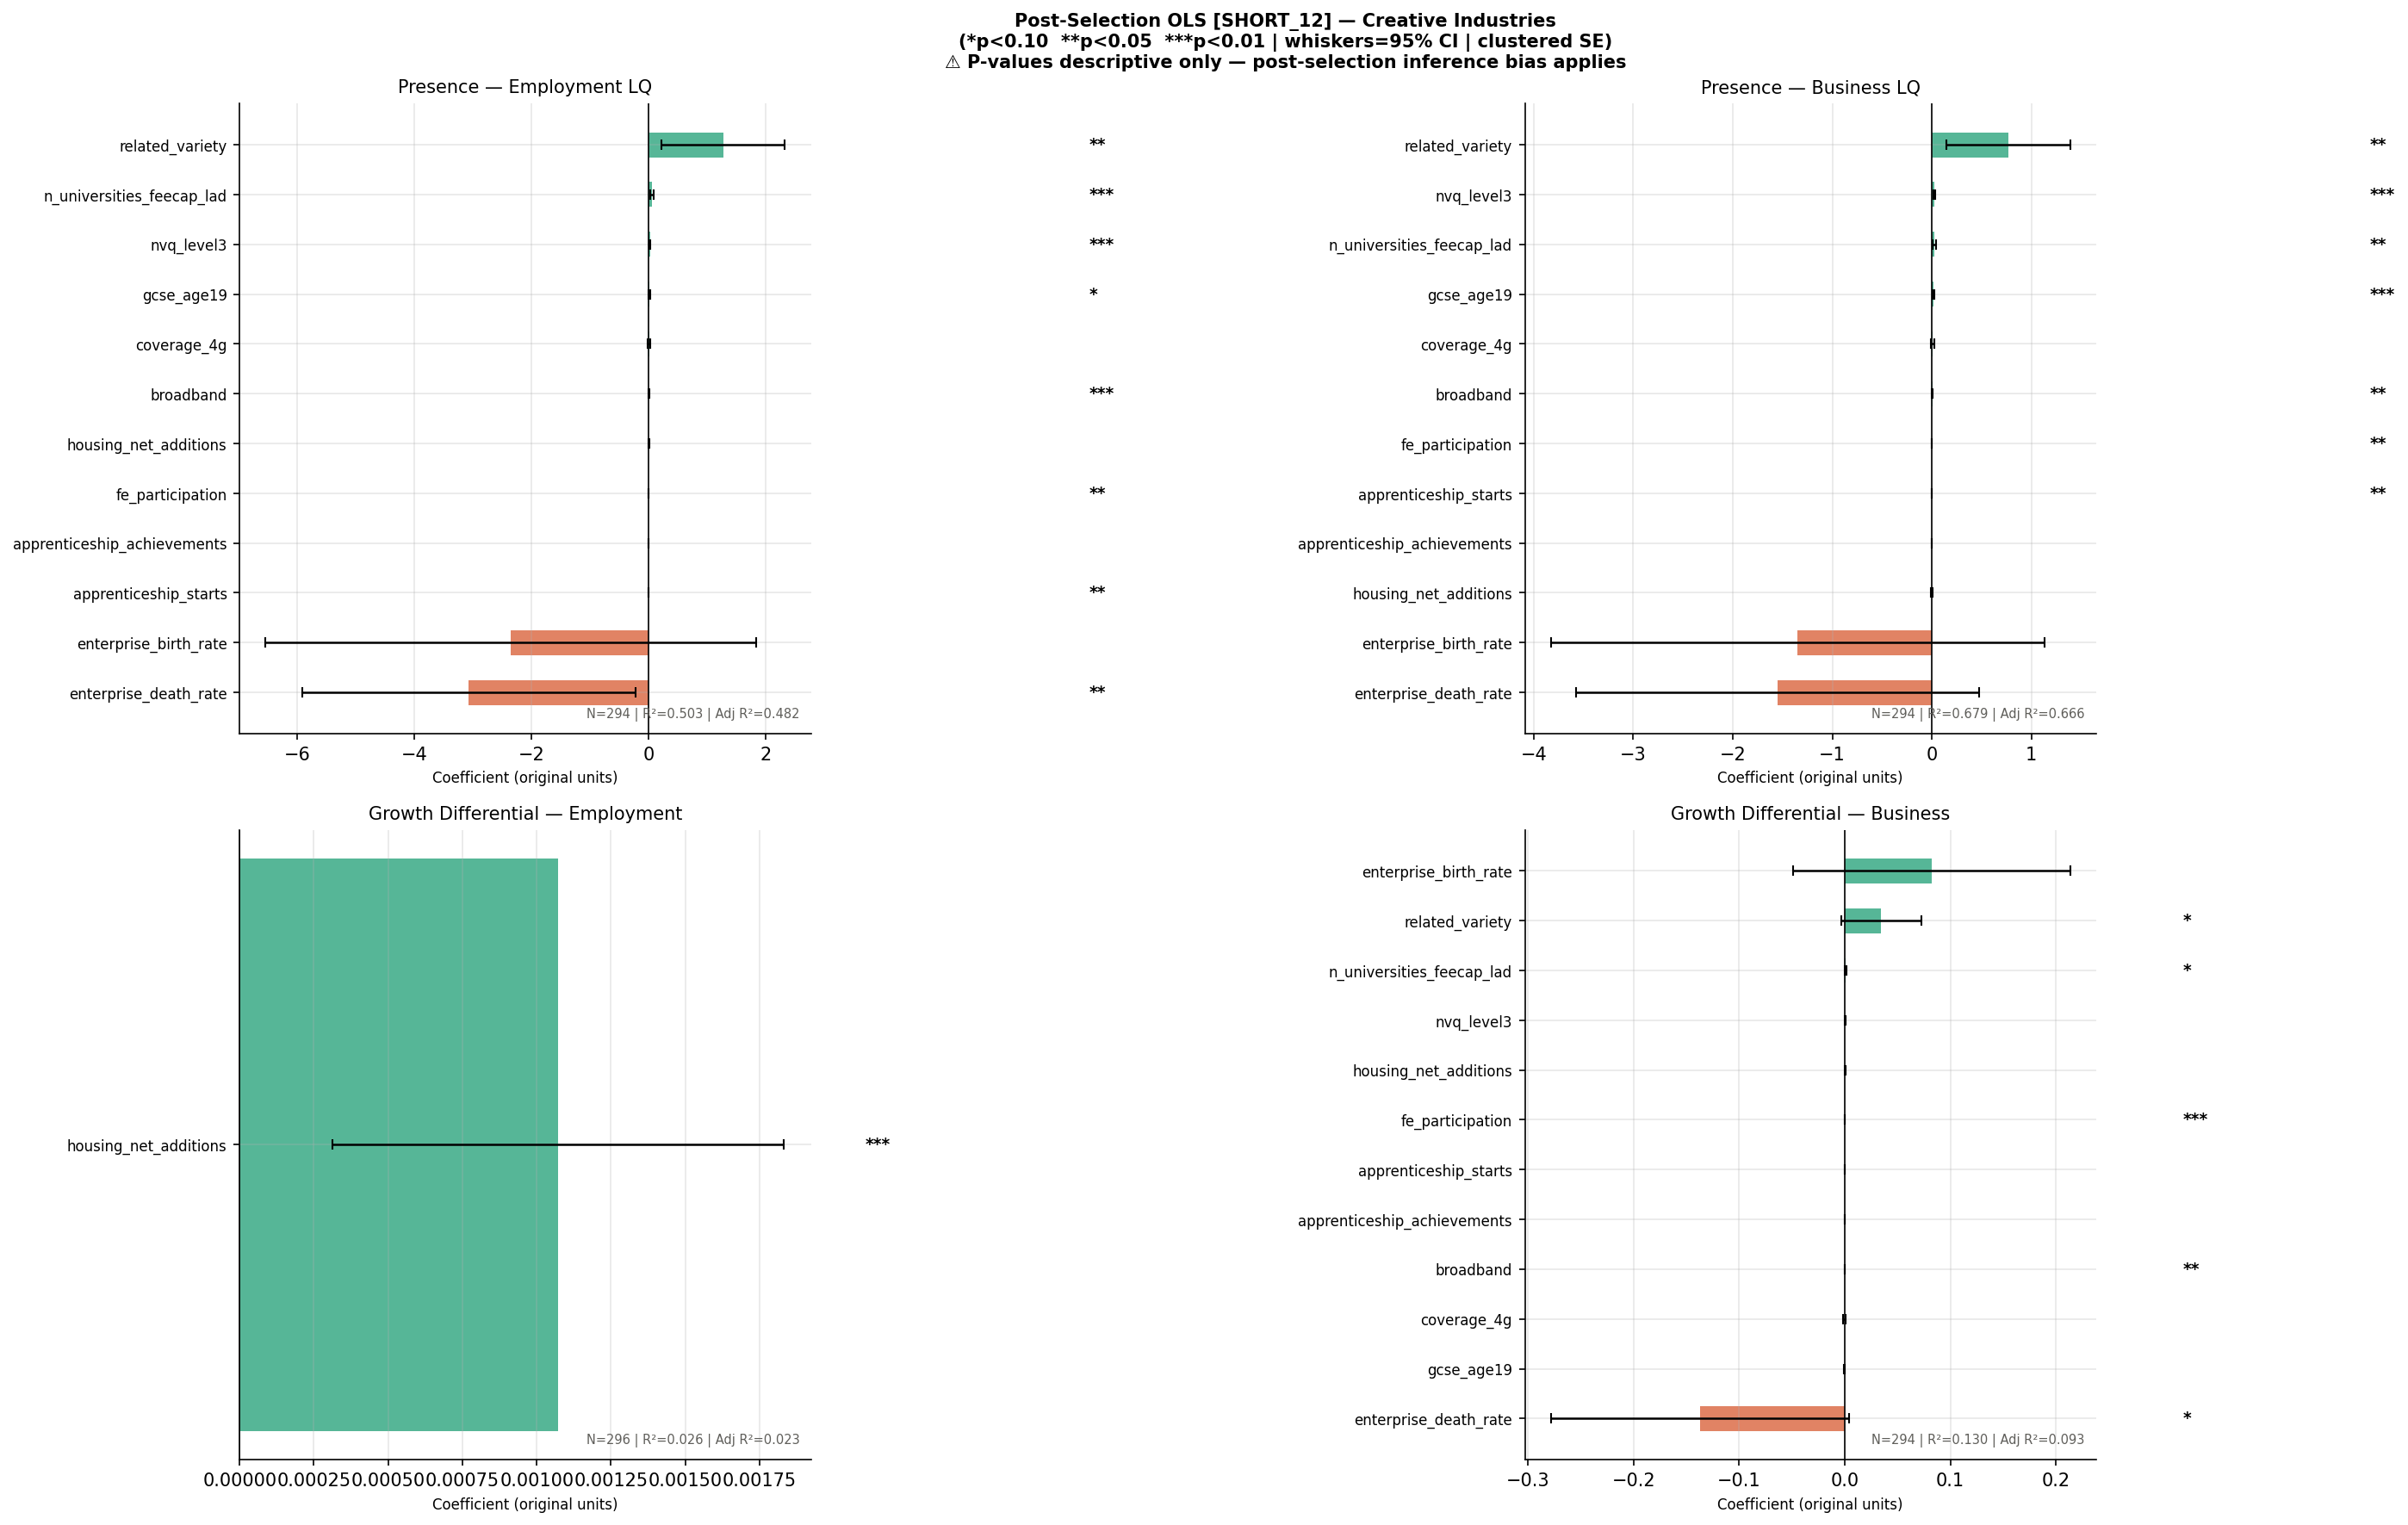

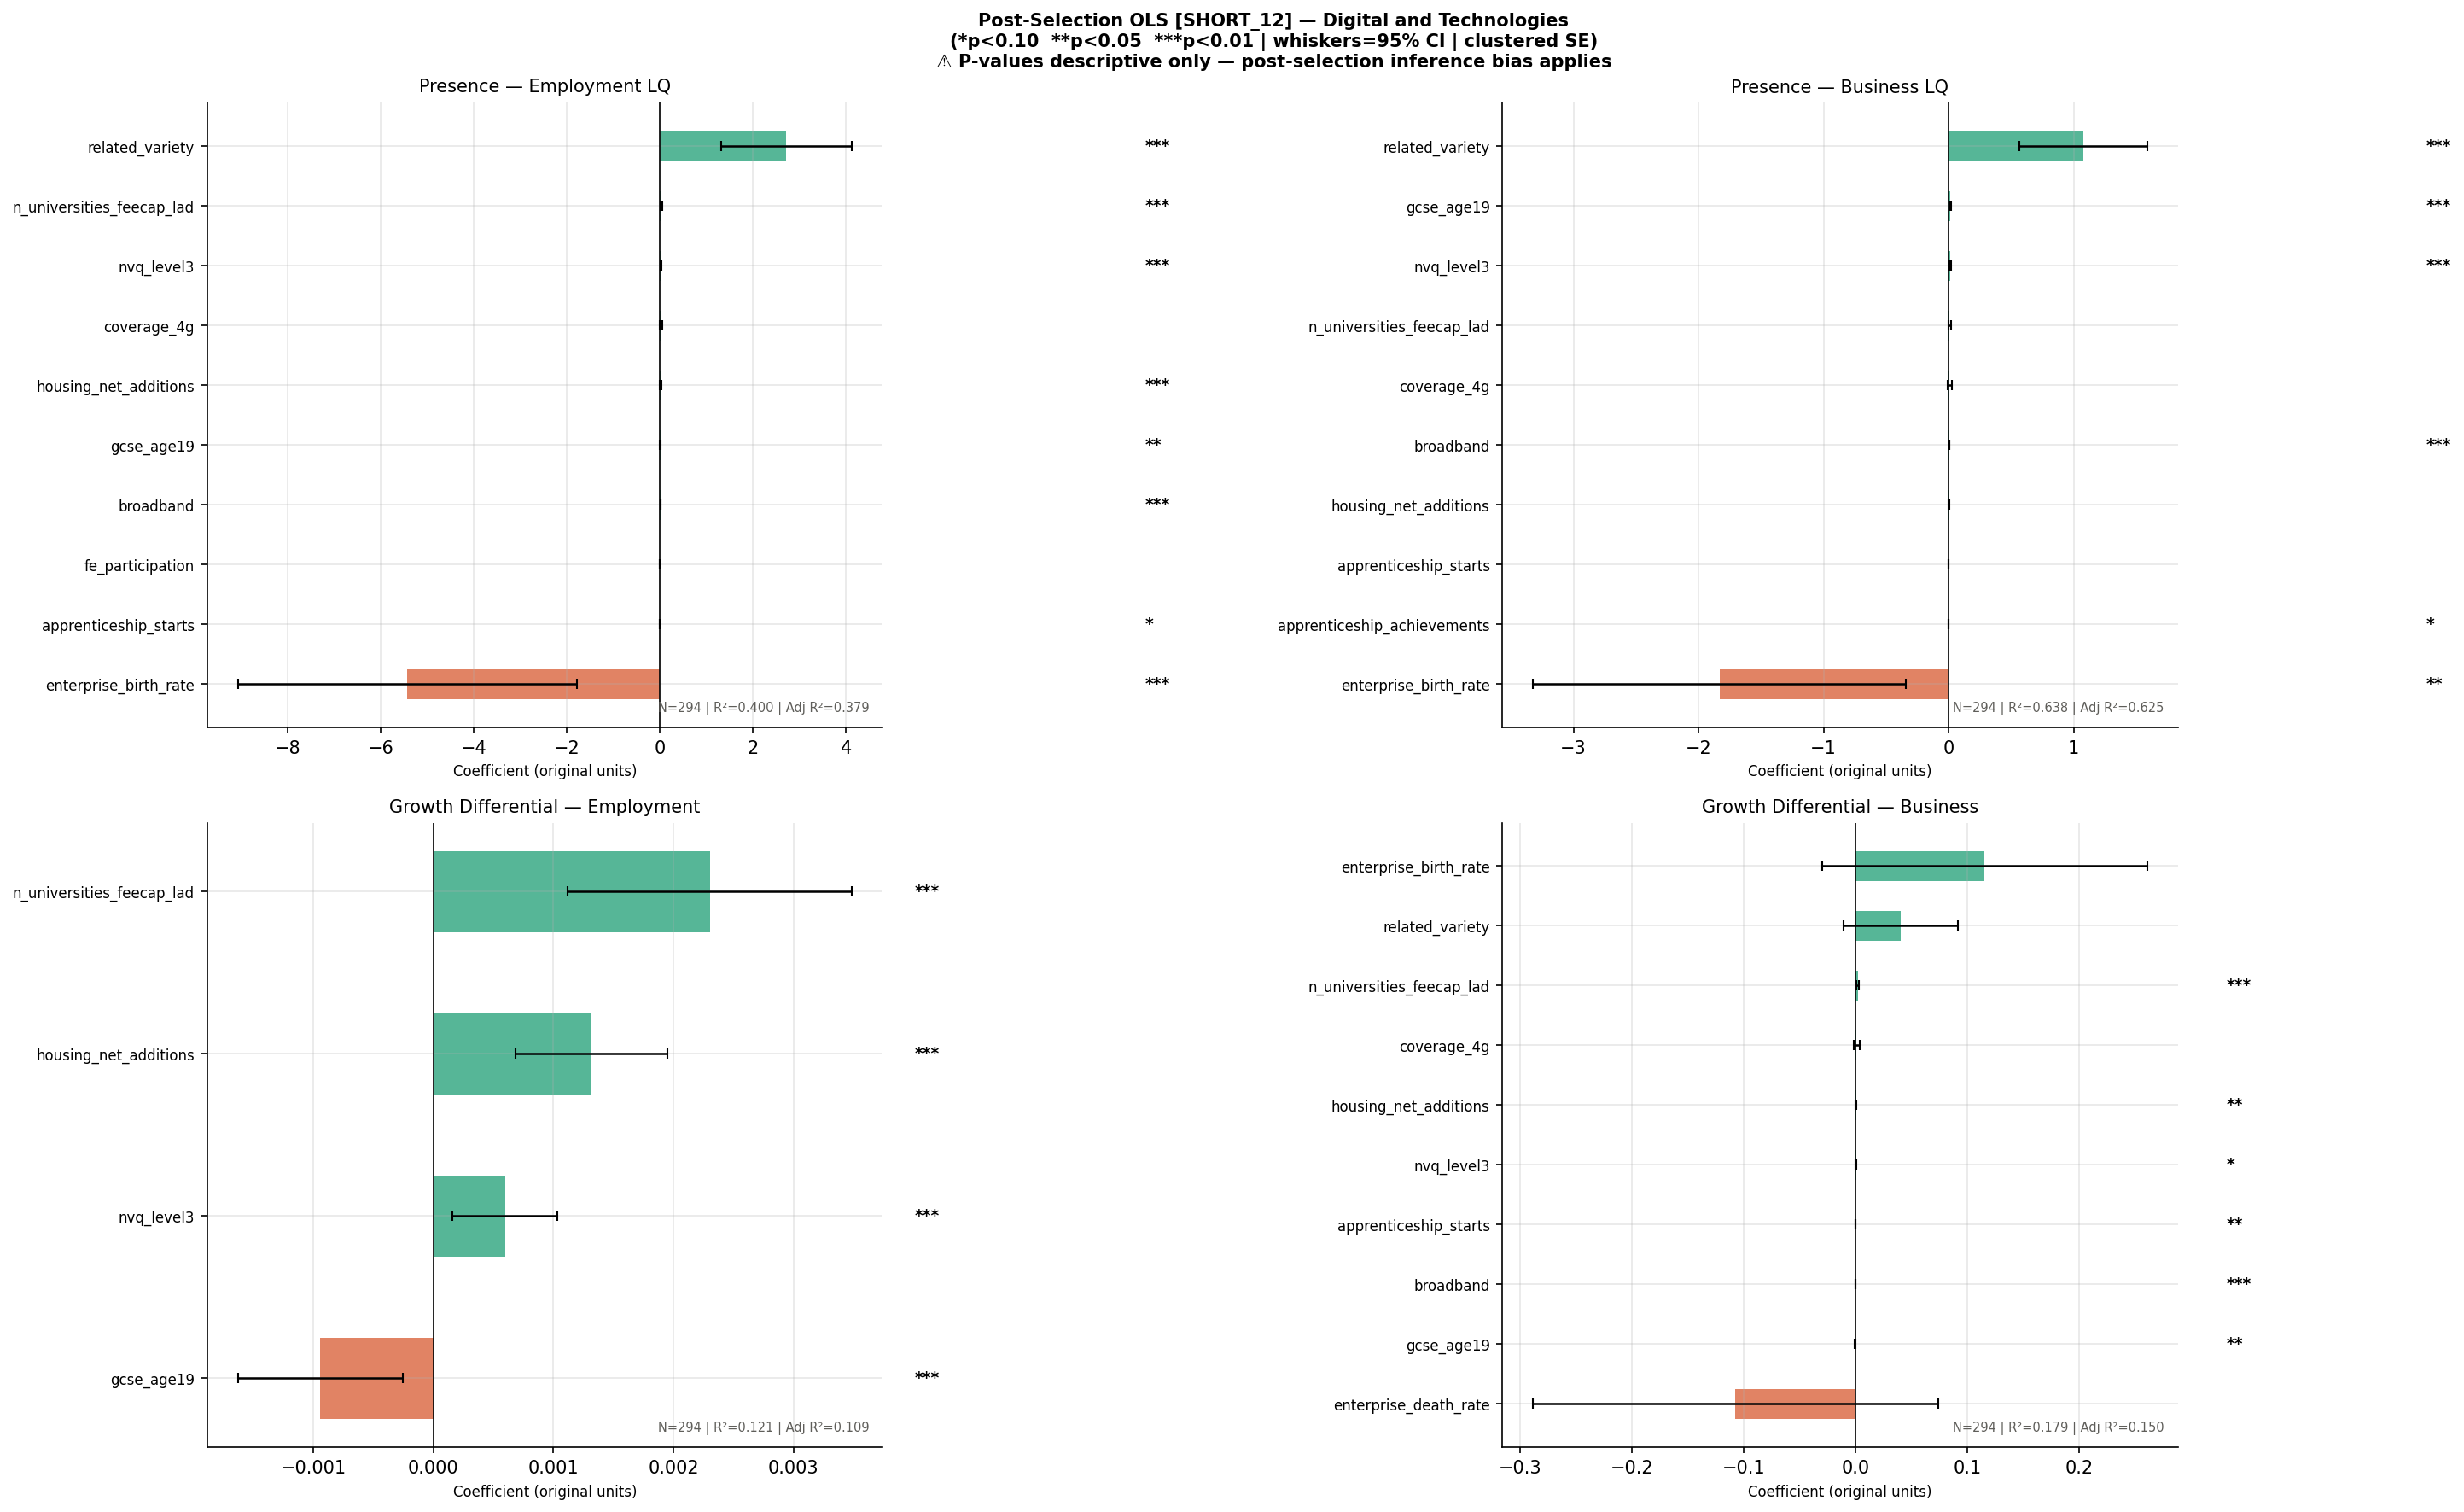

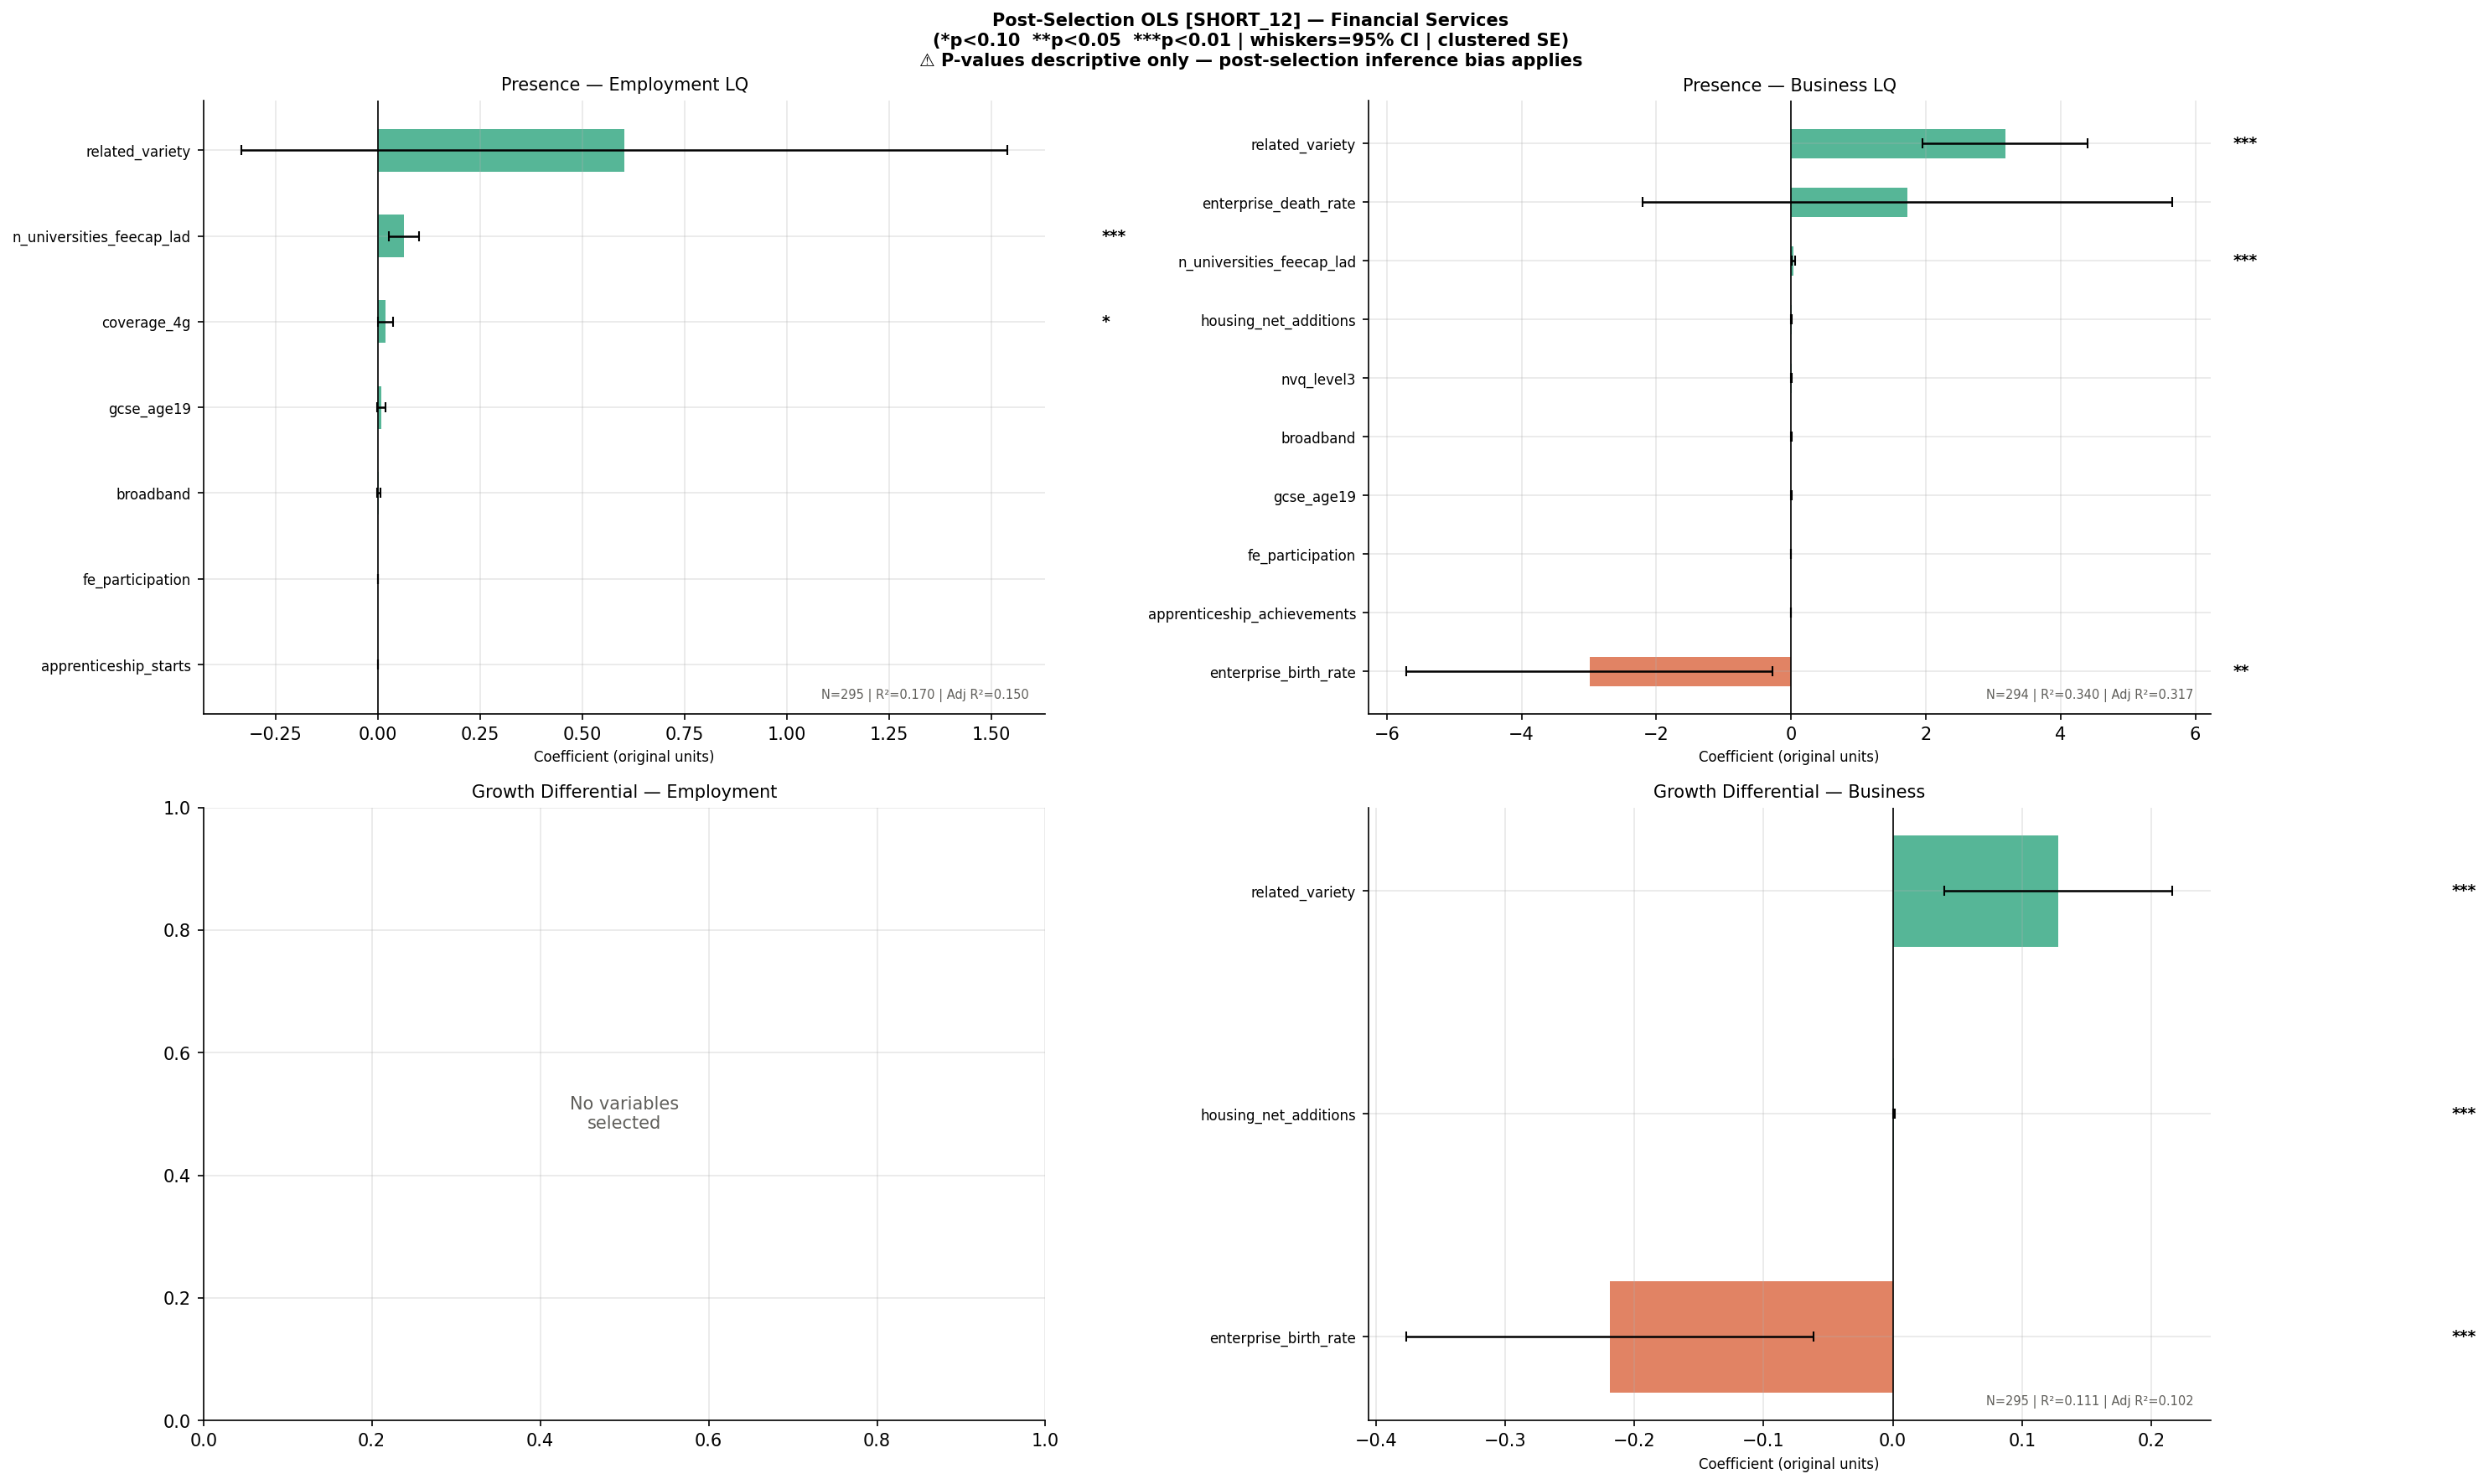

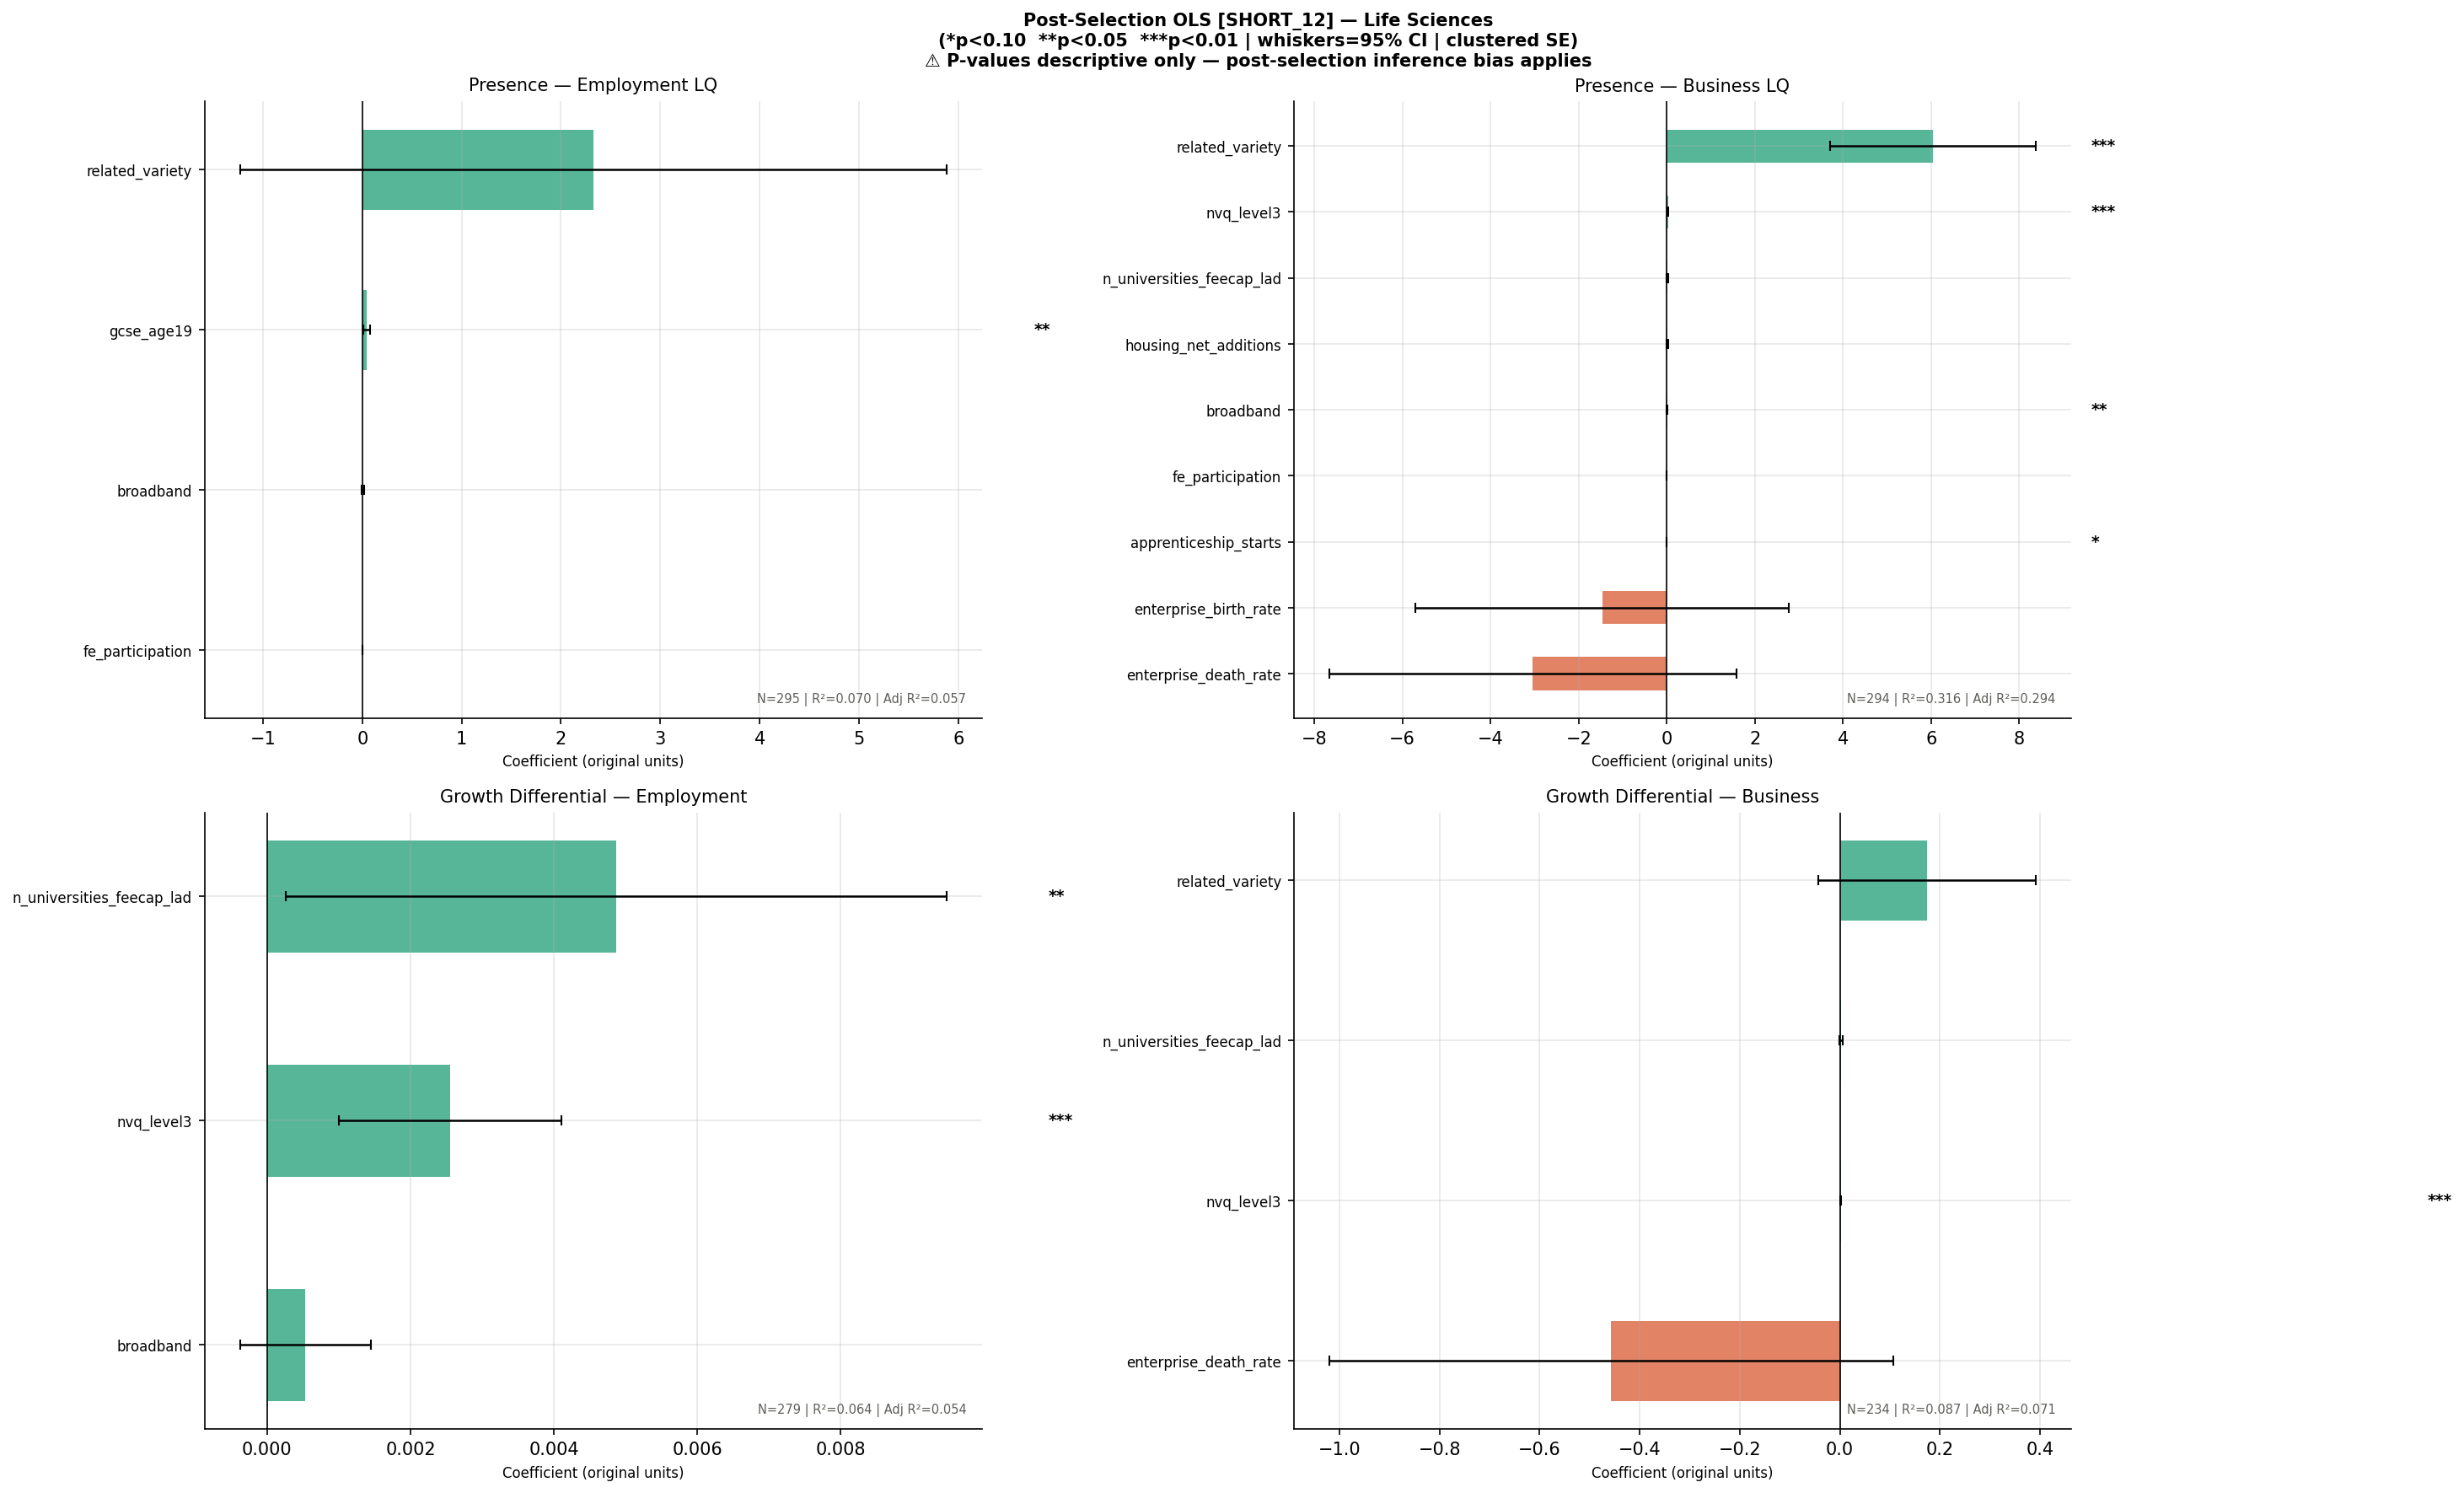

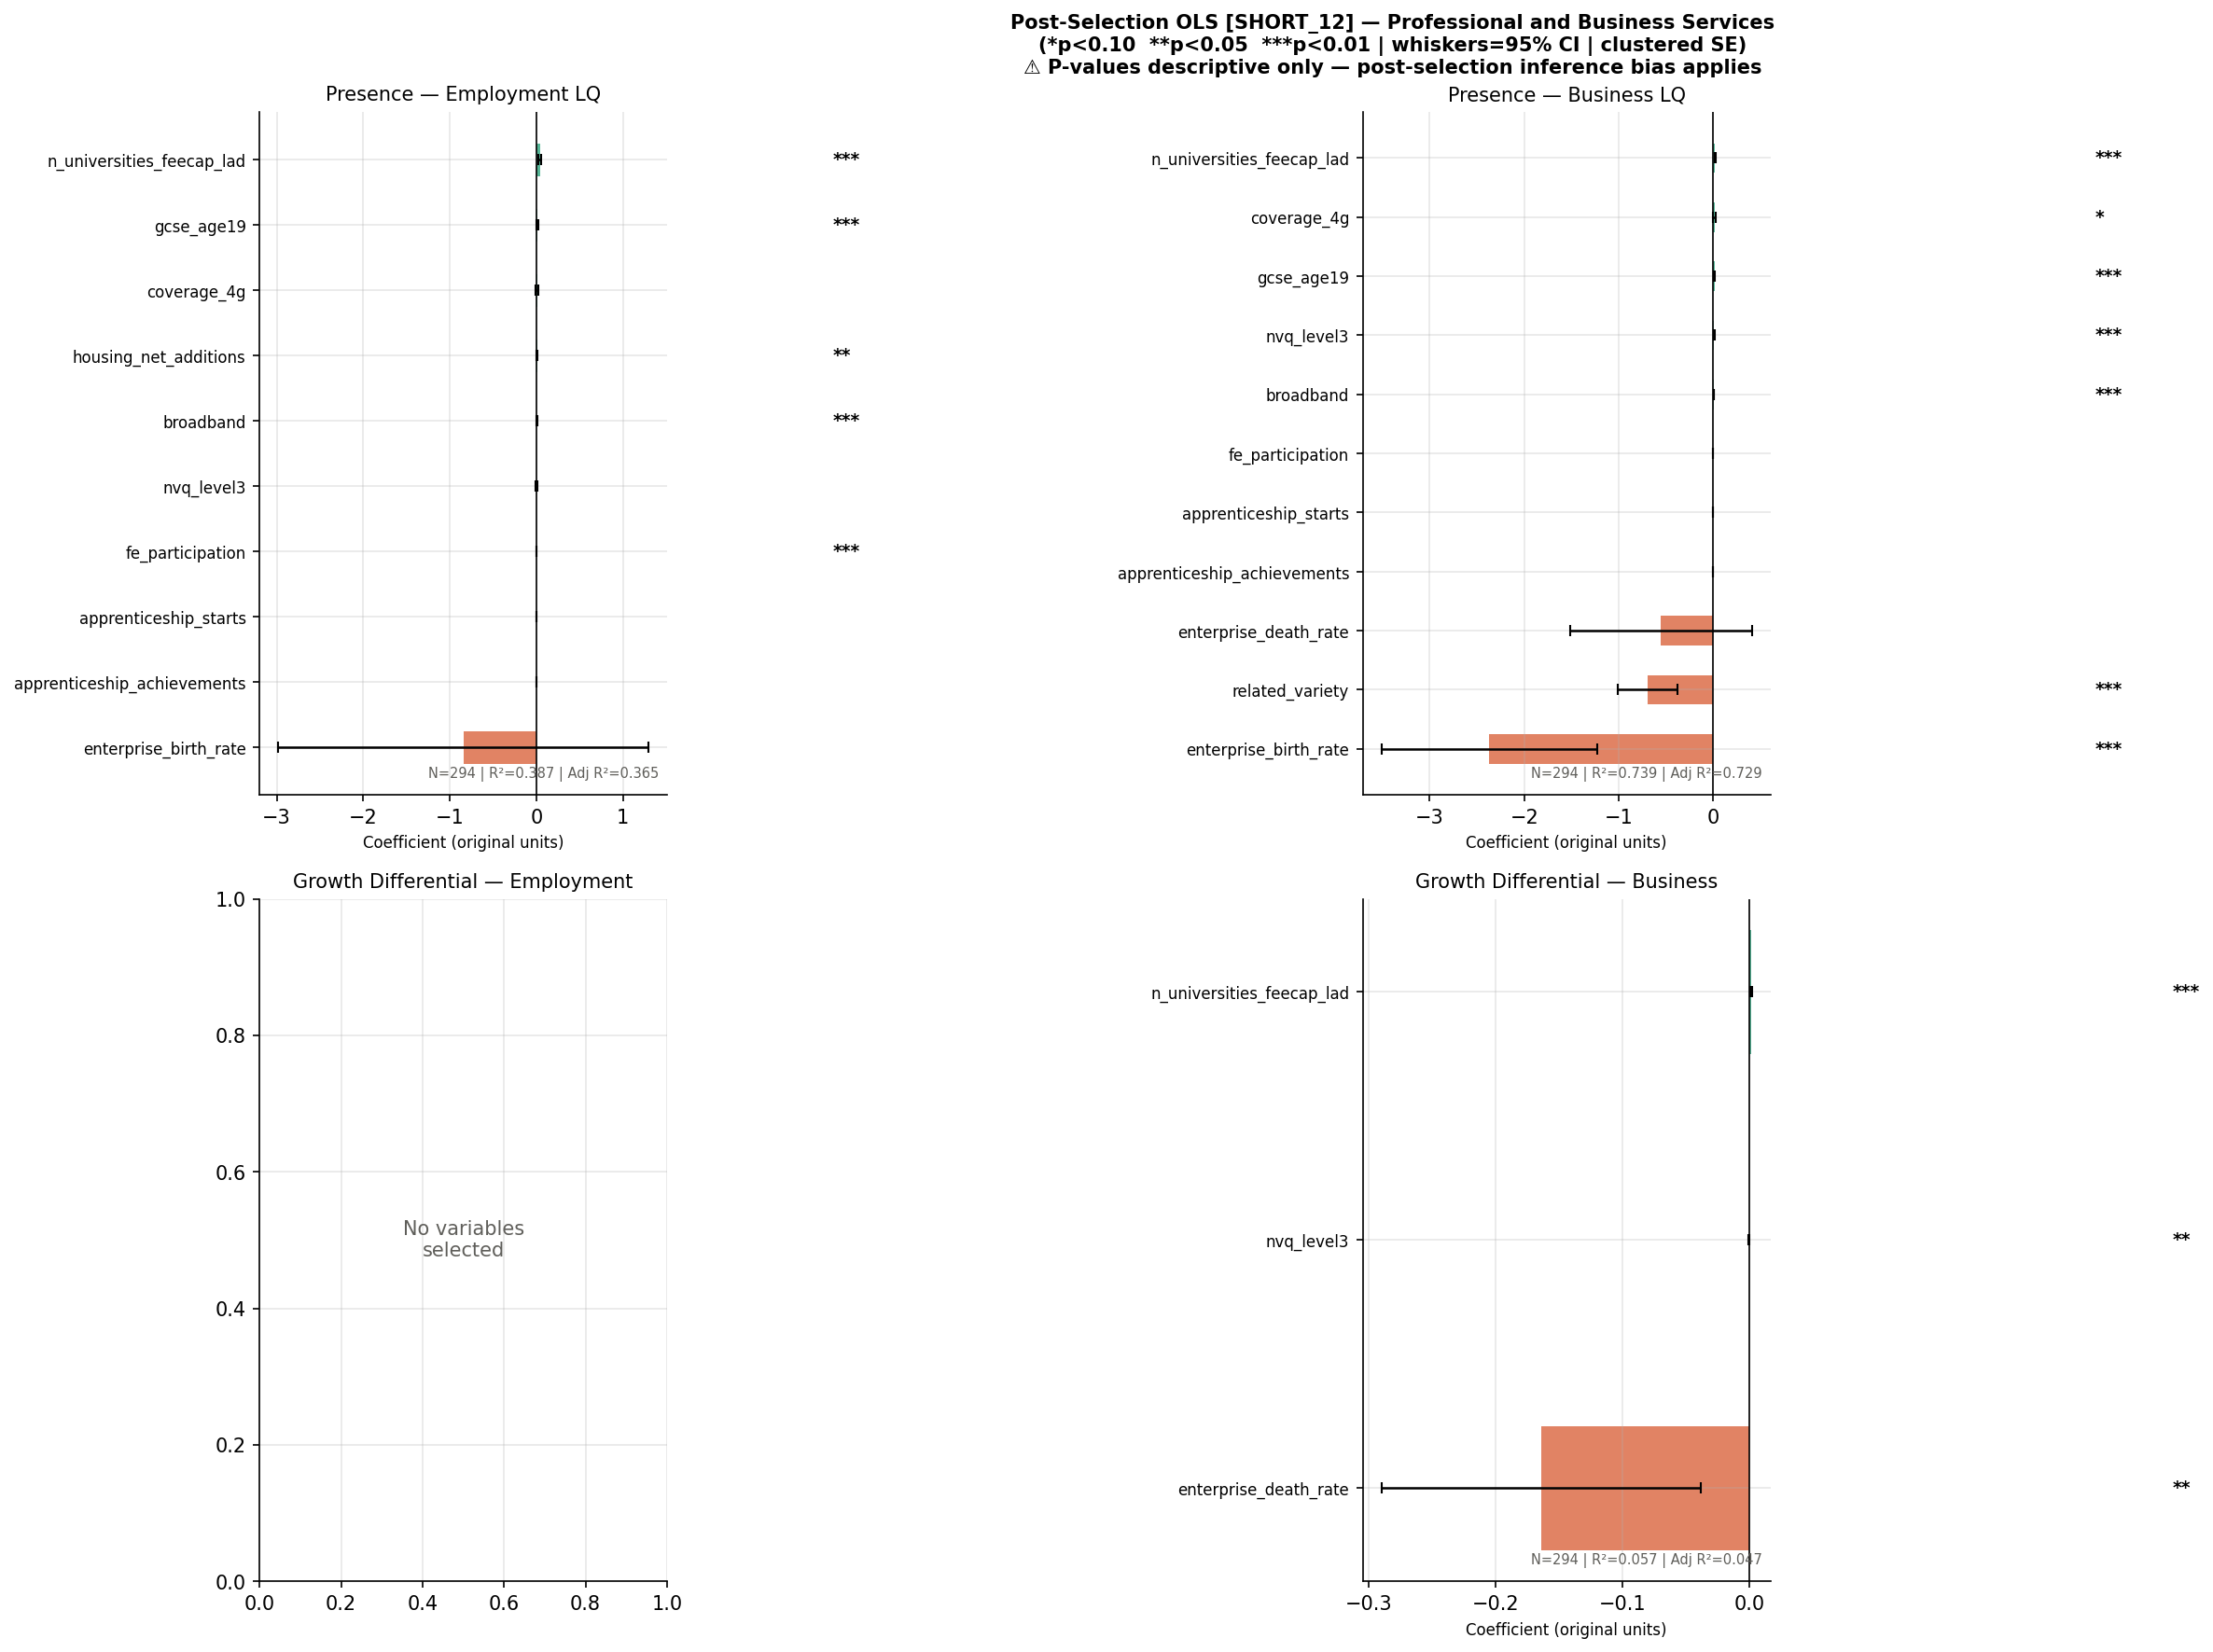

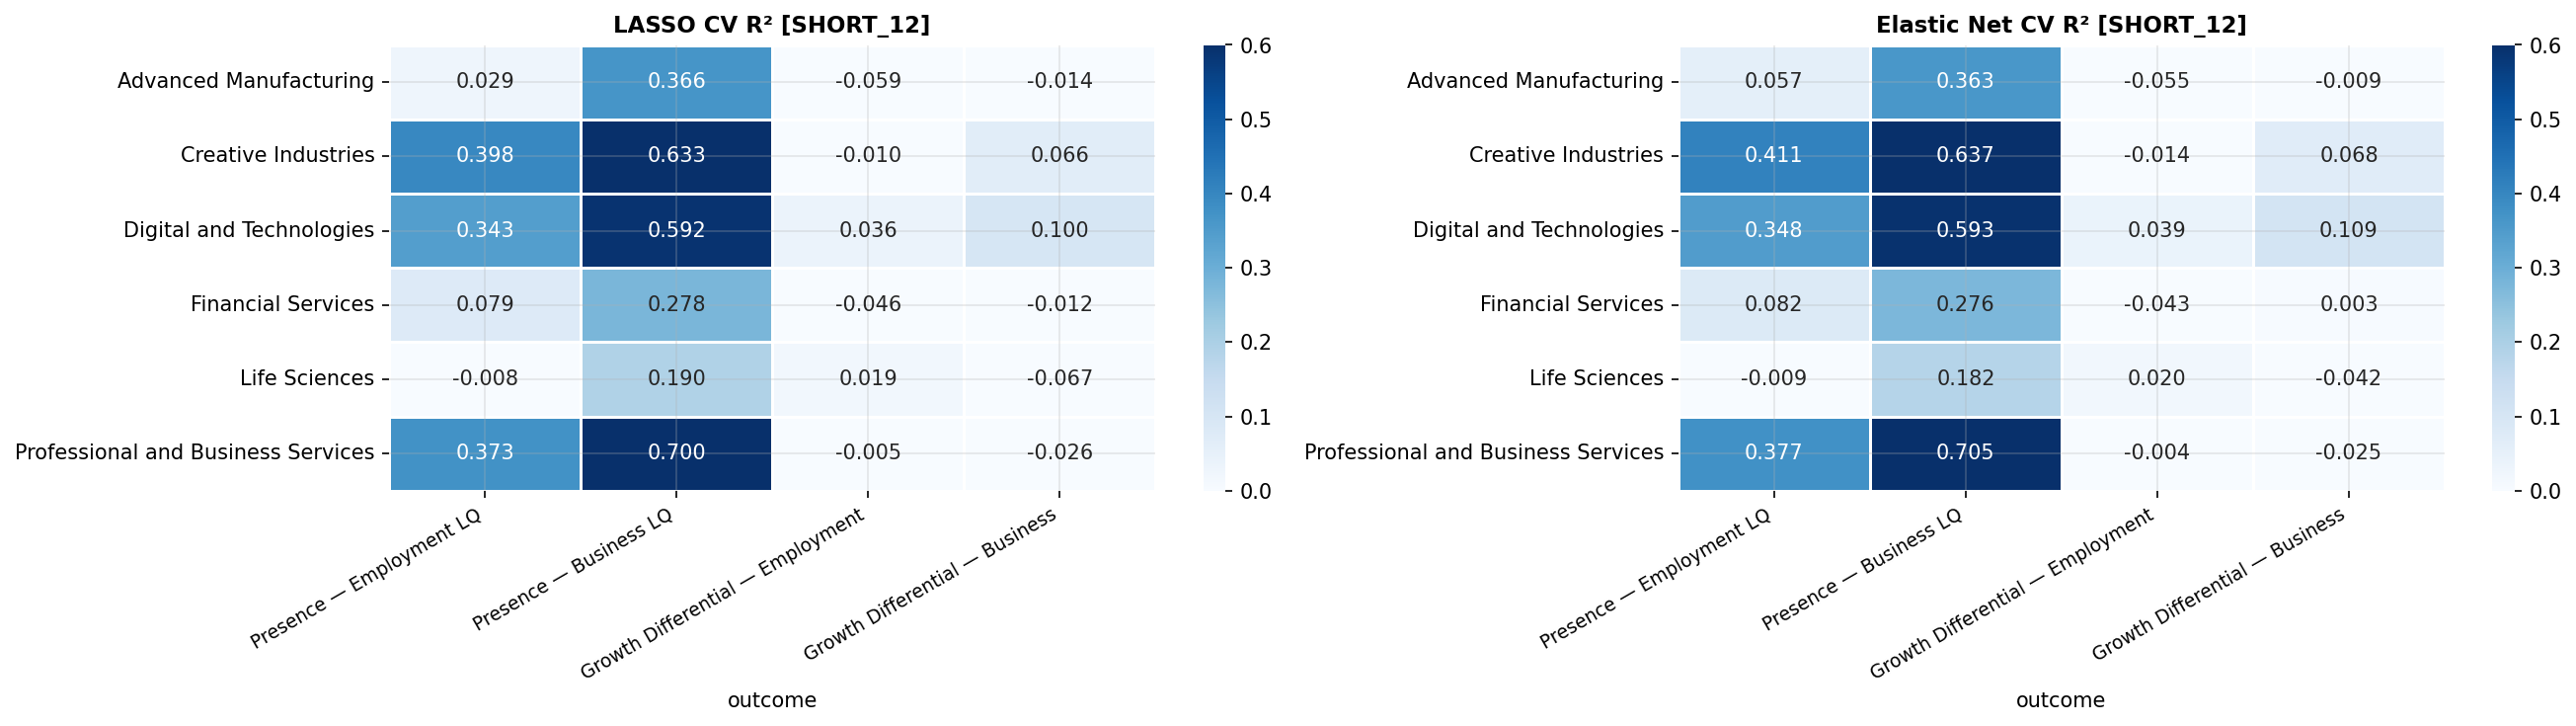

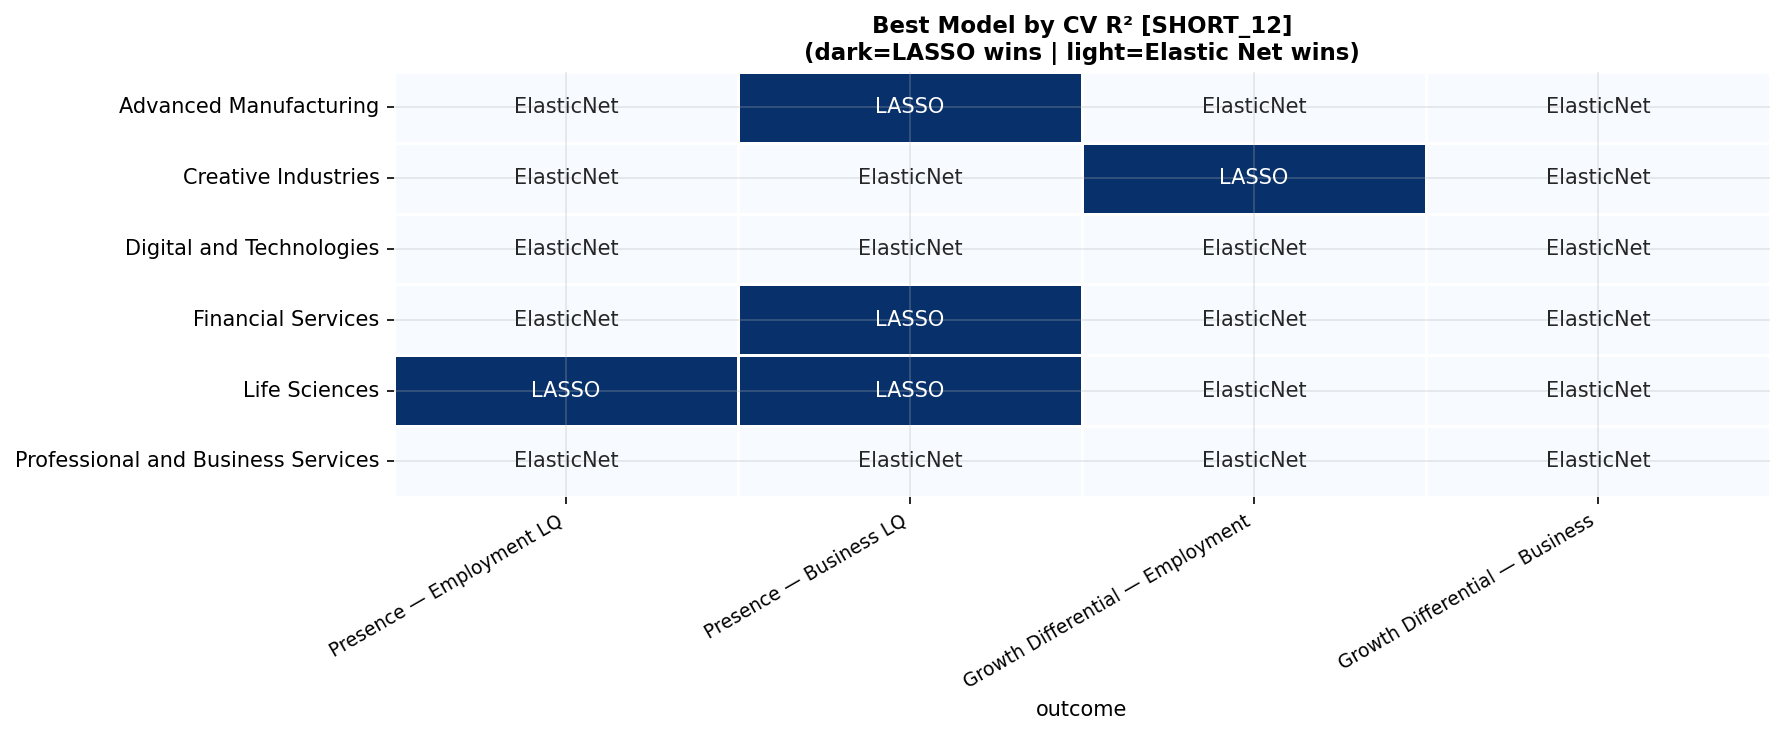

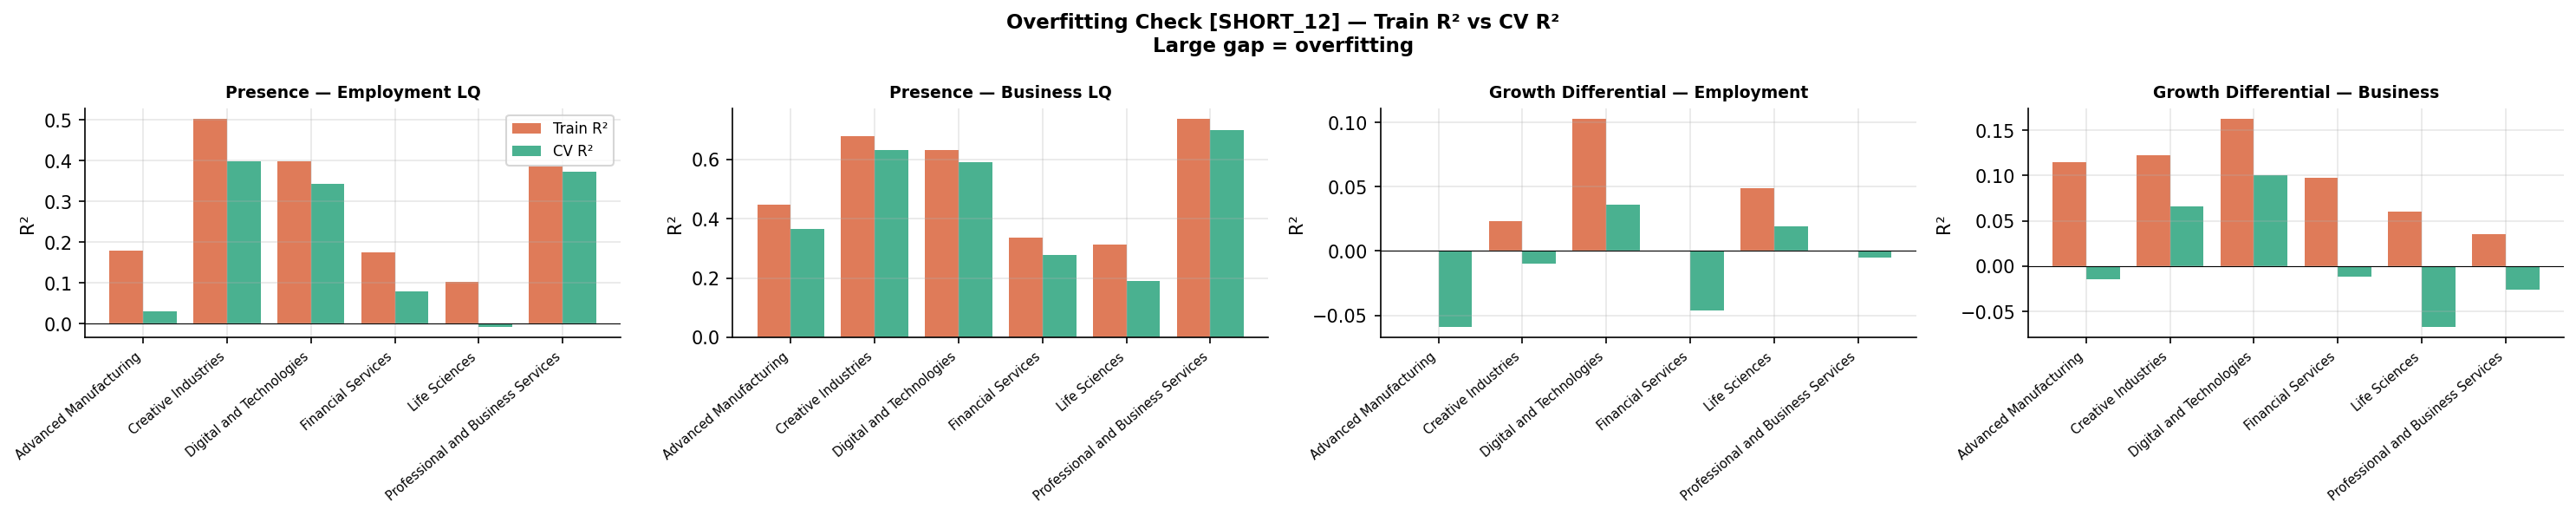


✅ [SHORT_12] complete → G:\Mi unidad\Master_LSE\Git-hub\Economic_Observatory\output\Diane_final_version\lasso_short

SPEC: FULL_31 (19 predictors)

── Advanced Manufacturing (n=296) ──
  lq_emp     n=279 | LASSO R²=0.434 [Good] | ENet R²=0.433 | Best=LASSO
  lq_bus     n=279 | LASSO R²=0.534 [Good] | ENet R²=0.538 | Best=ElasticNet
  gd_emp     n=279 | LASSO R²=-0.043 [Not recommended] | ENet R²=-0.049 | Best=LASSO
  gd_bus     n=279 | LASSO R²=0.009 [Not recommended] | ENet R²=0.007 | Best=LASSO

── Creative Industries (n=296) ──
  lq_emp     n=279 | LASSO R²=0.506 [Good] | ENet R²=0.512 | Best=ElasticNet
  lq_bus     n=279 | LASSO R²=0.613 [Good] | ENet R²=0.634 | Best=ElasticNet
  gd_emp     n=279 | LASSO R²=0.020 [Not recommended] | ENet R²=0.037 | Best=ElasticNet
  gd_bus     n=279 | LASSO R²=0.110 [Marginal] | ENet R²=0.107 | Best=LASSO

── Digital and Technologies (n=296) ──
  lq_emp     n=279 | LASSO R²=0.556 [Good] | ENet R²=0.561 | Best=ElasticNet
  lq_bus     n=279 | LASSO 

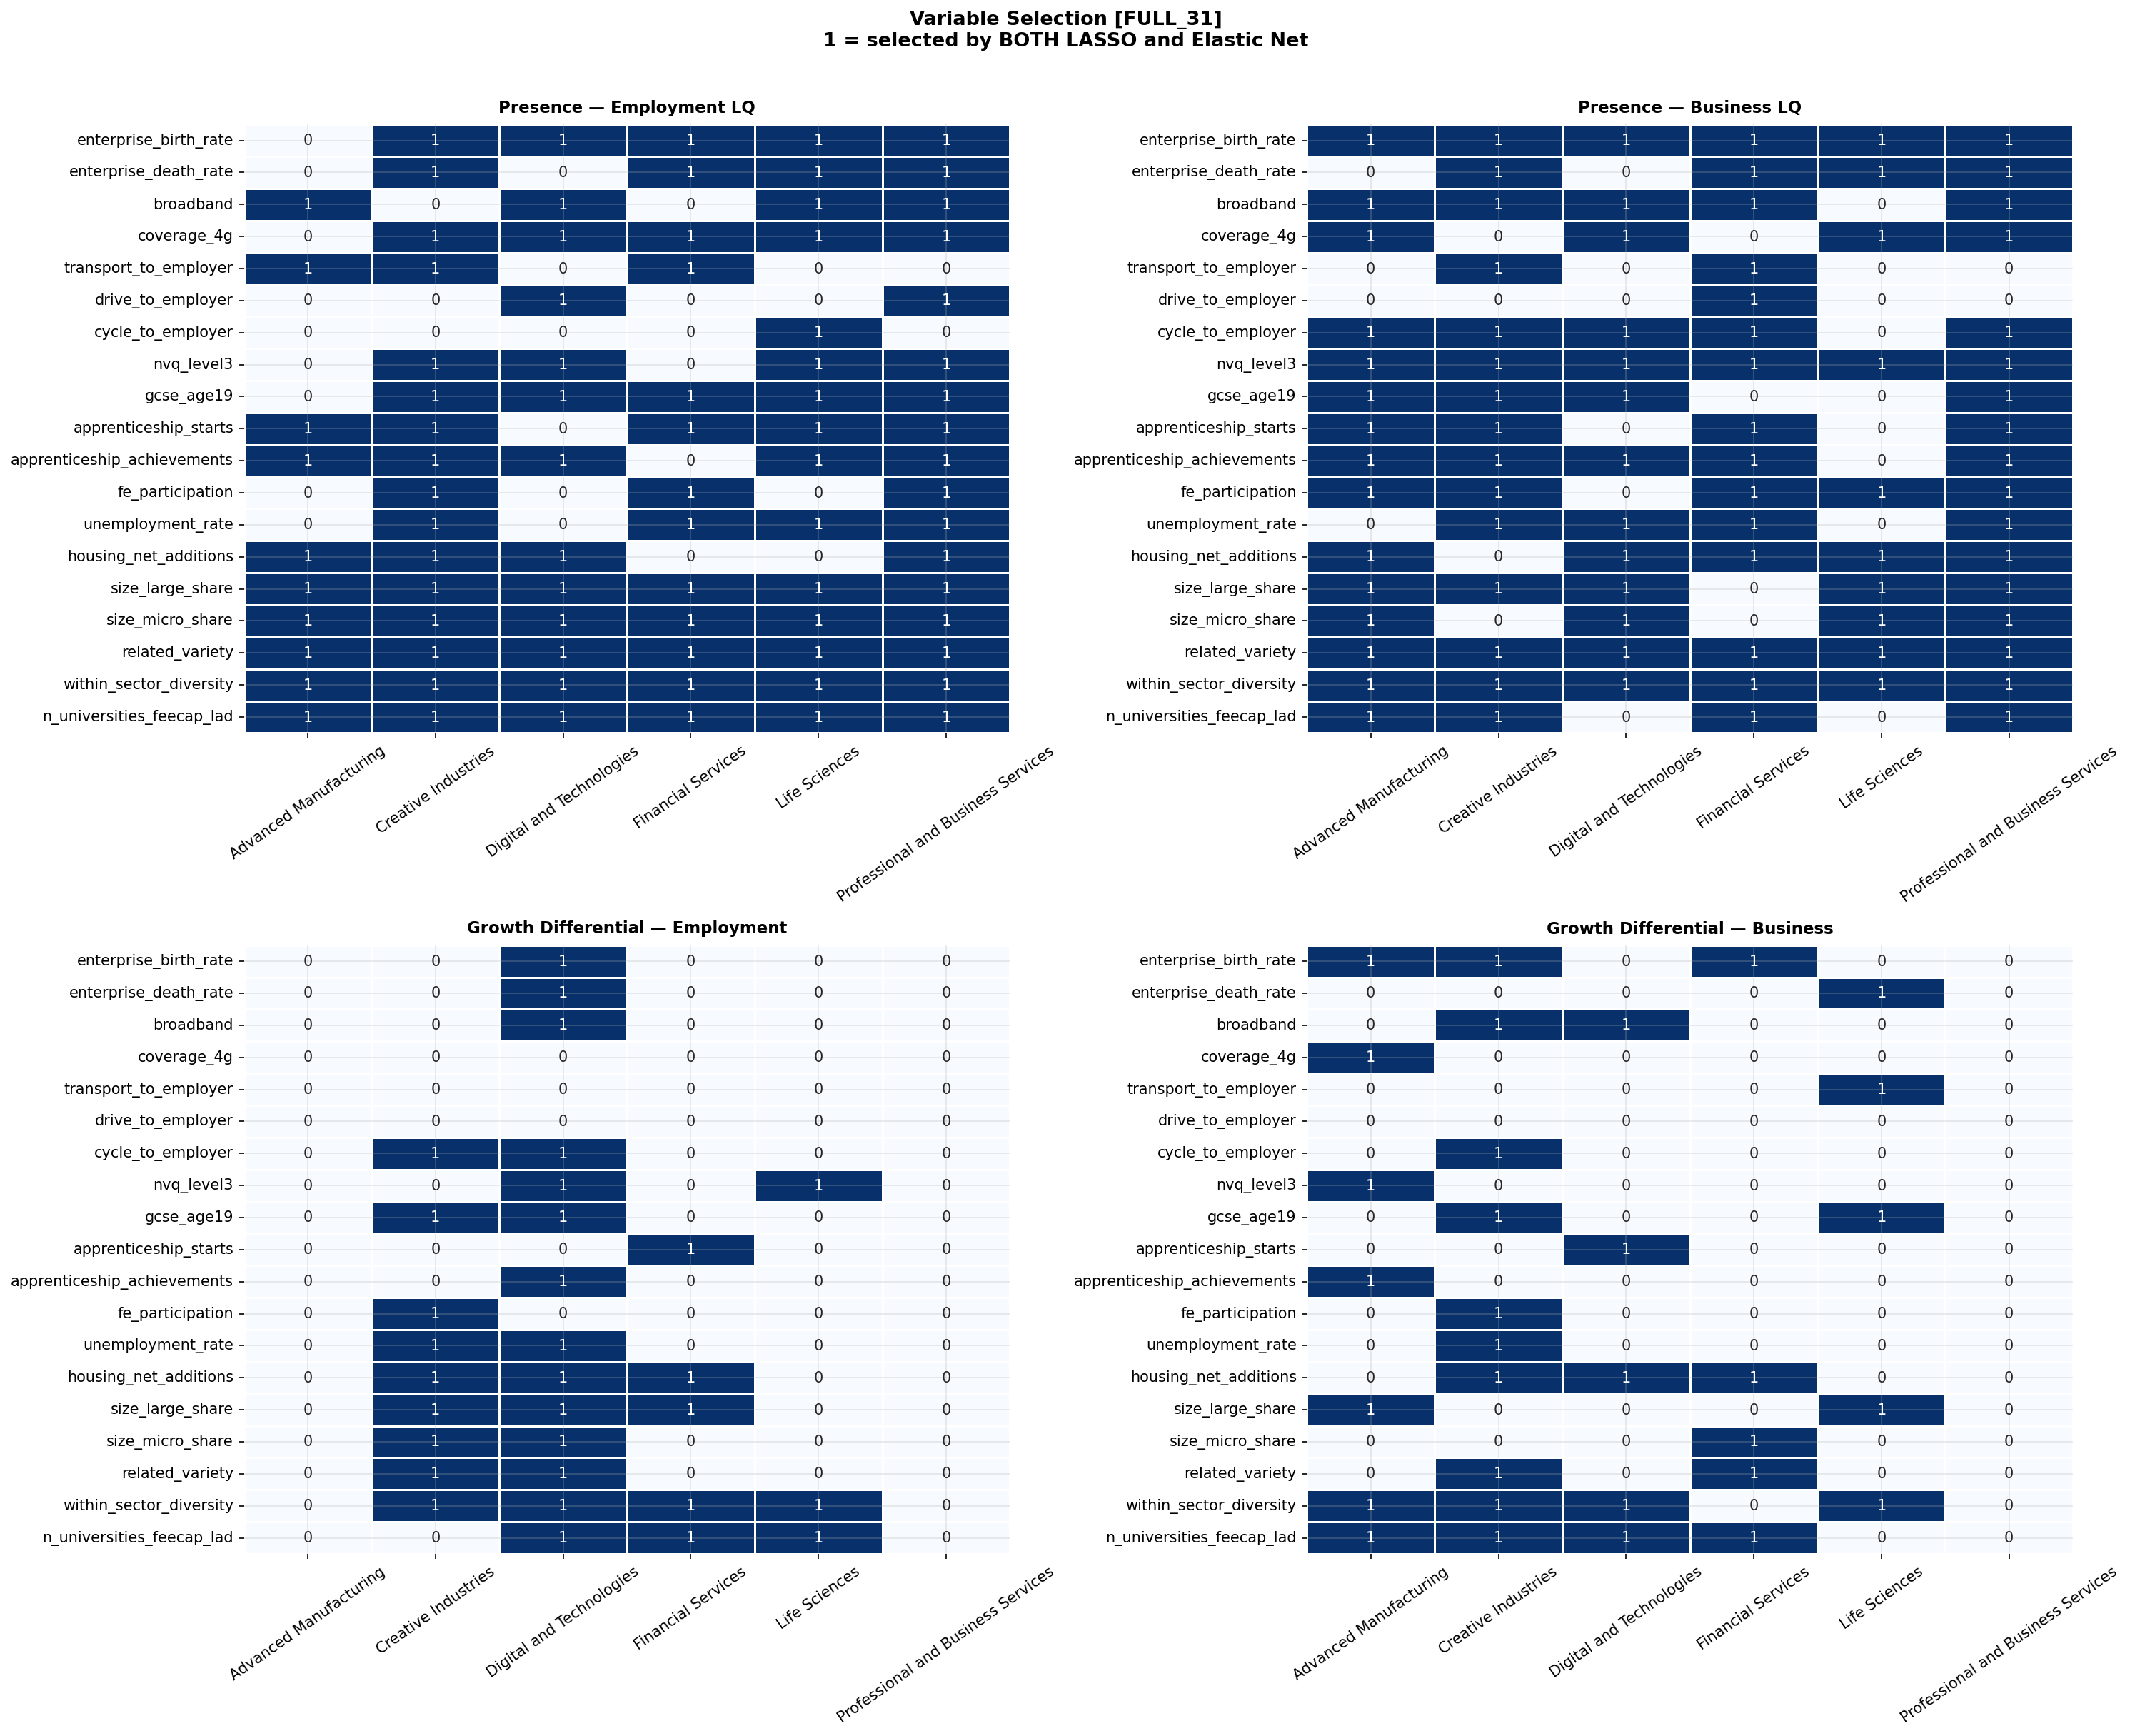

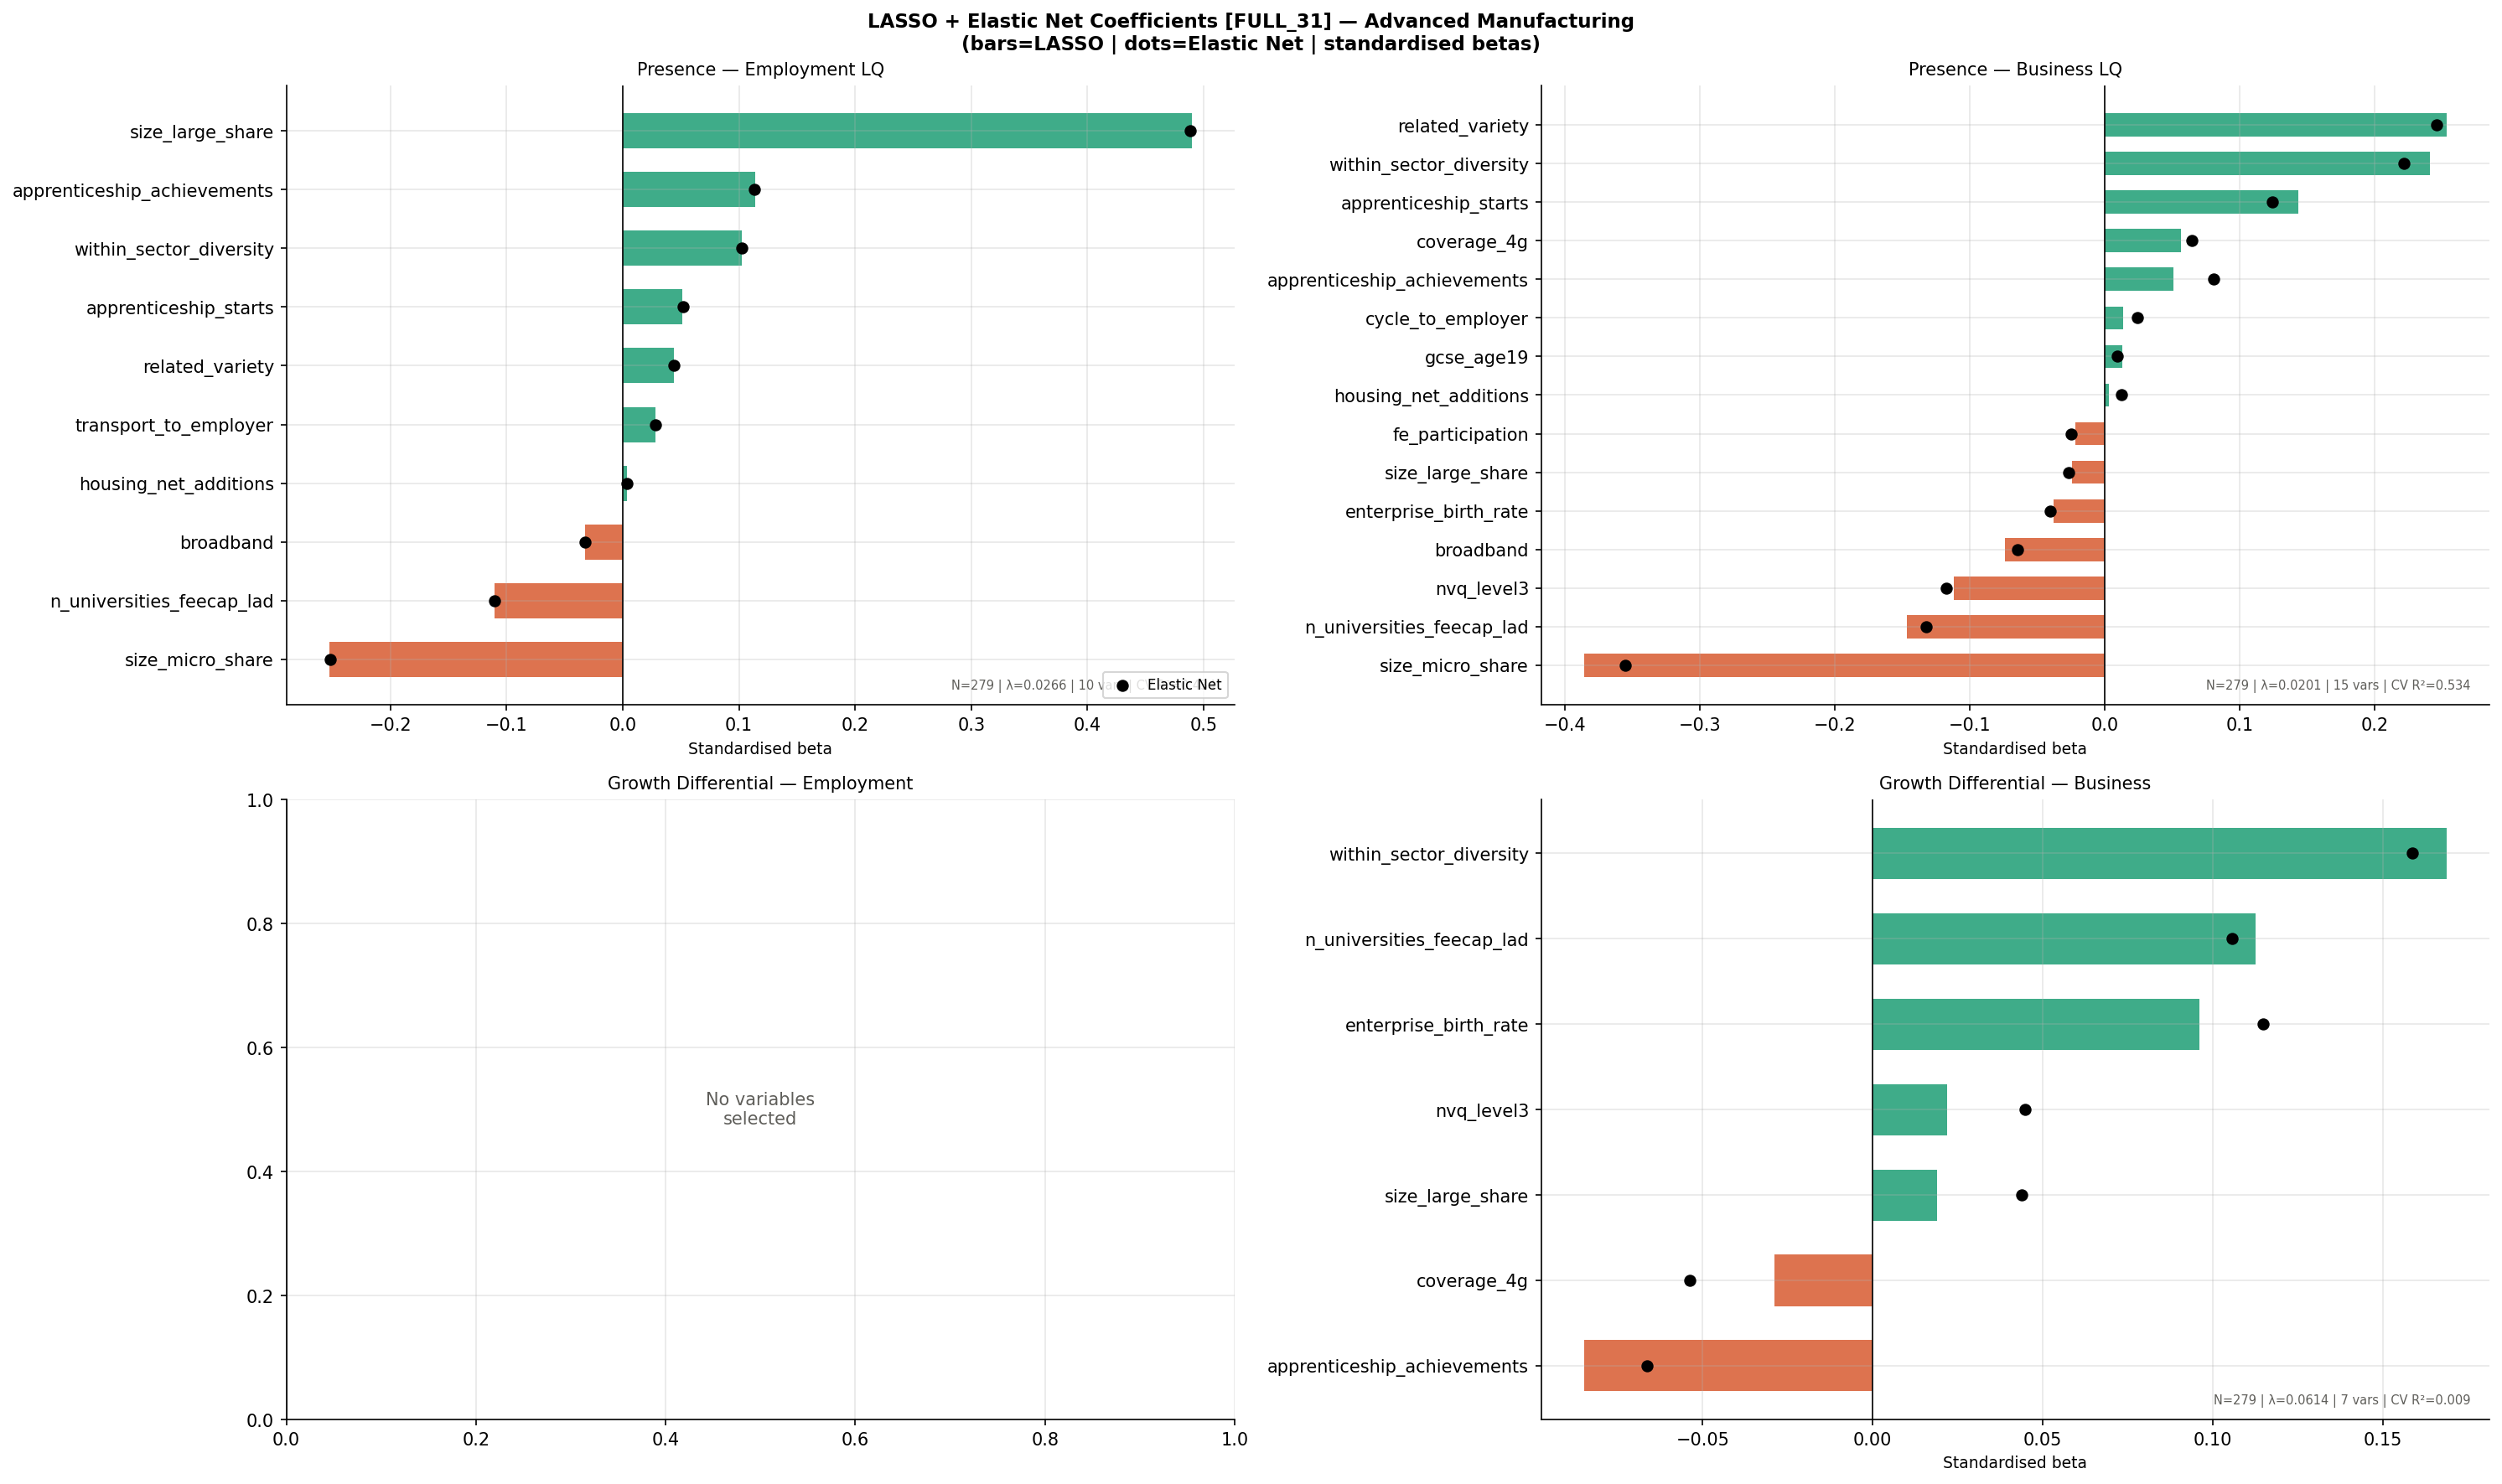

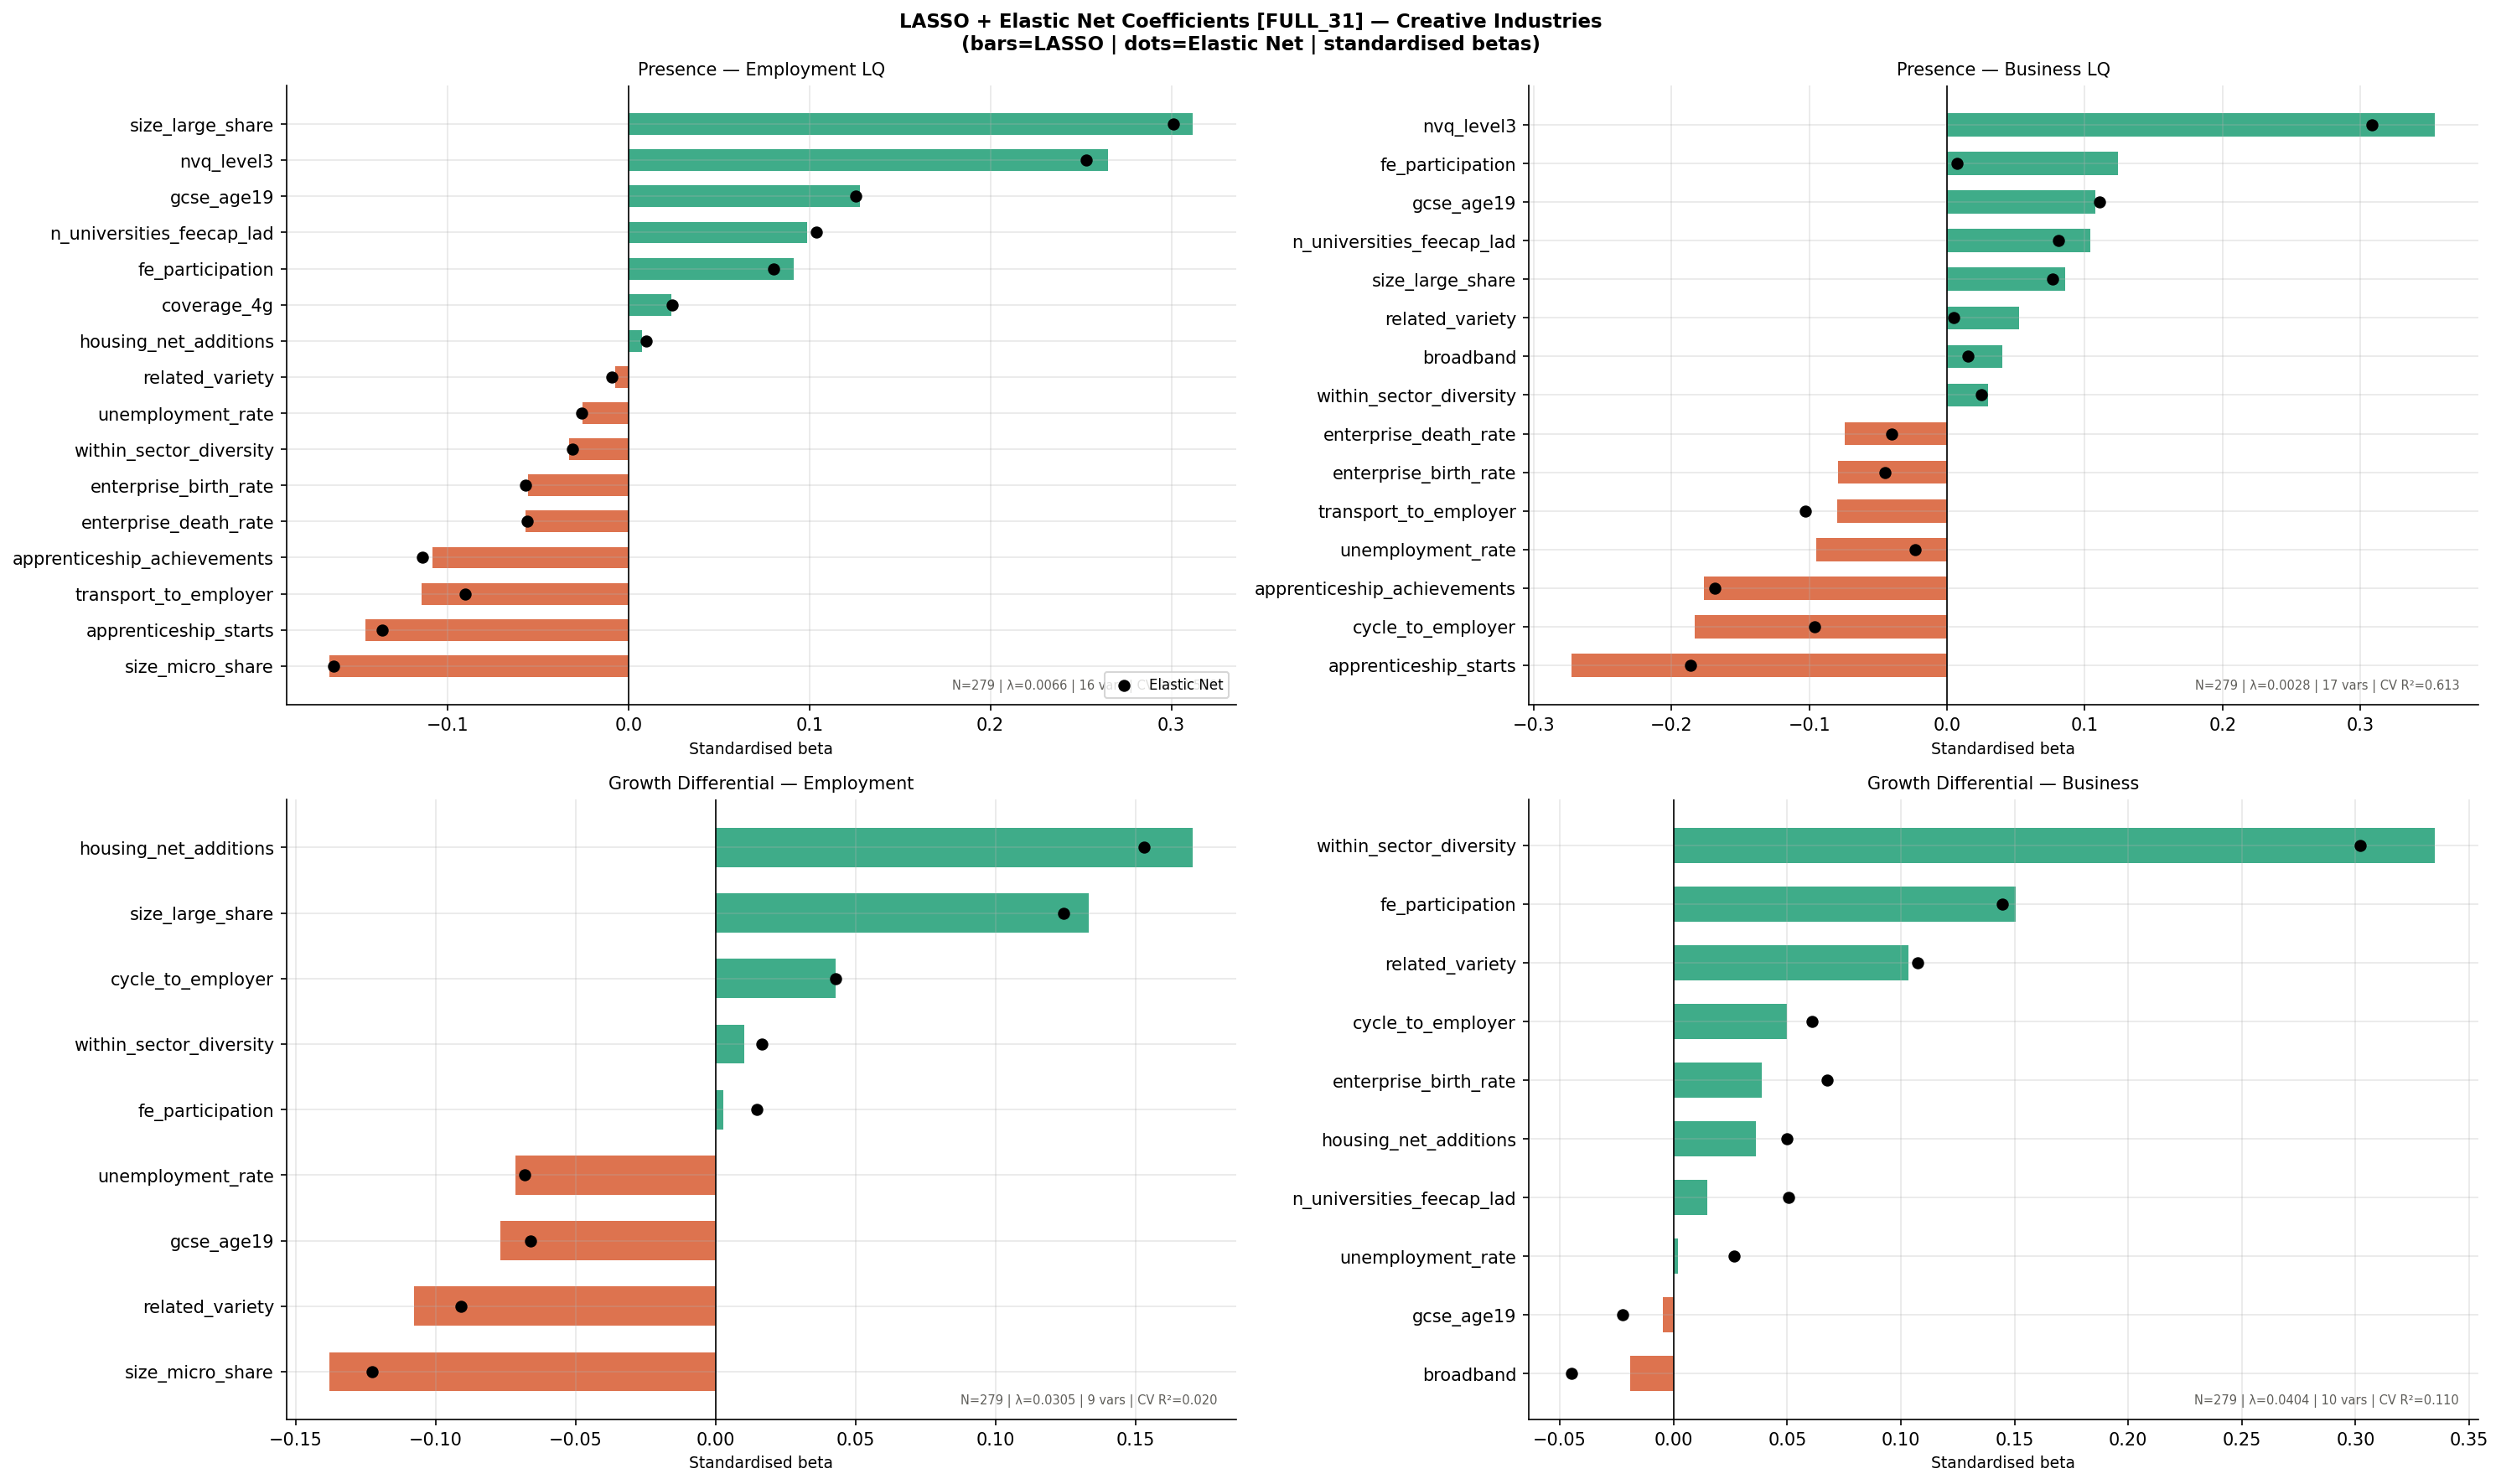

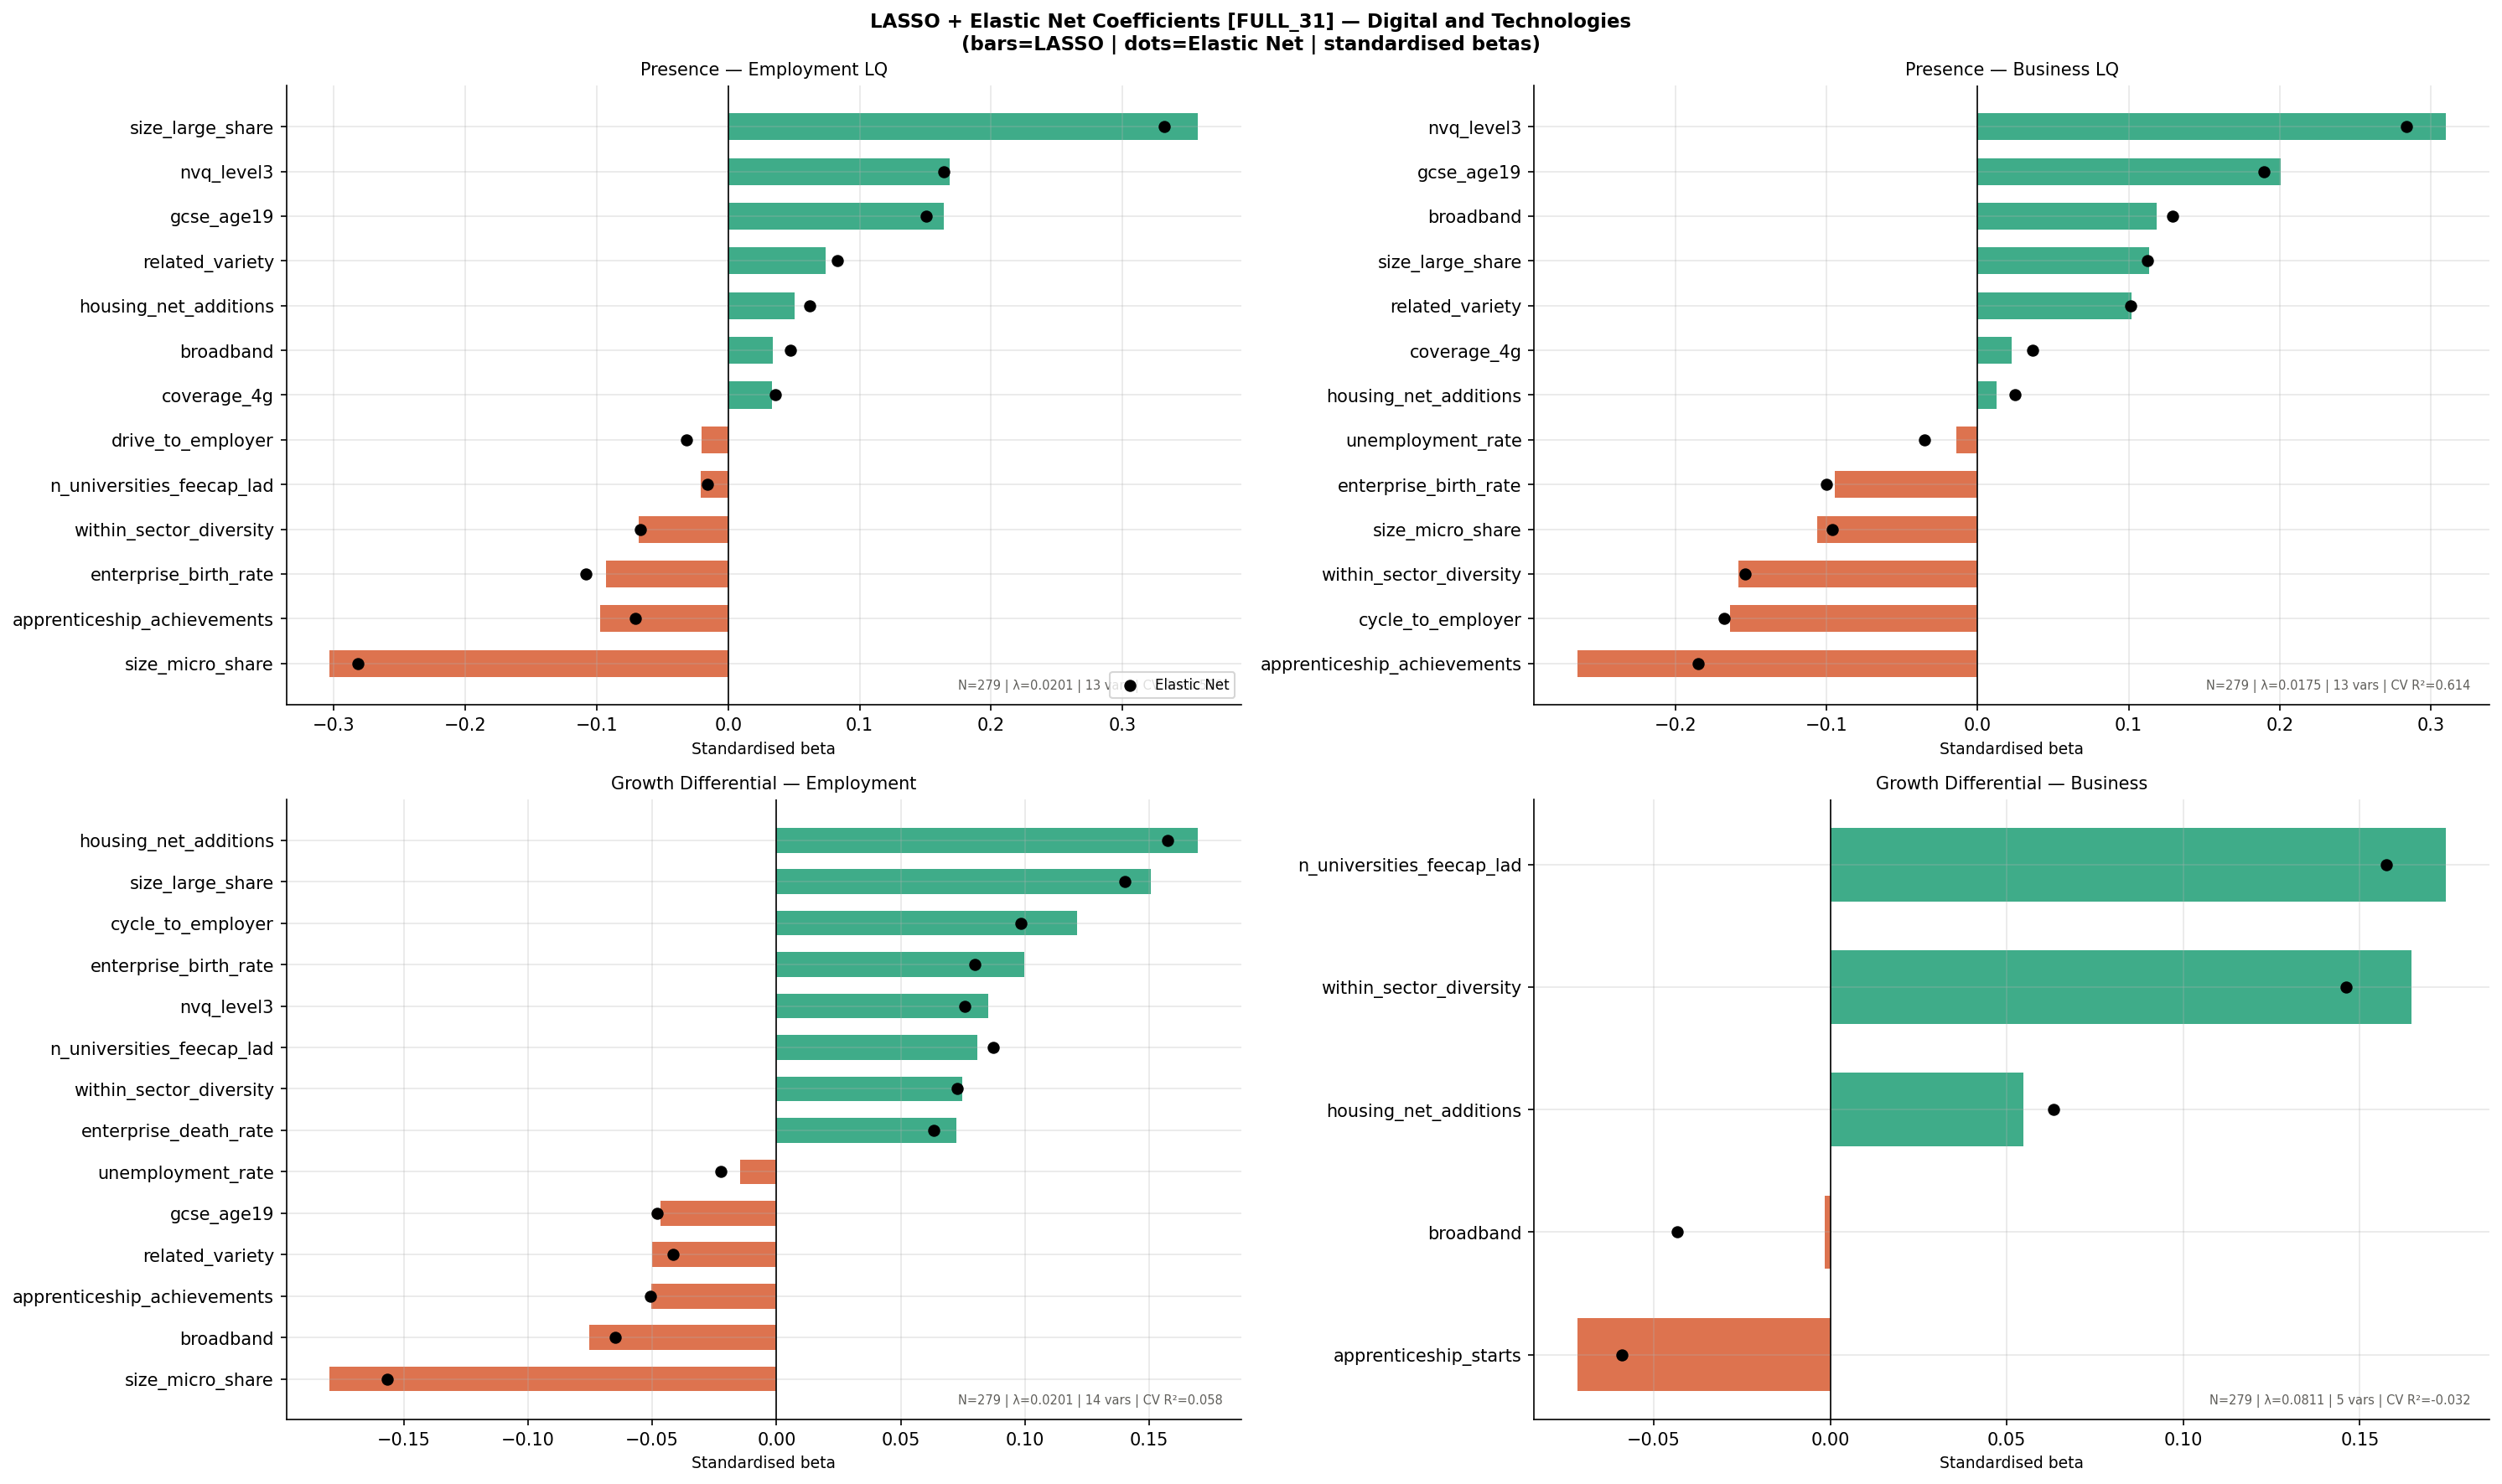

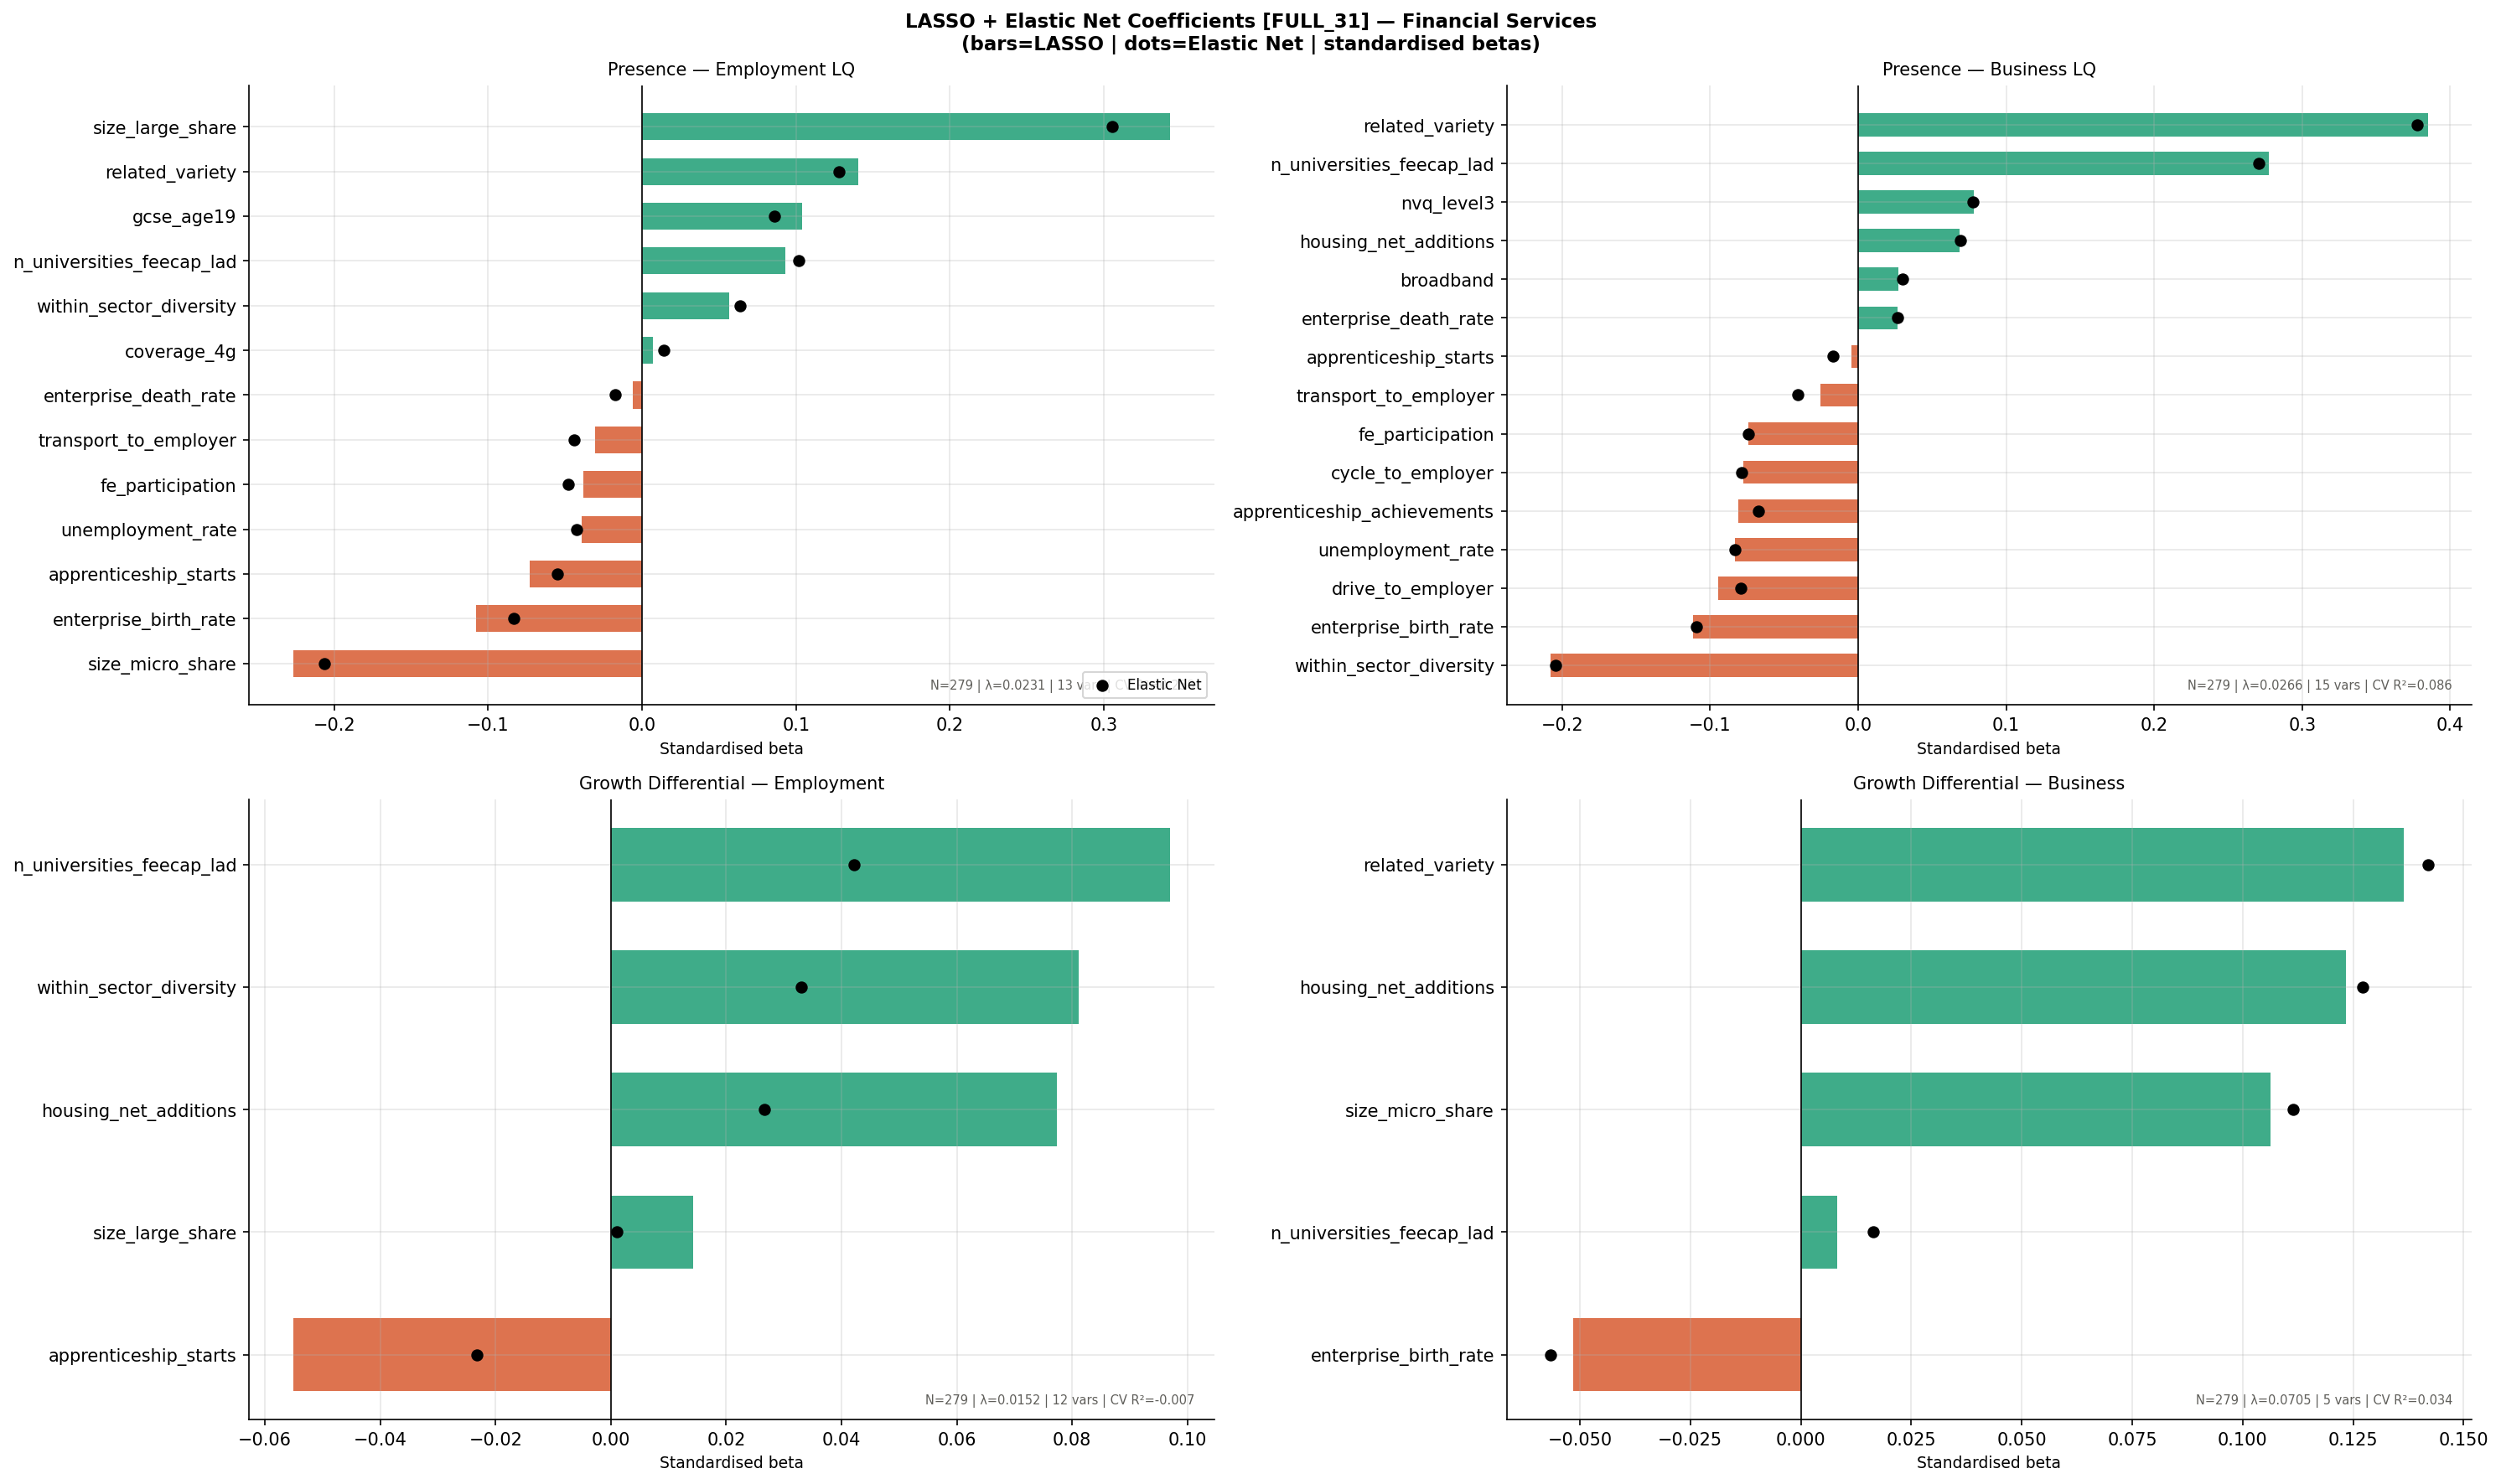

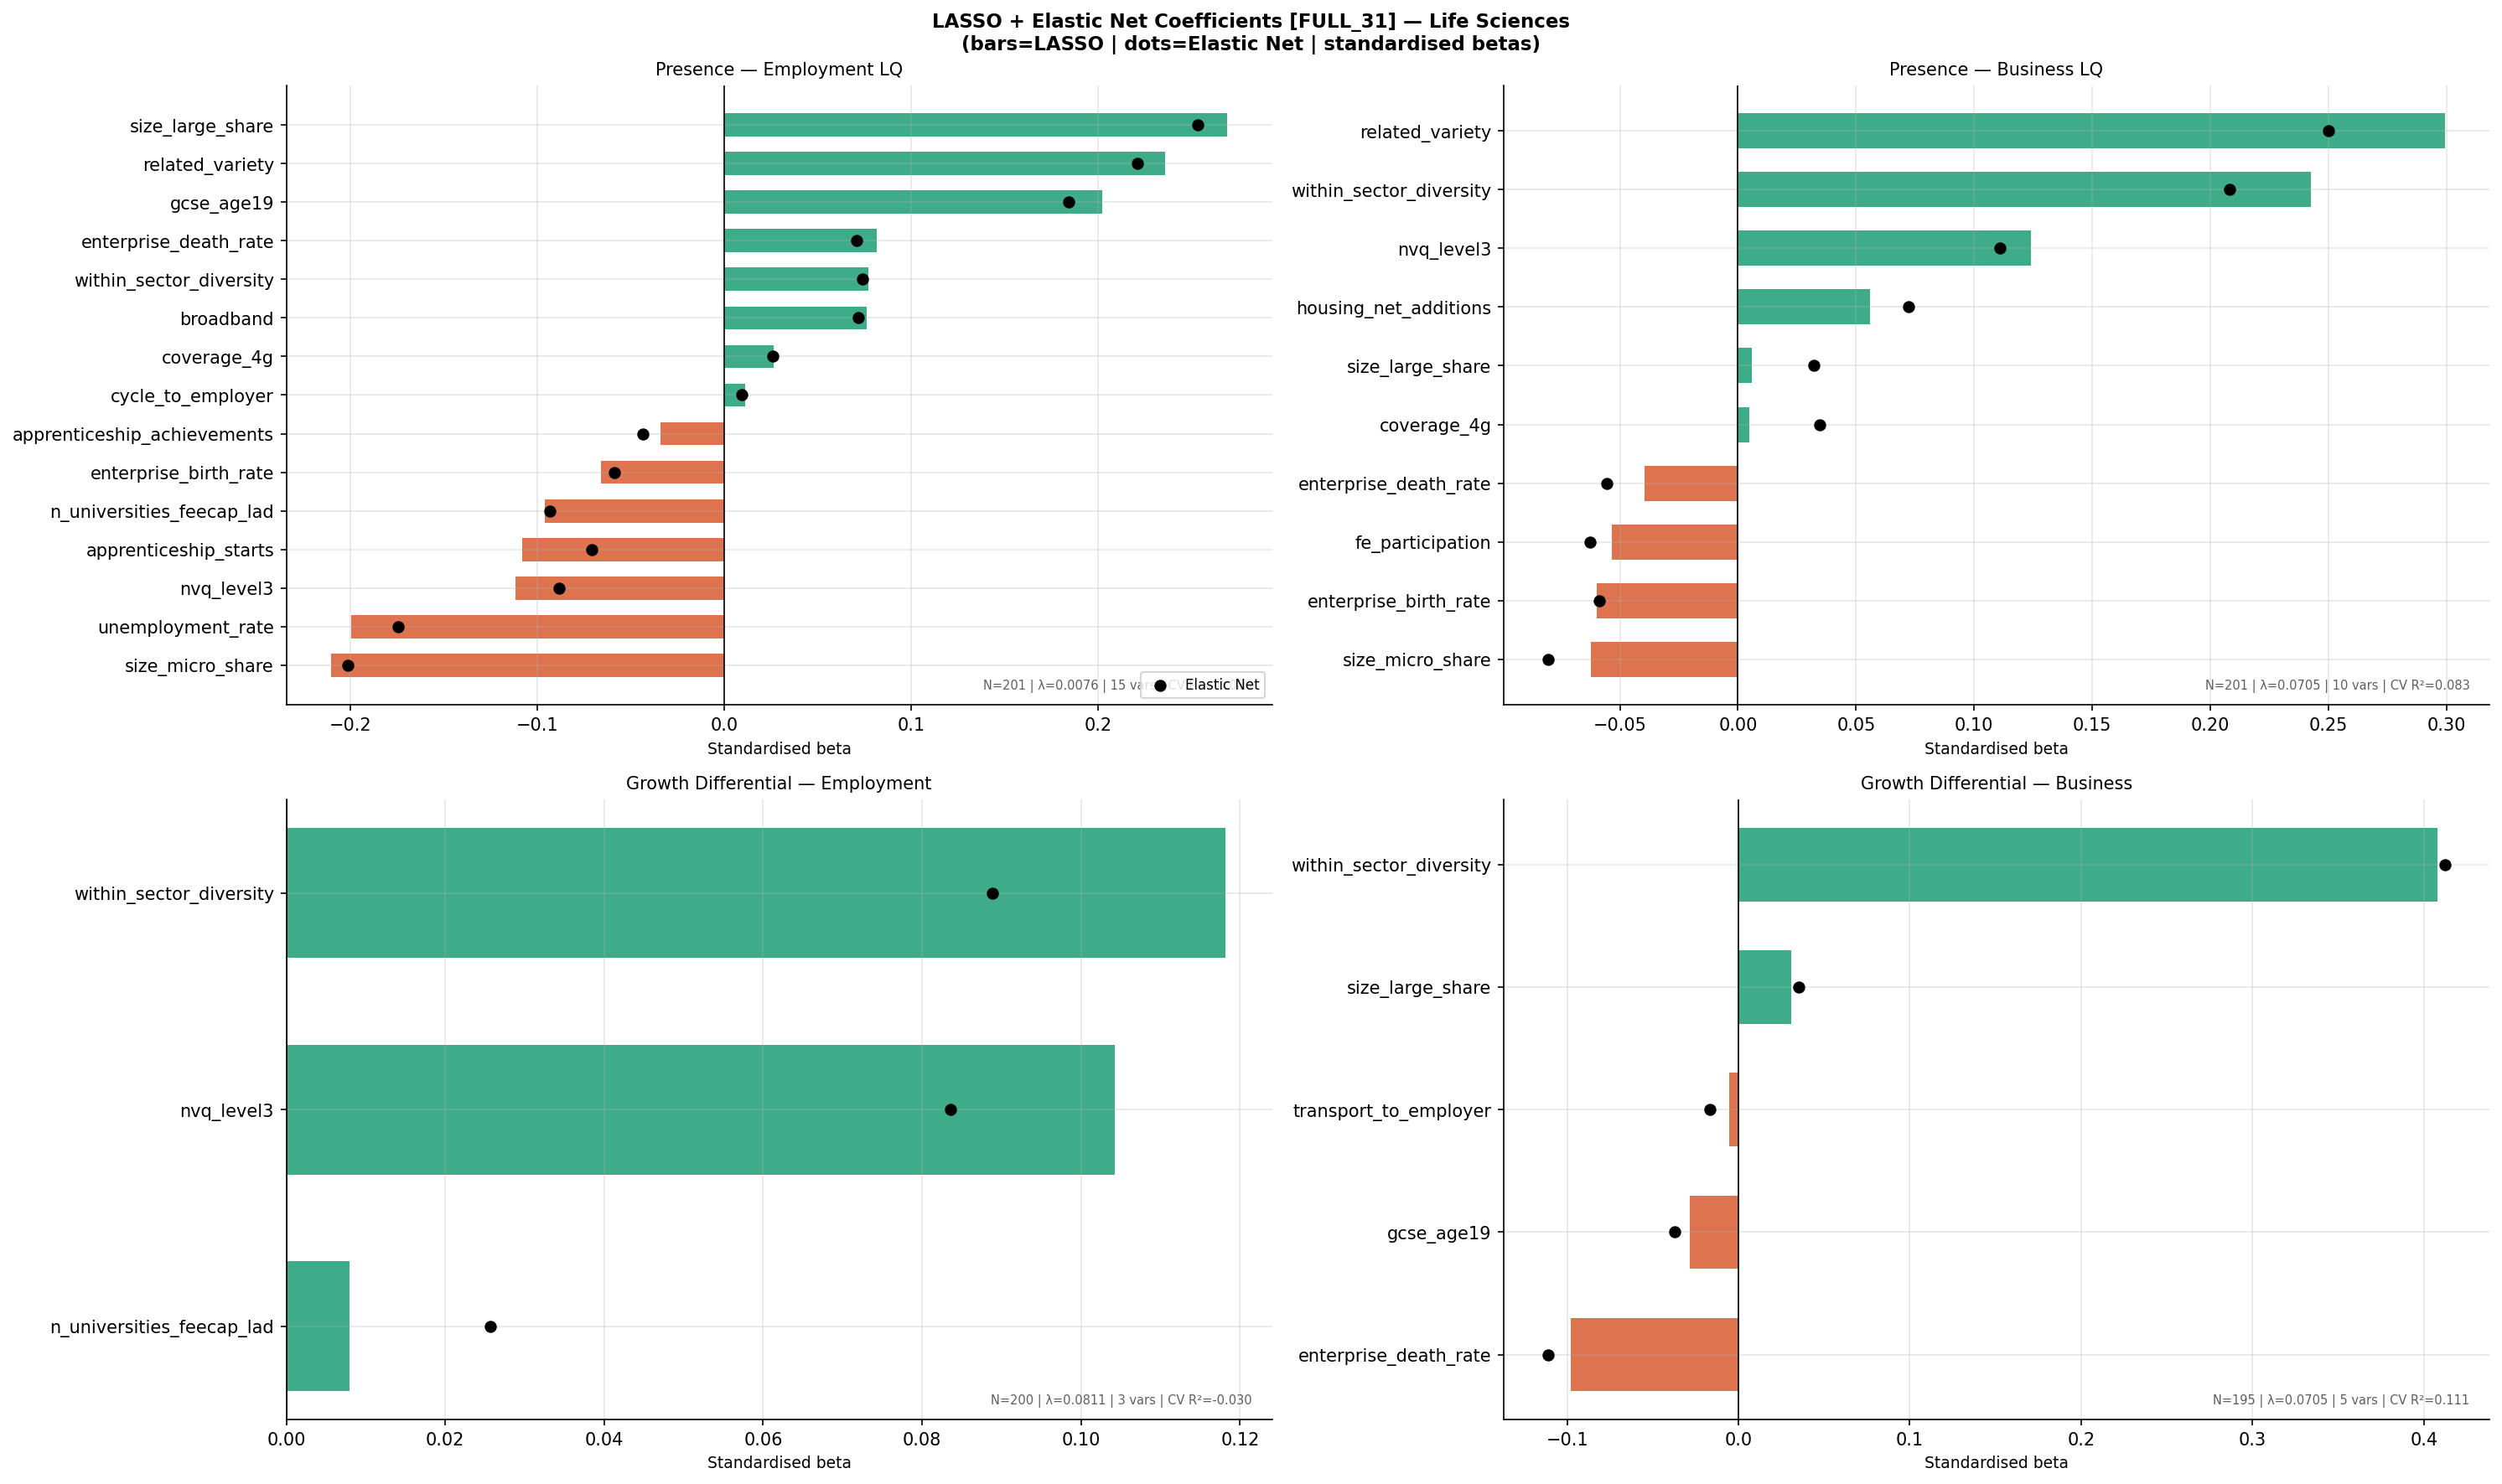

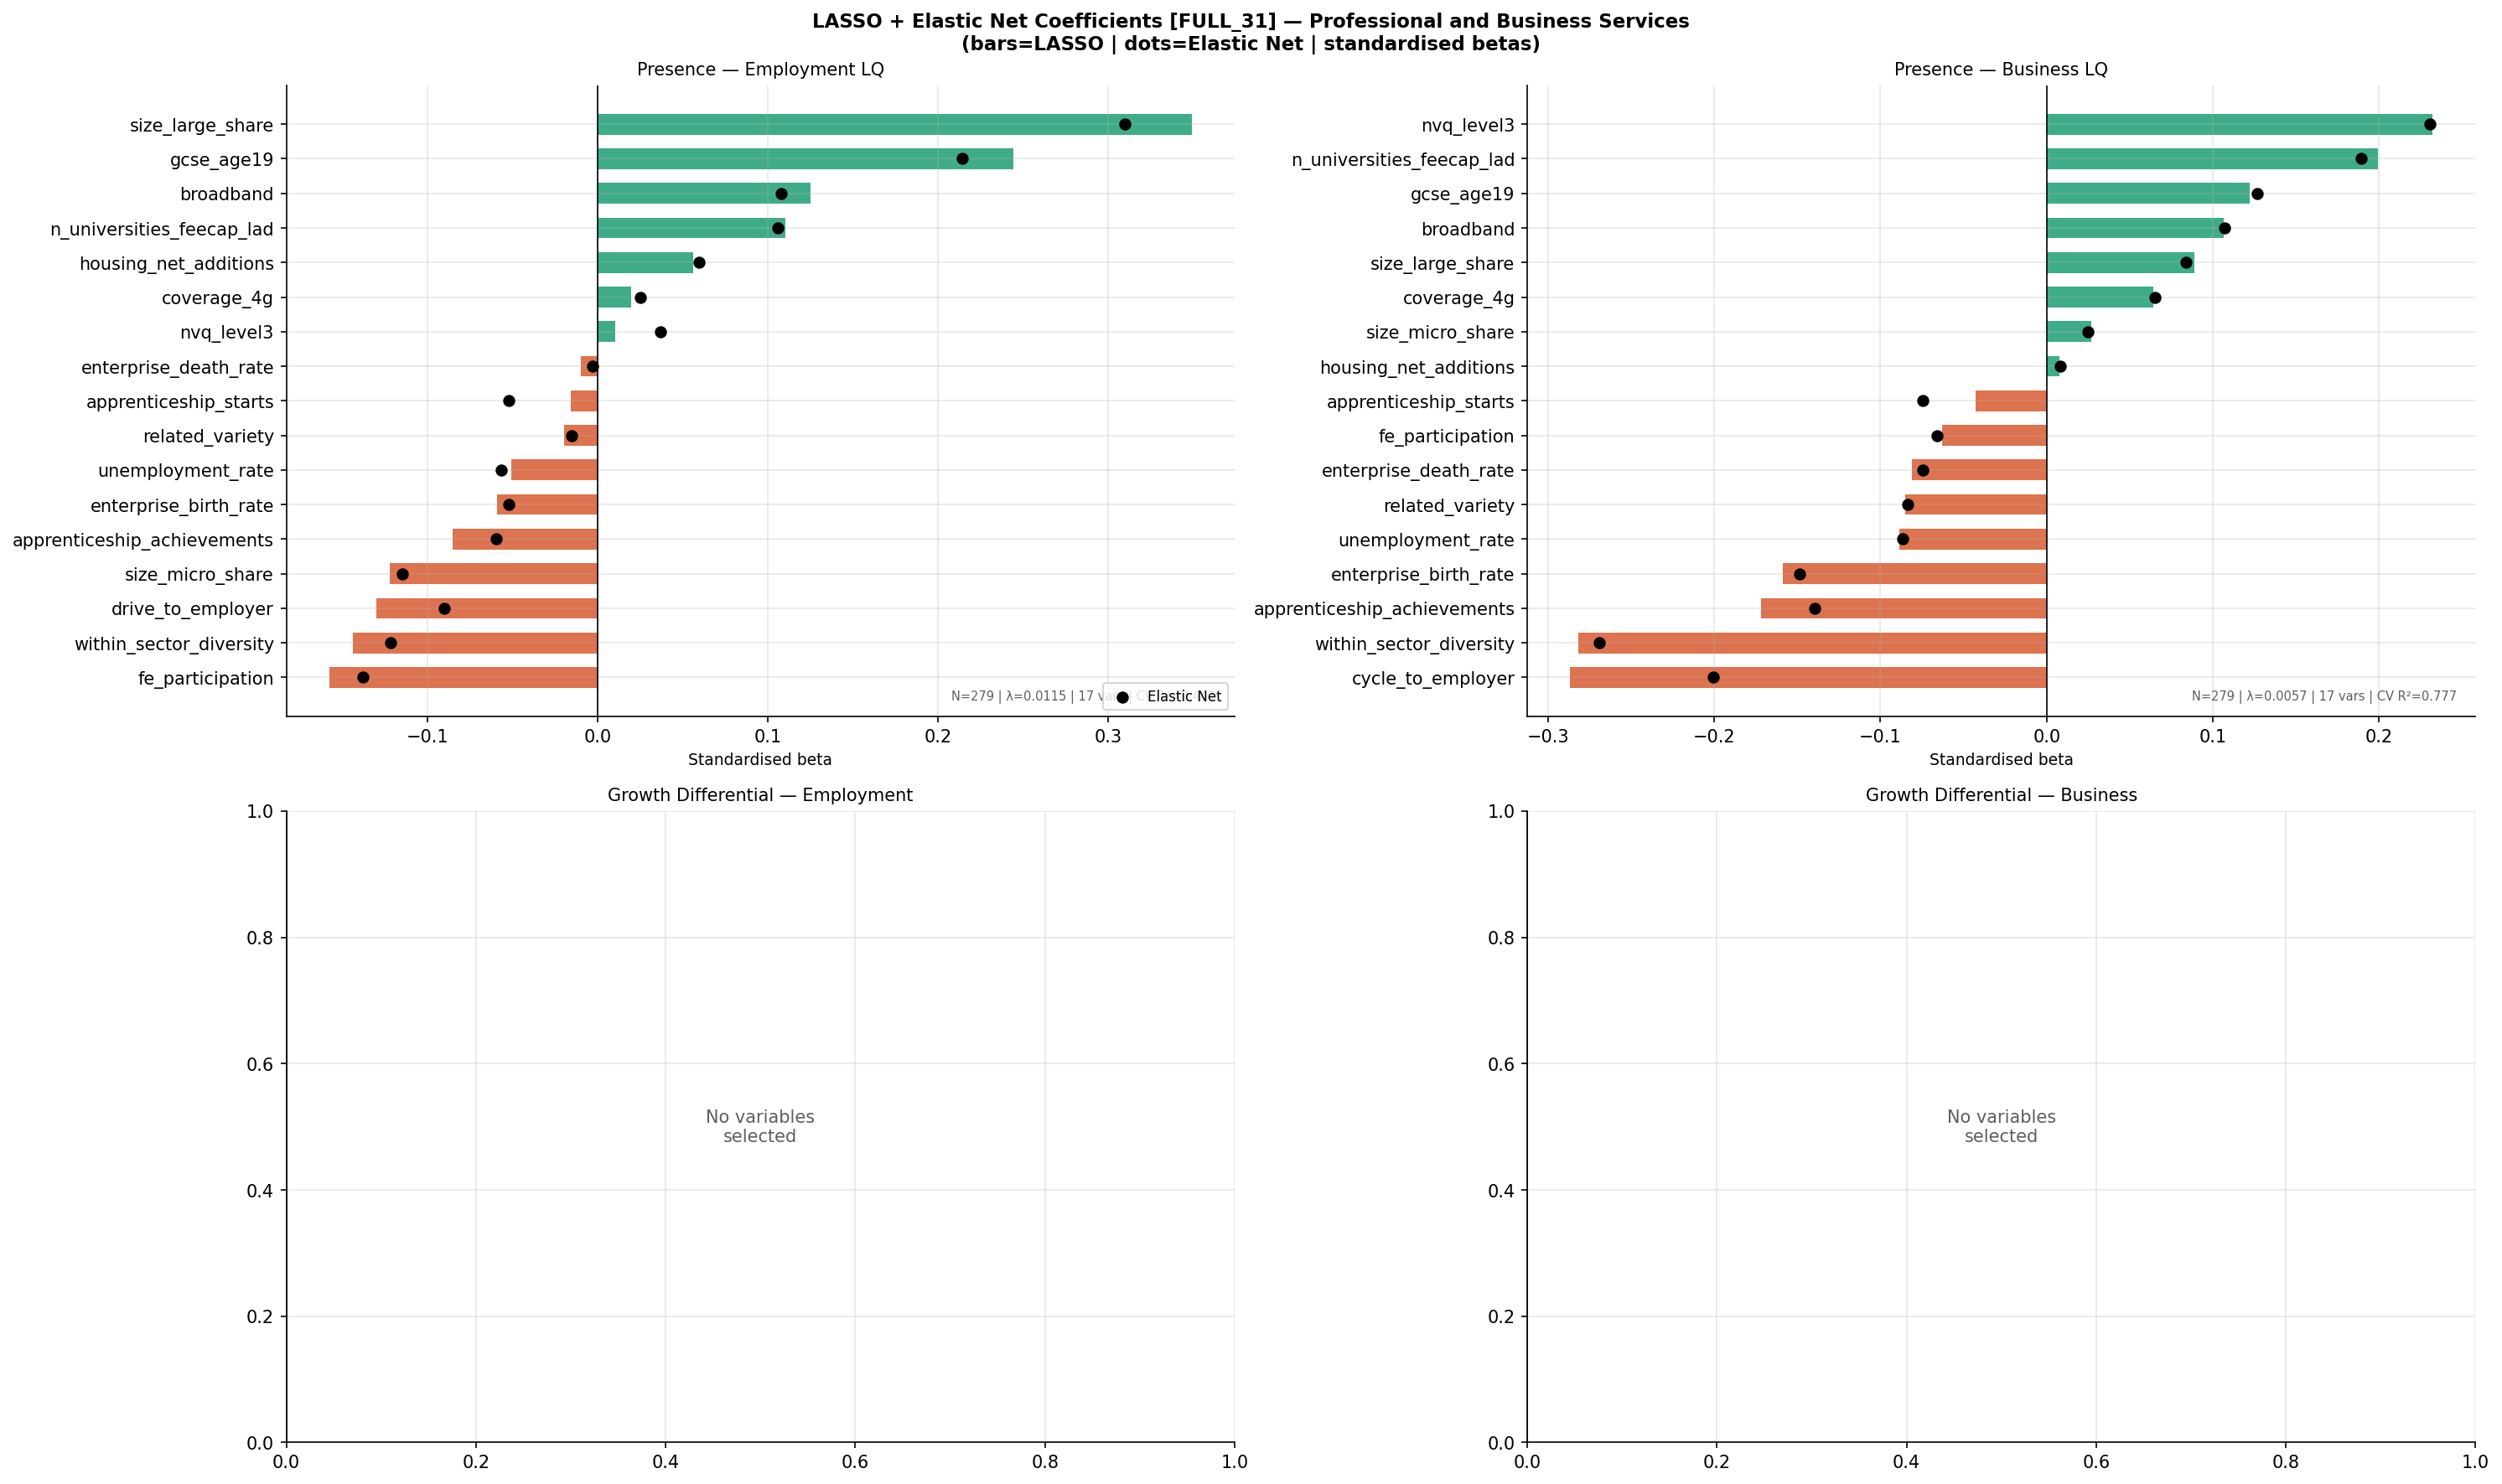

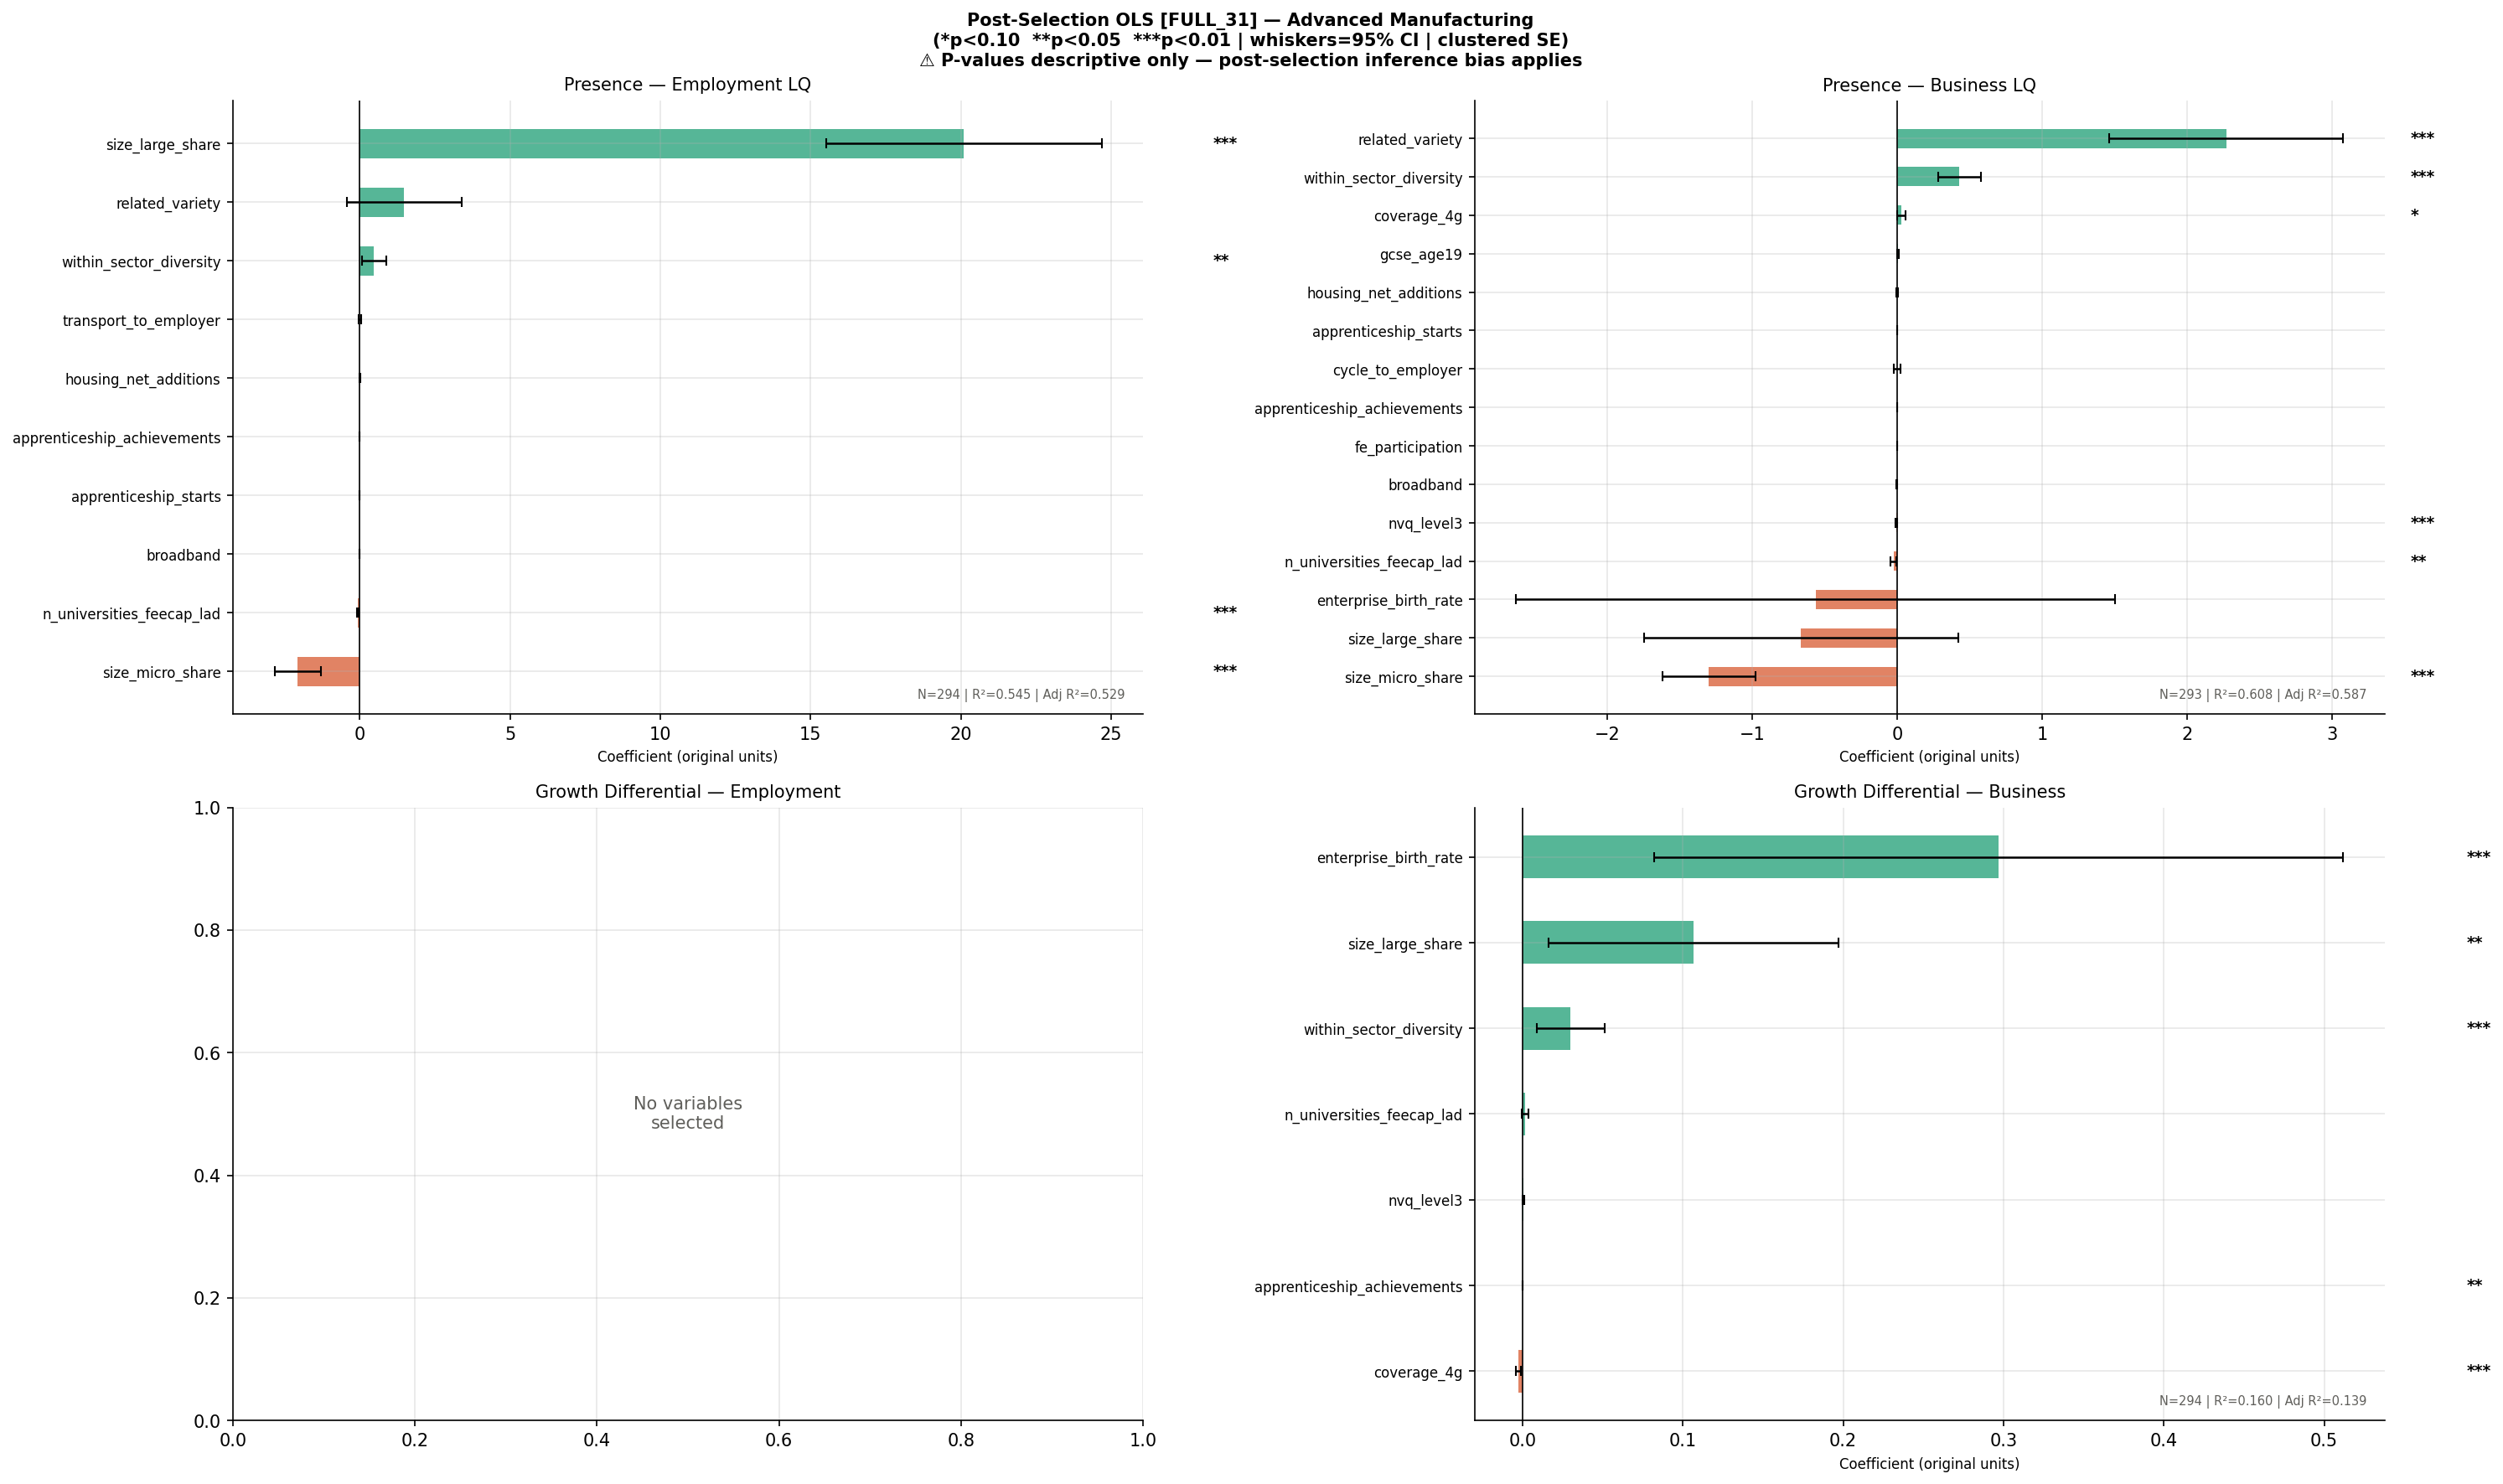

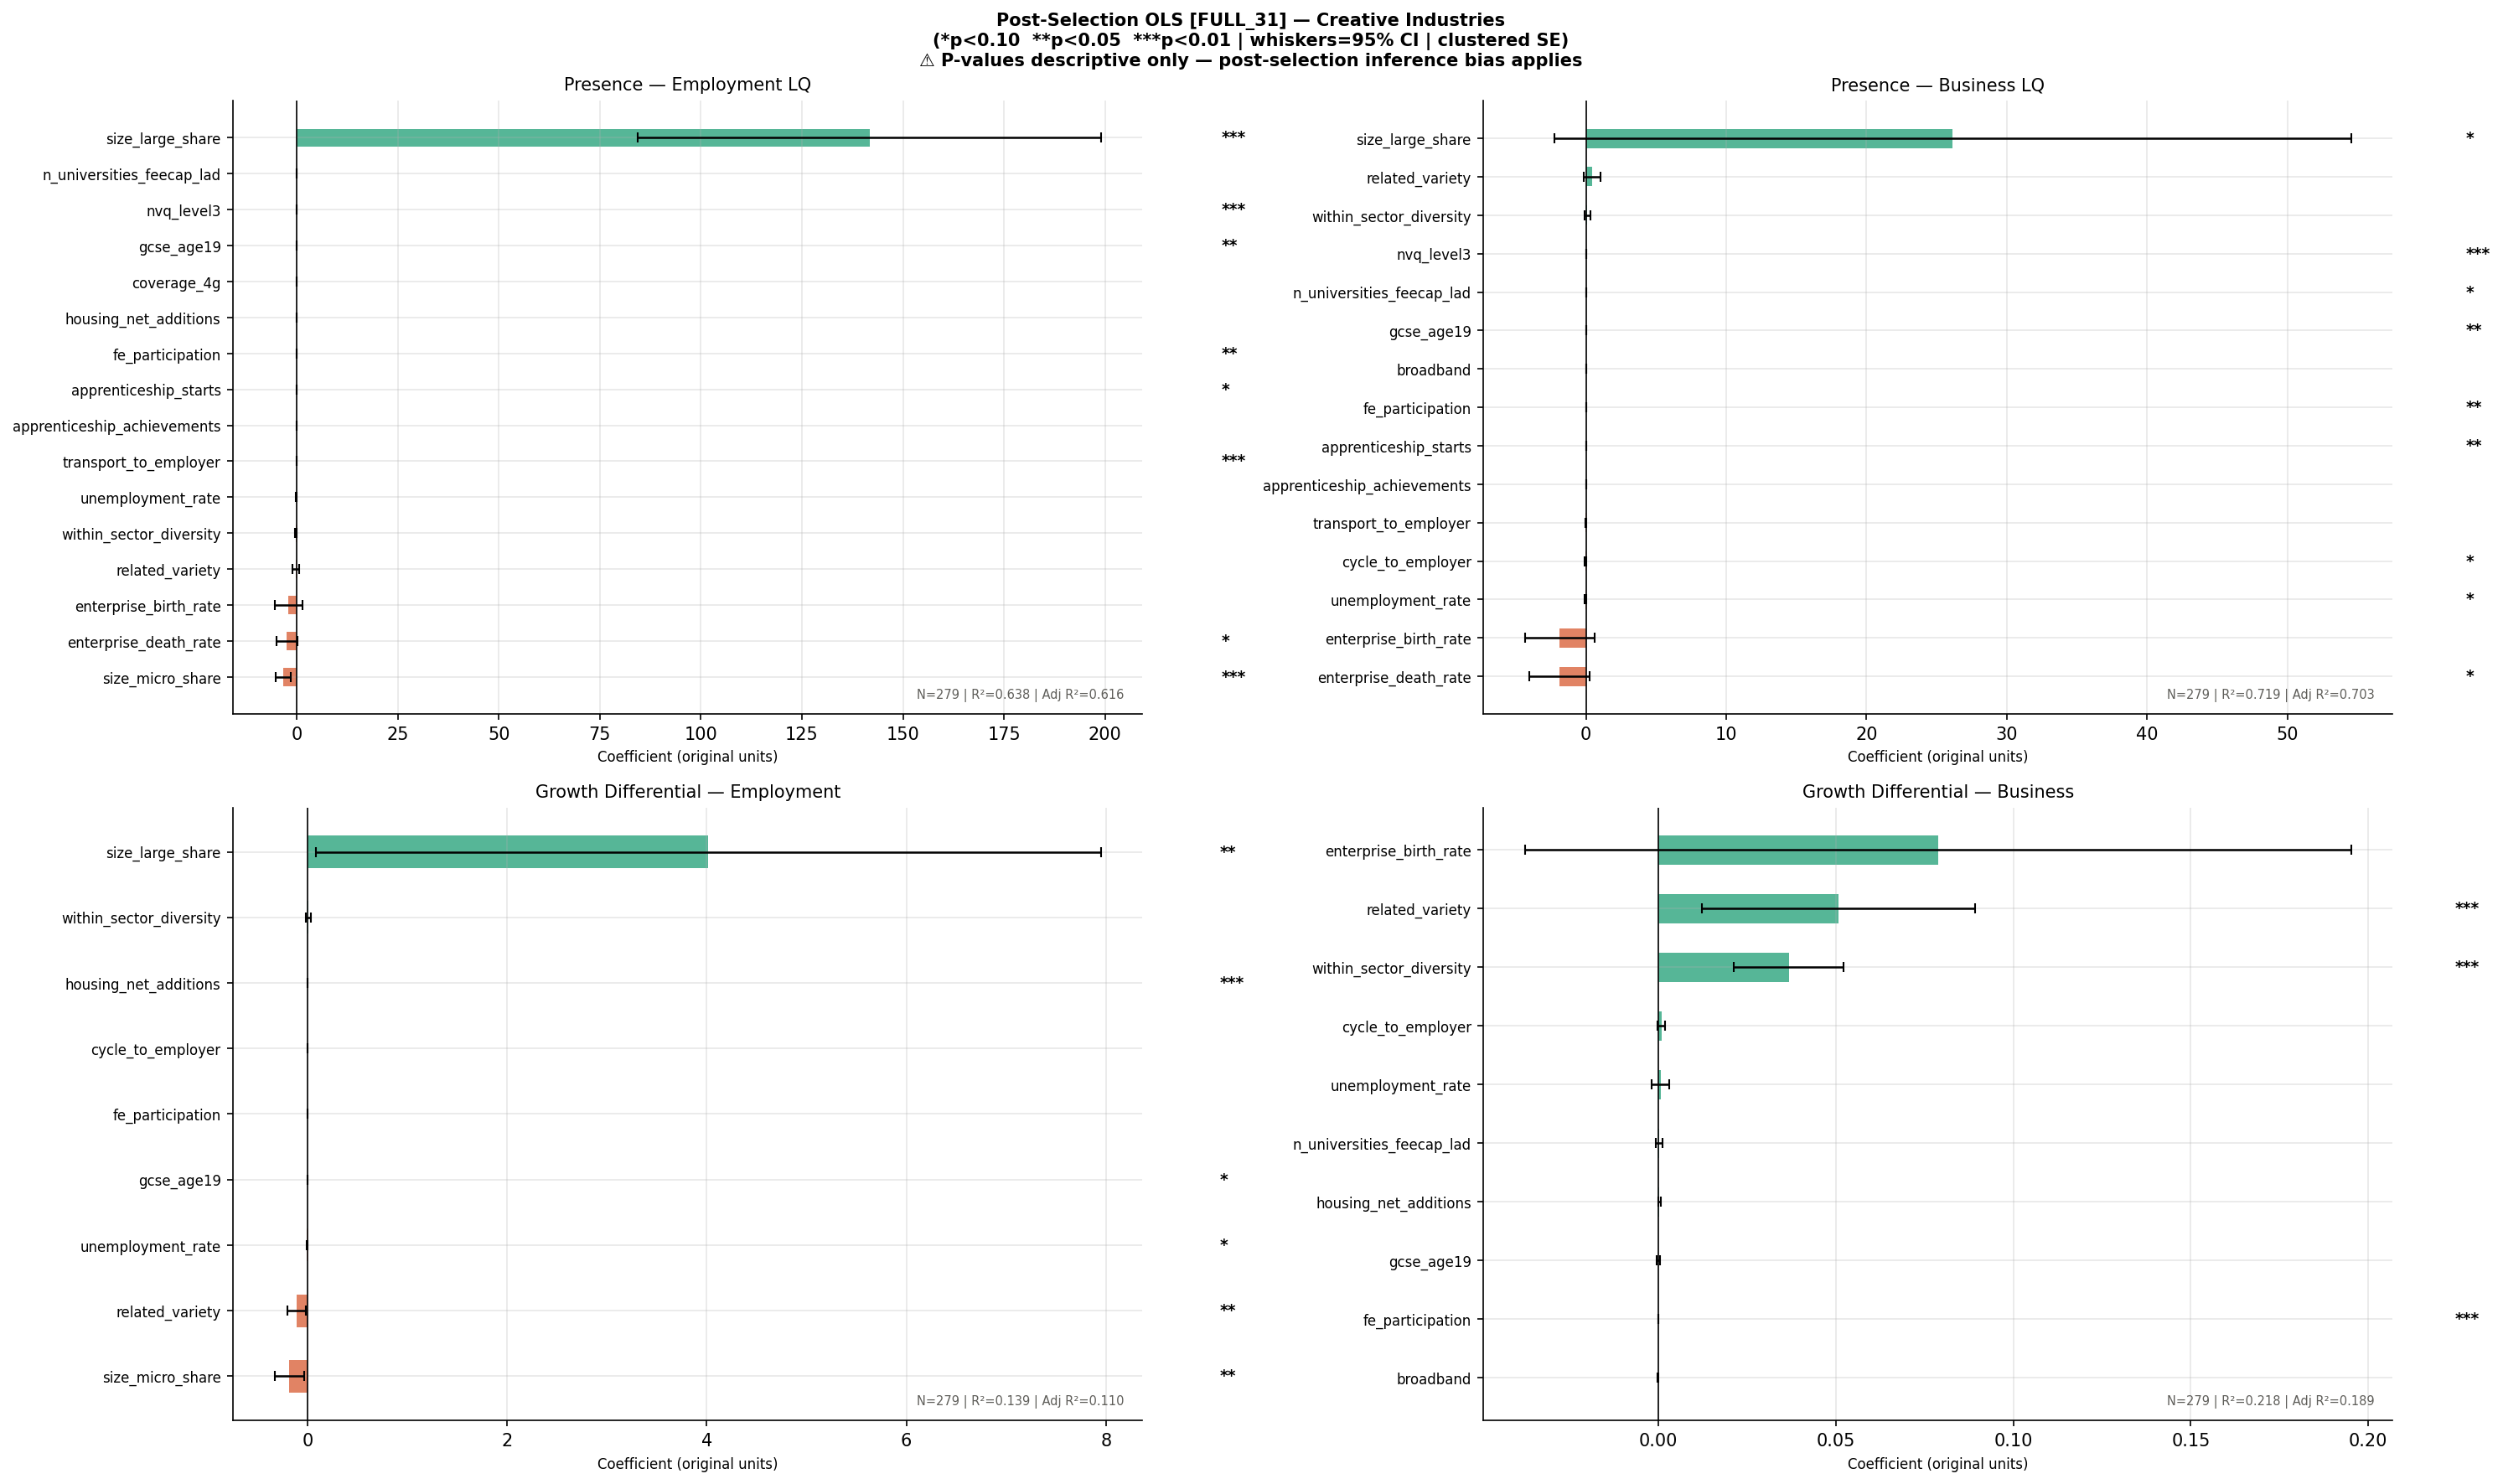

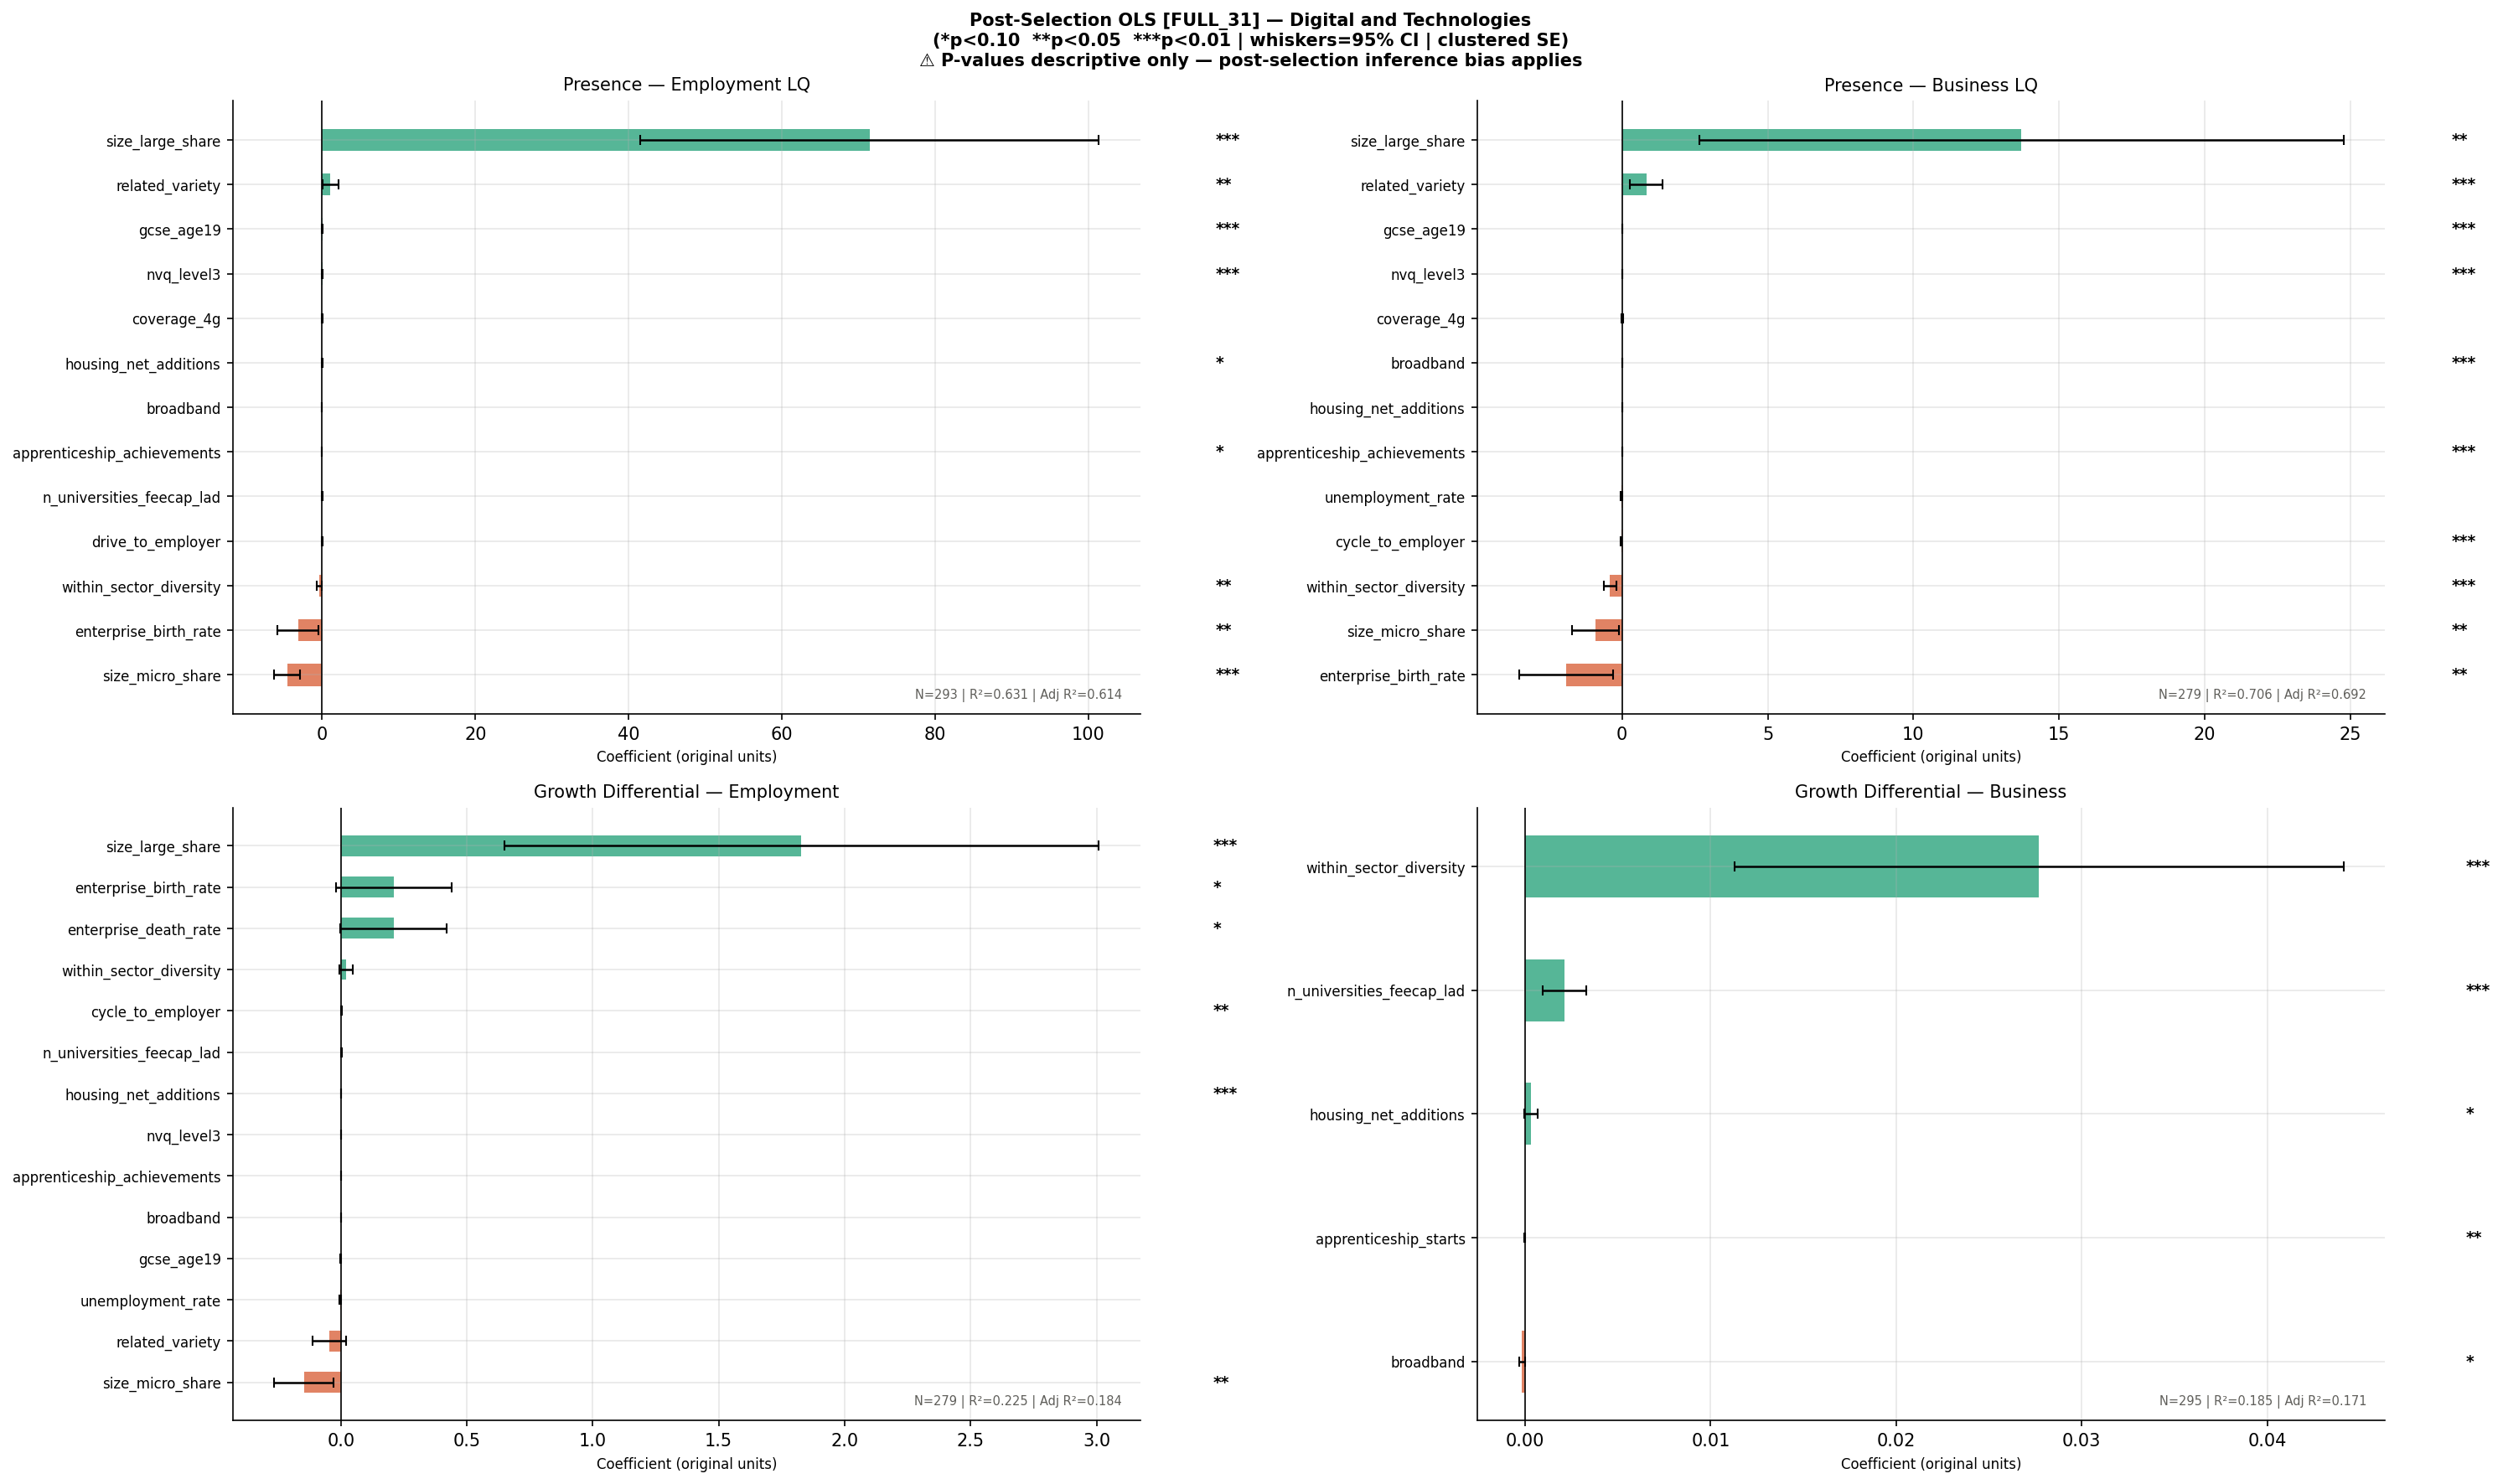

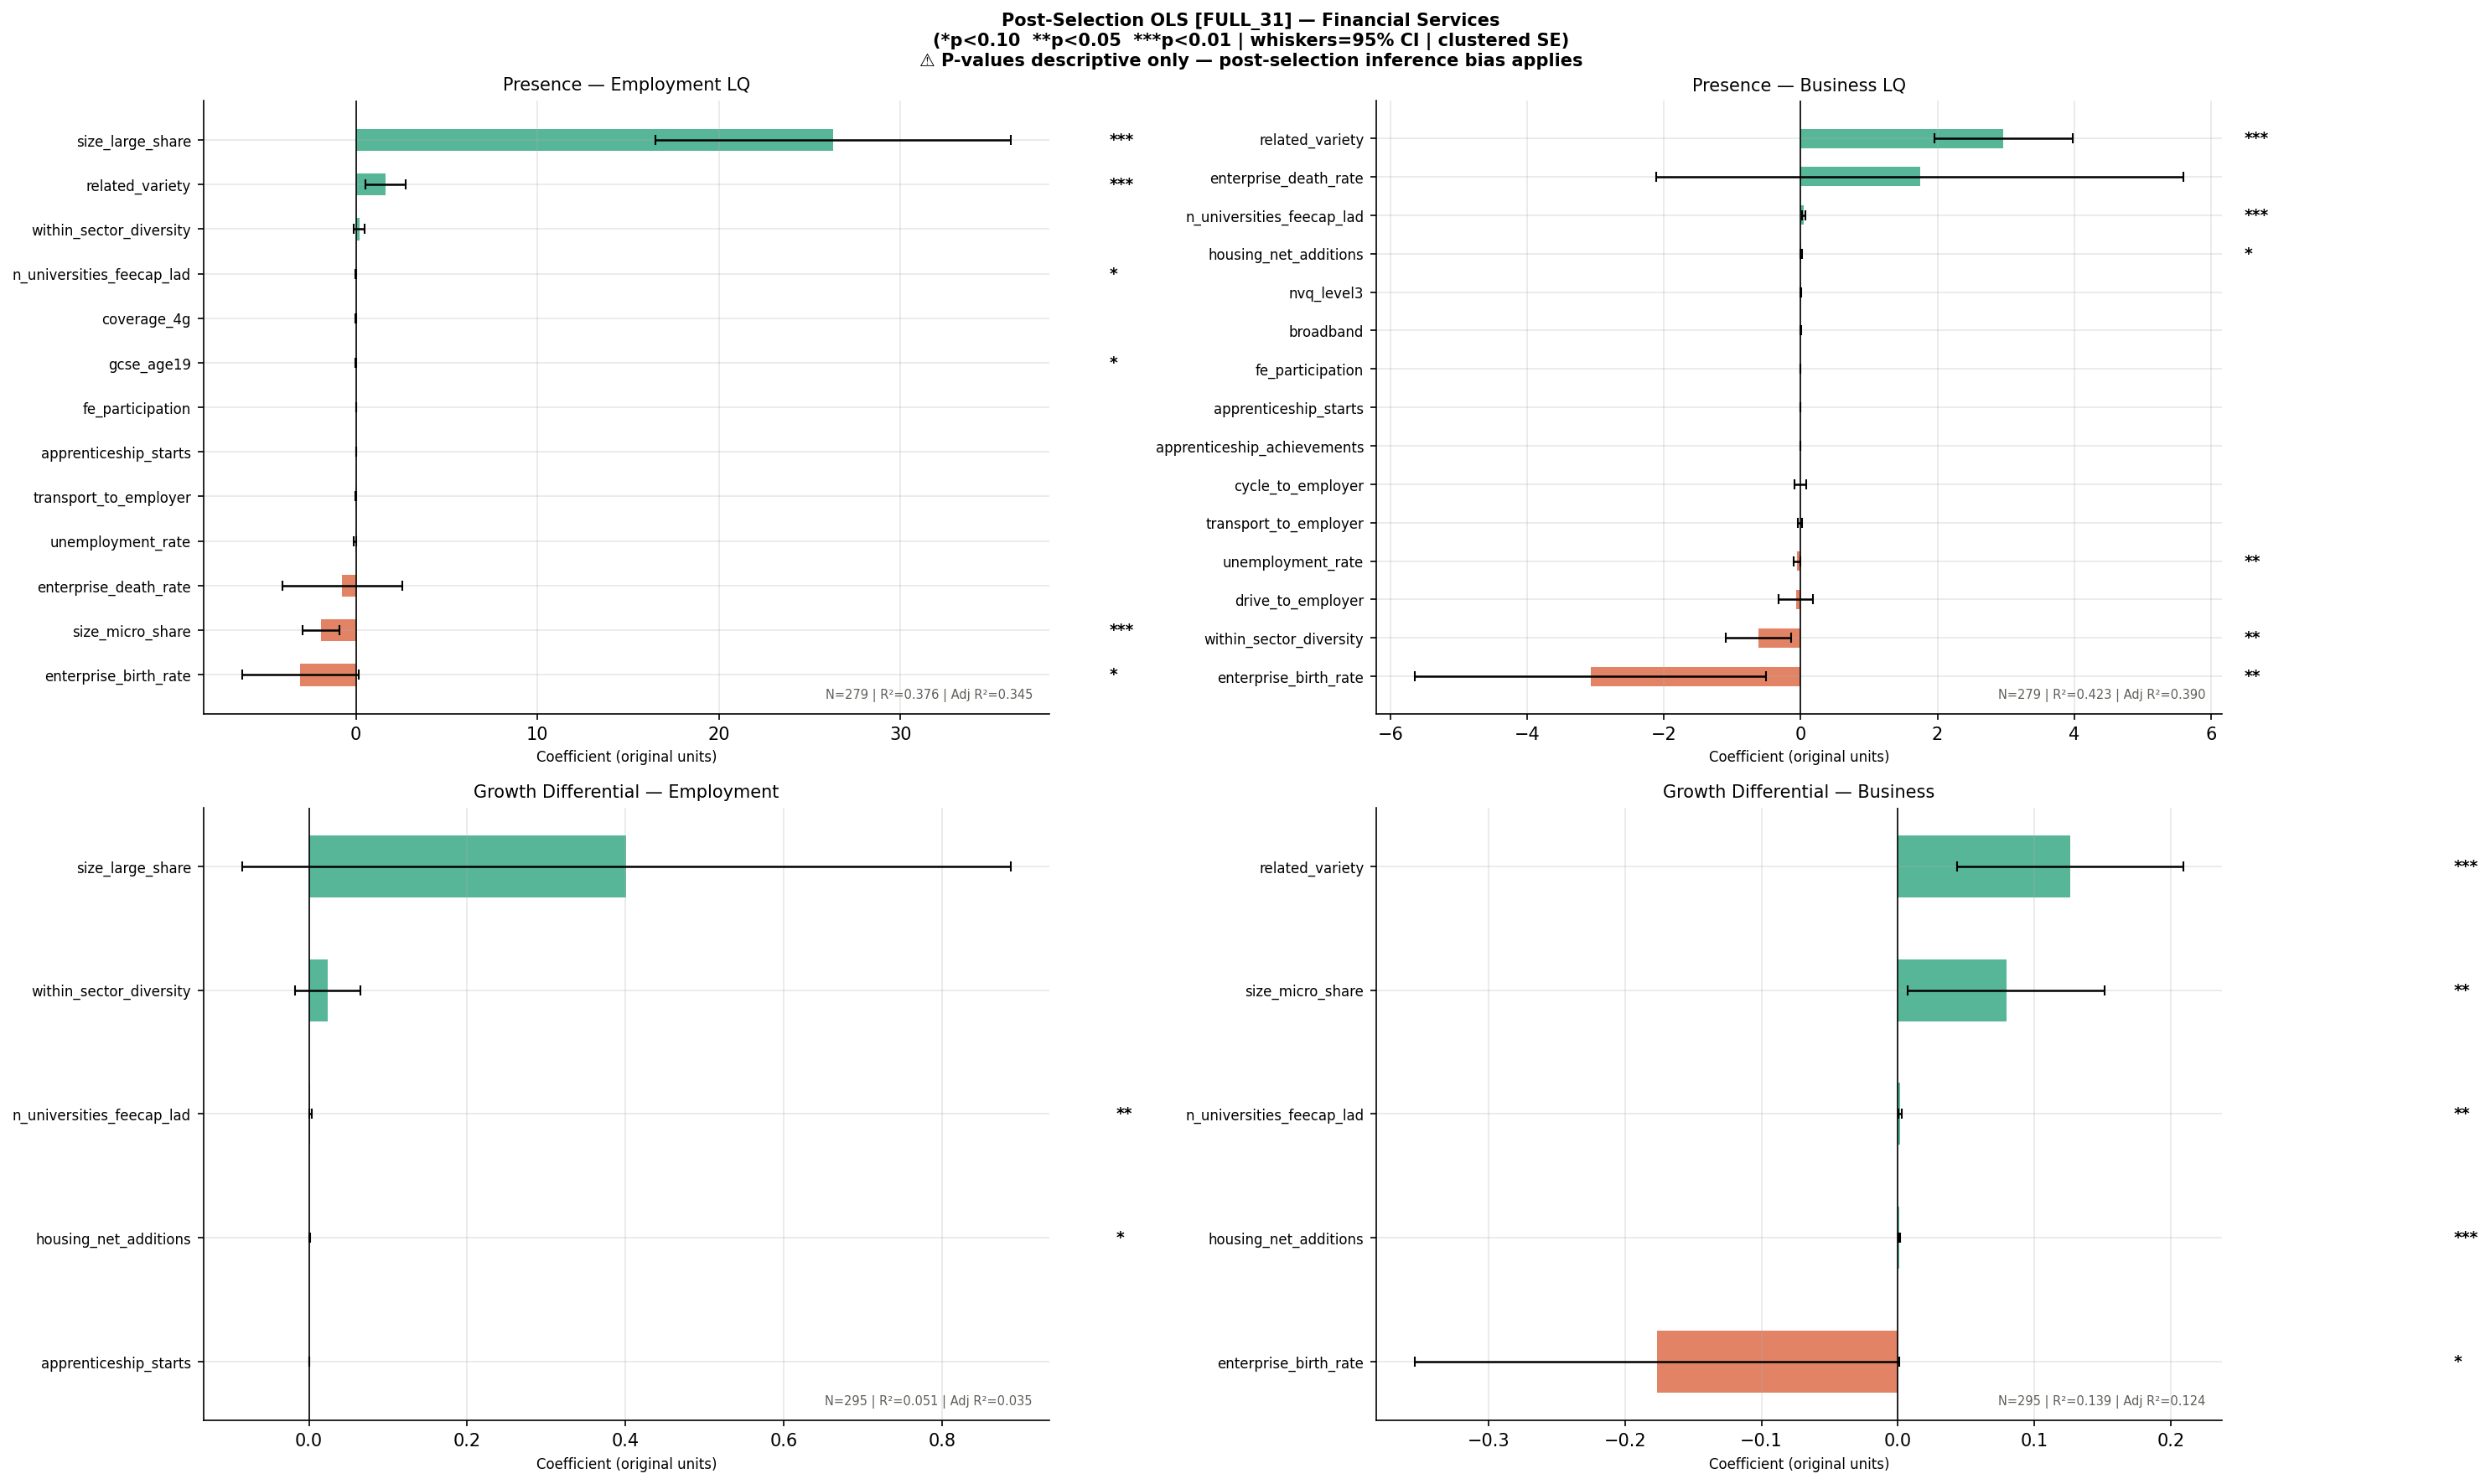

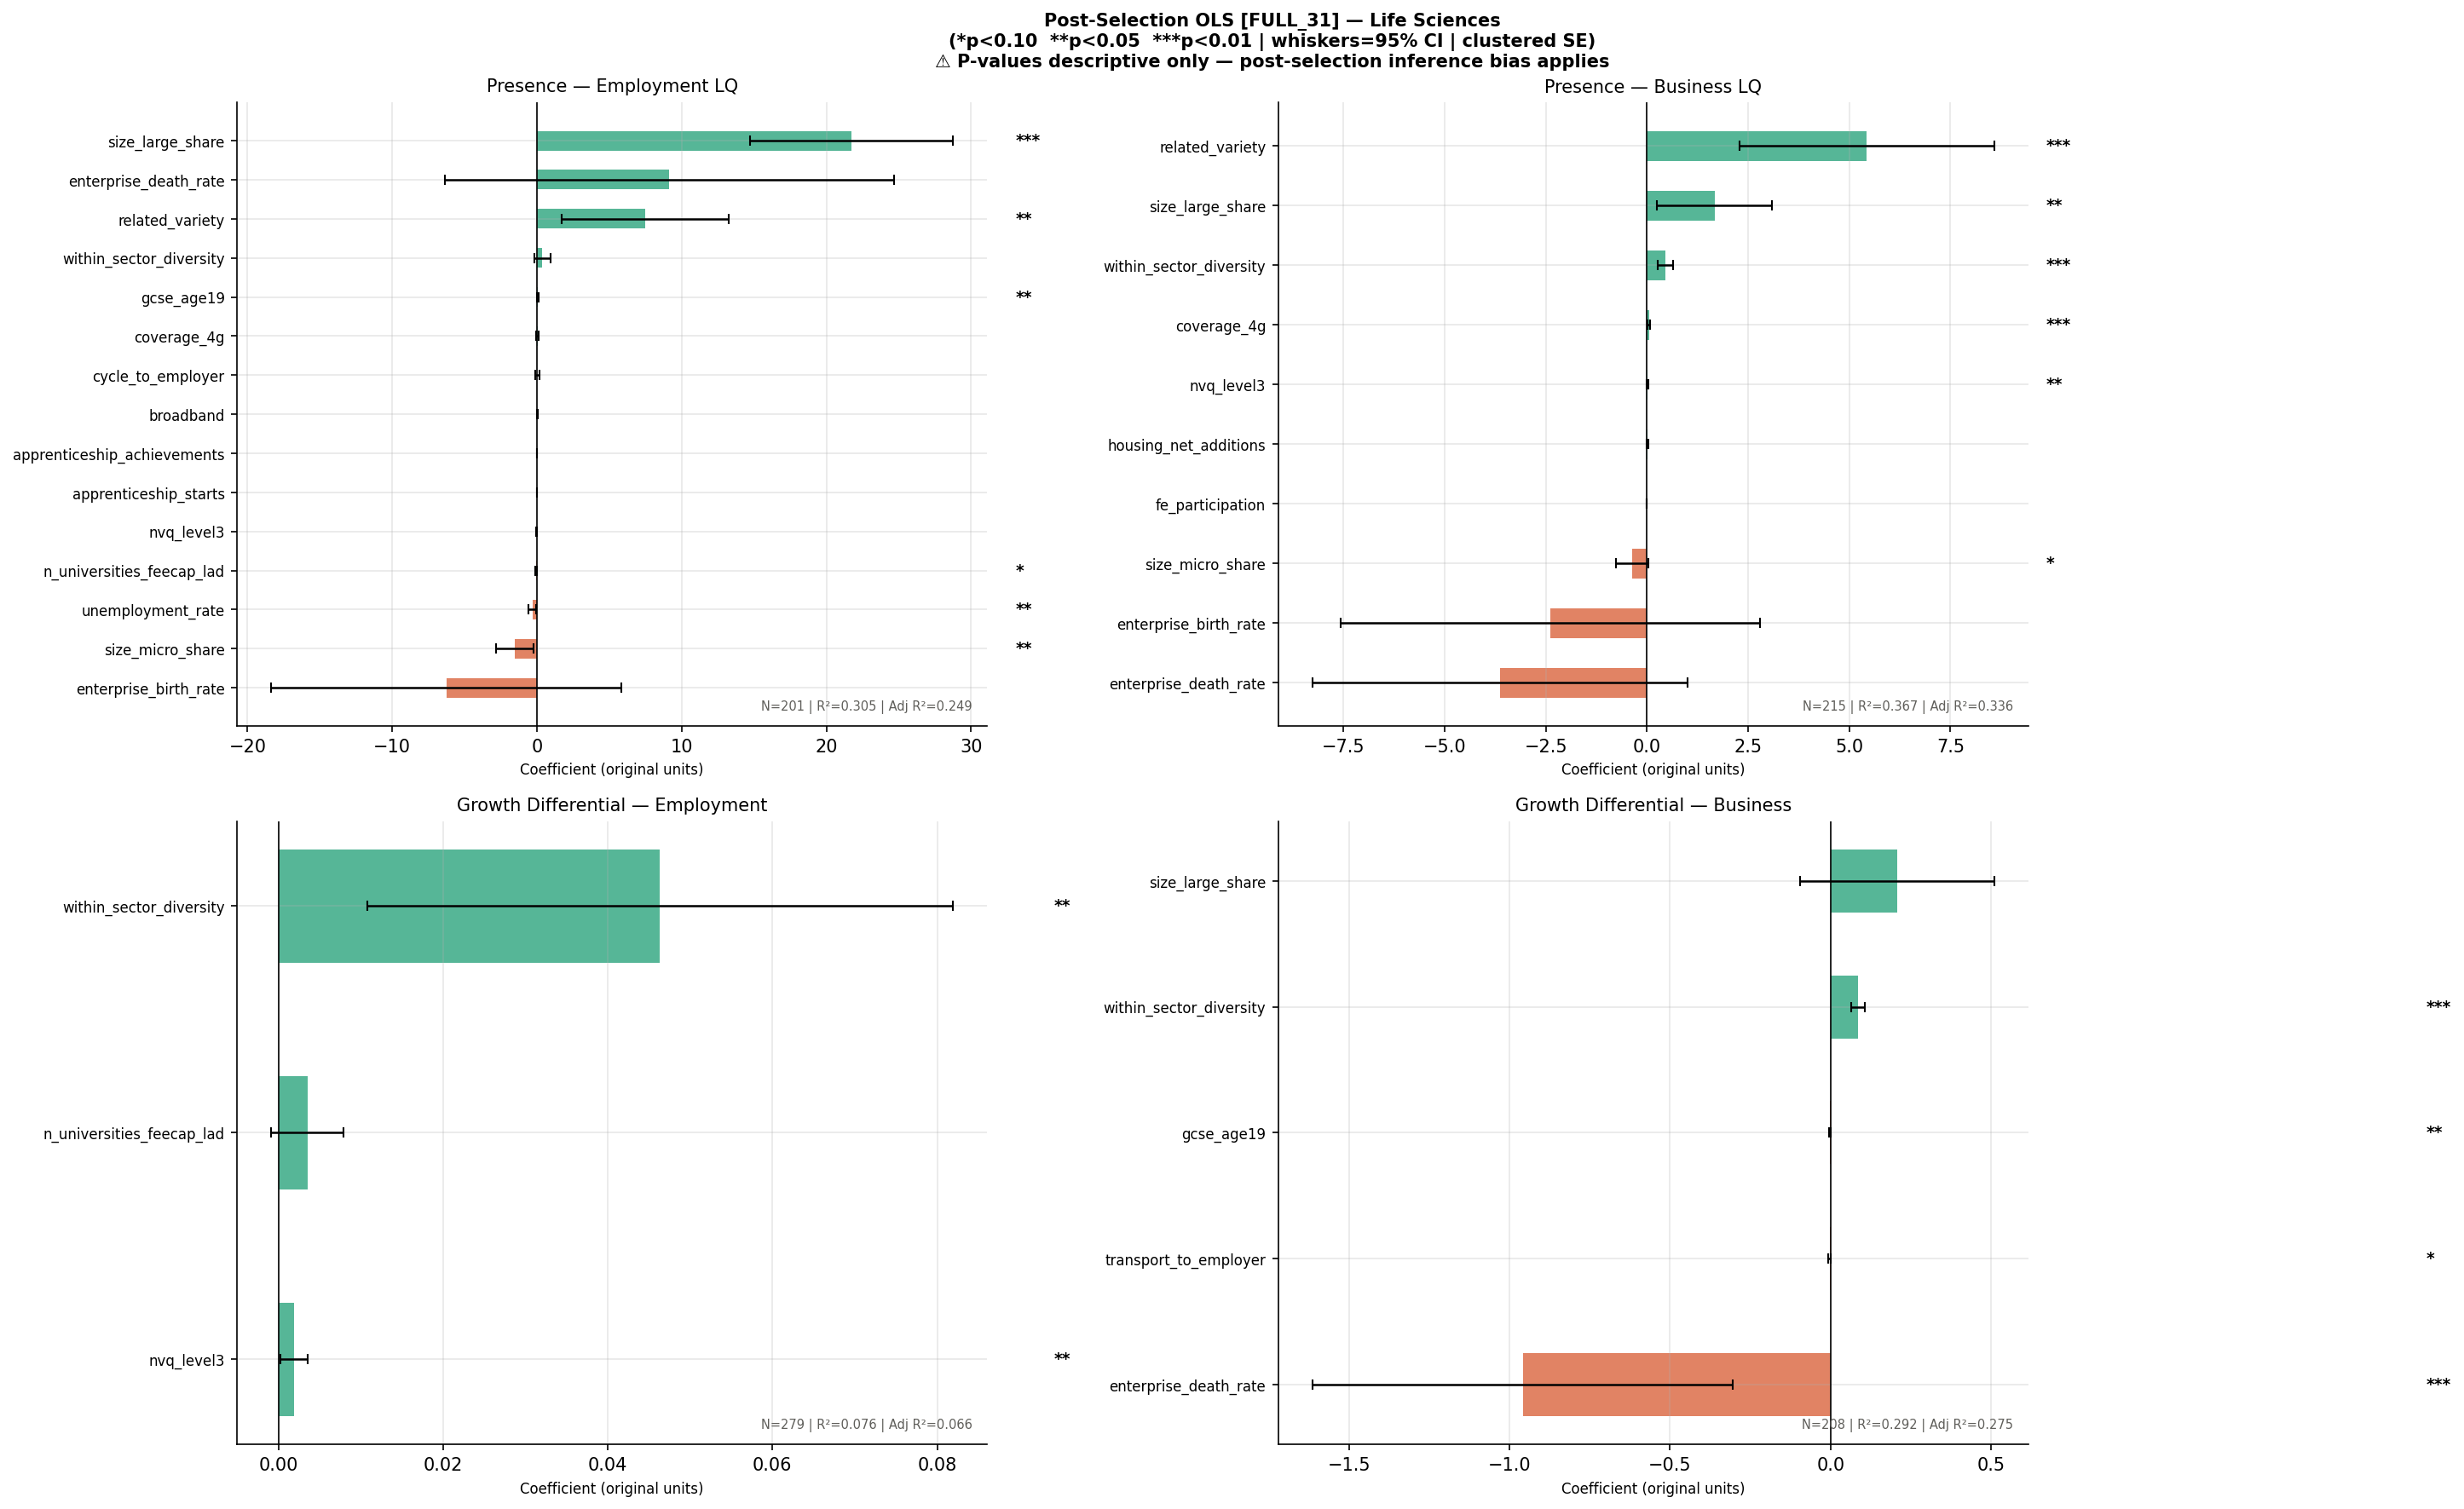

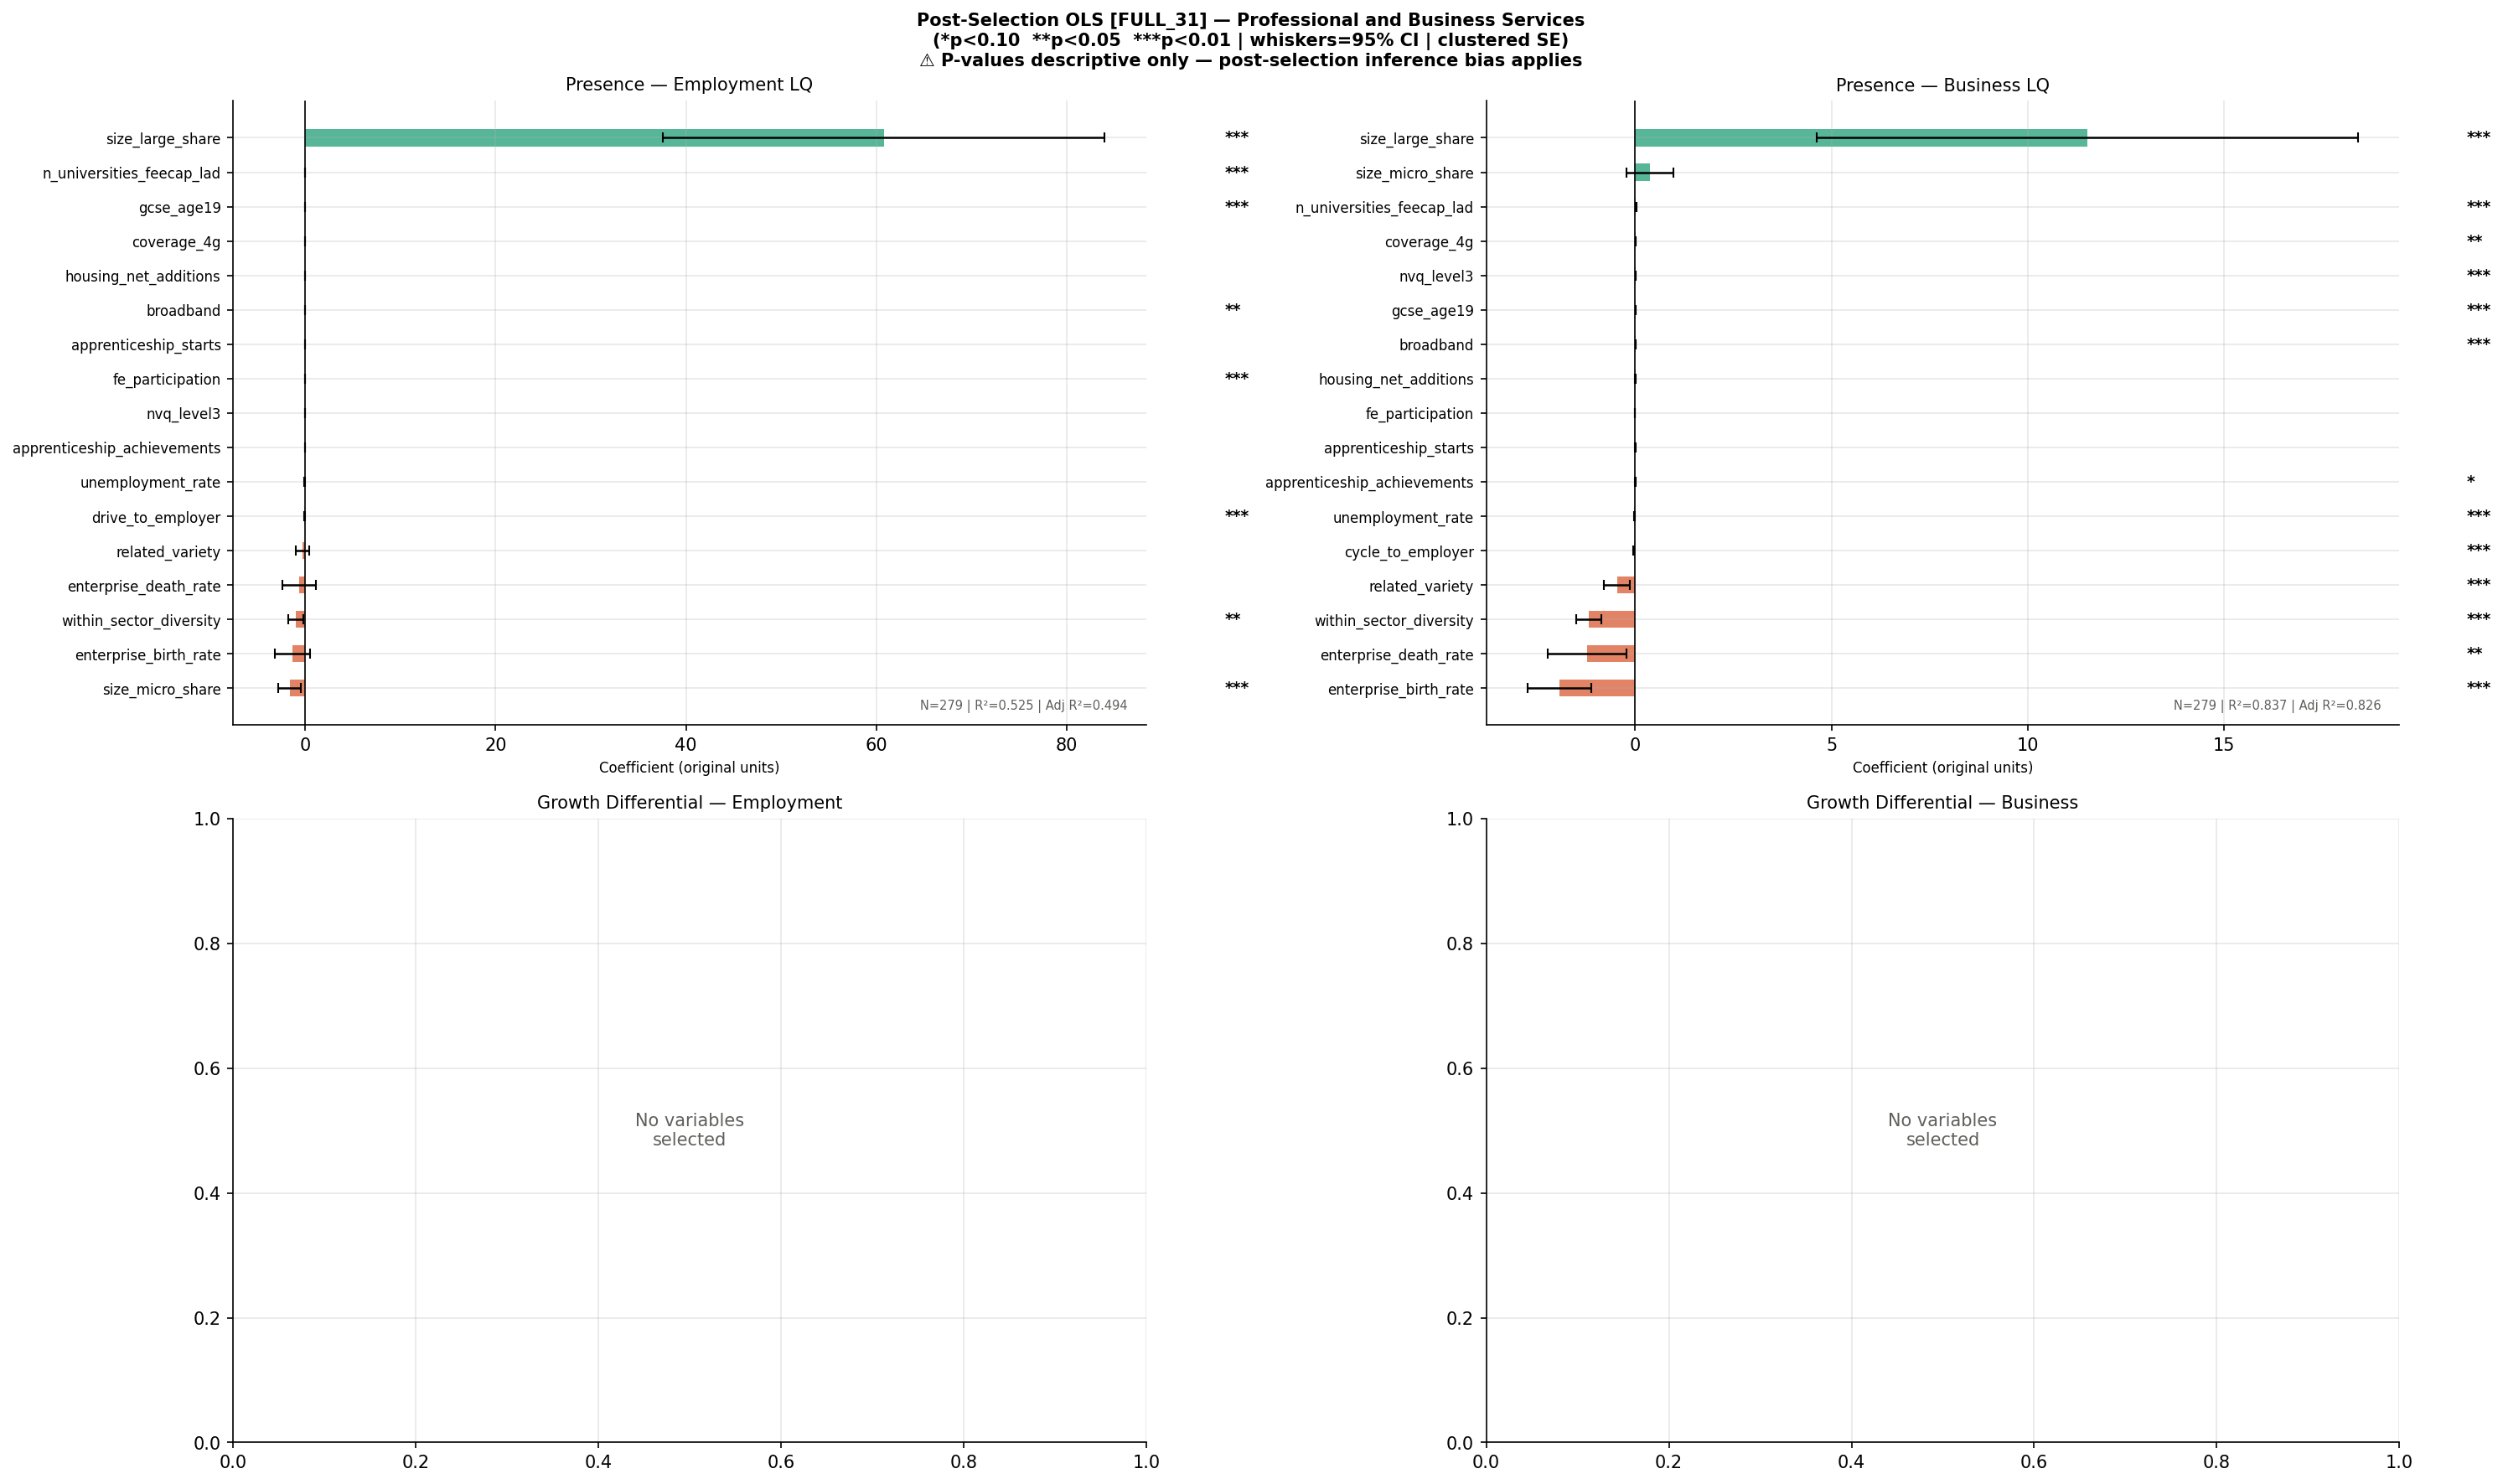

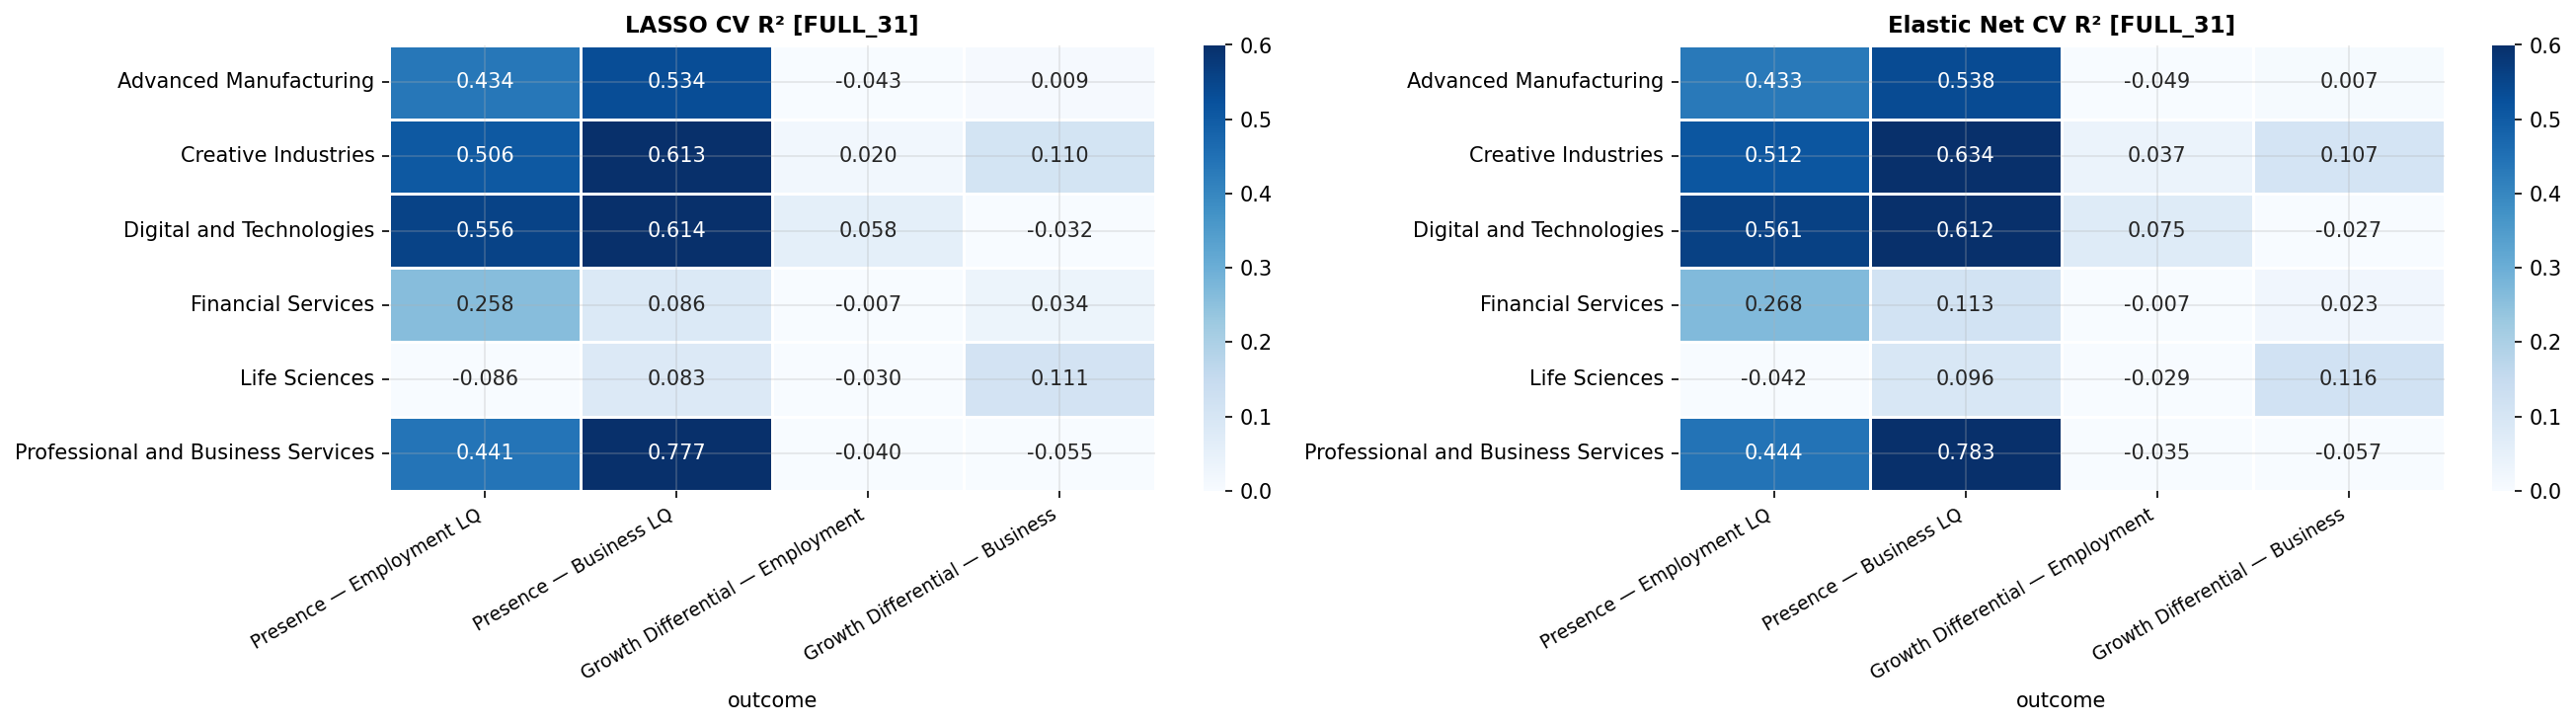

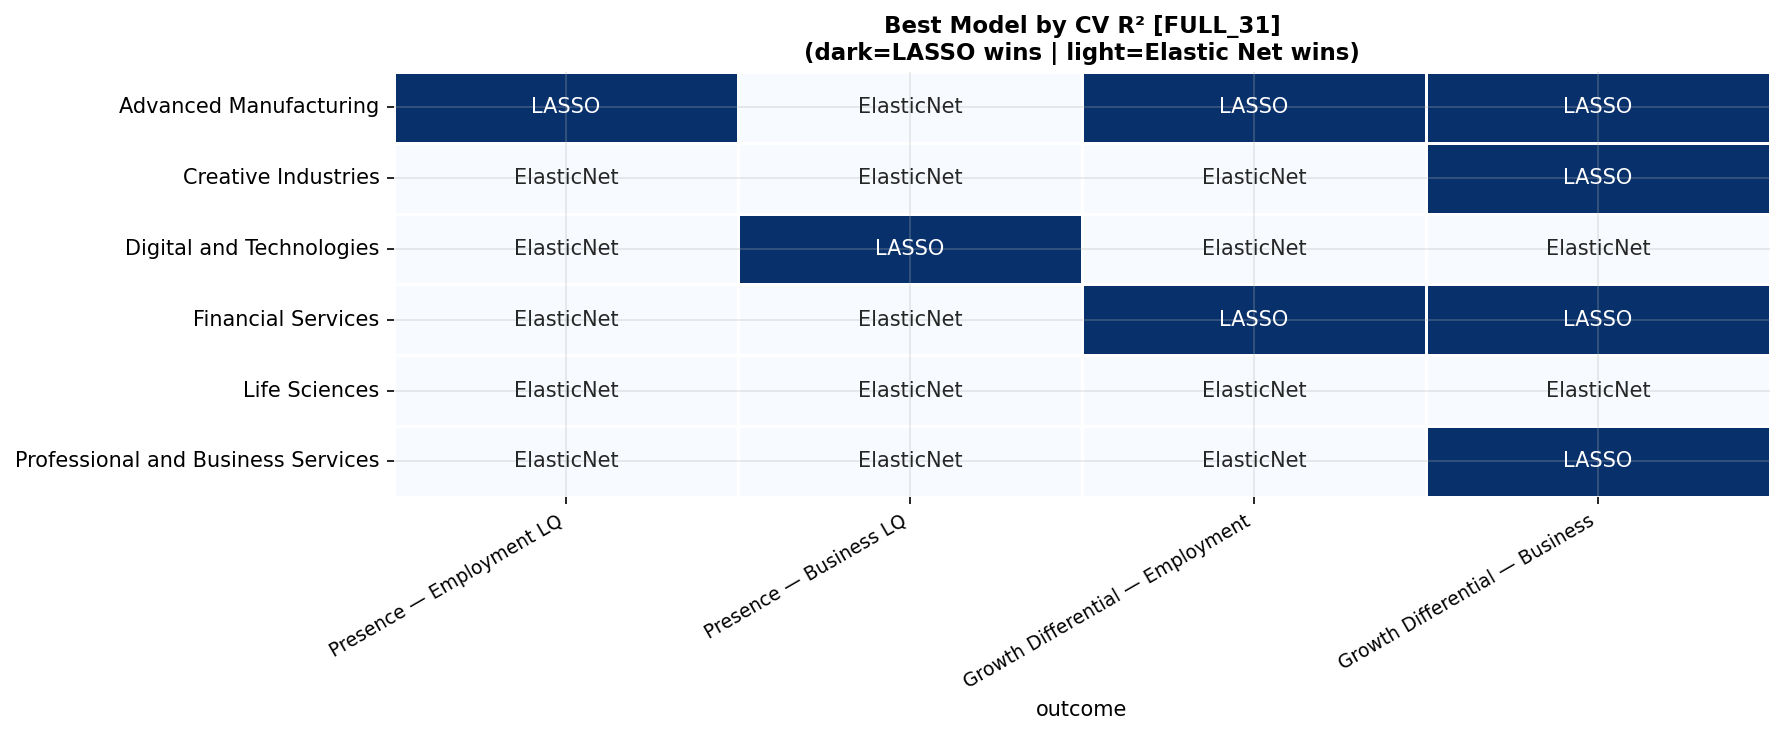

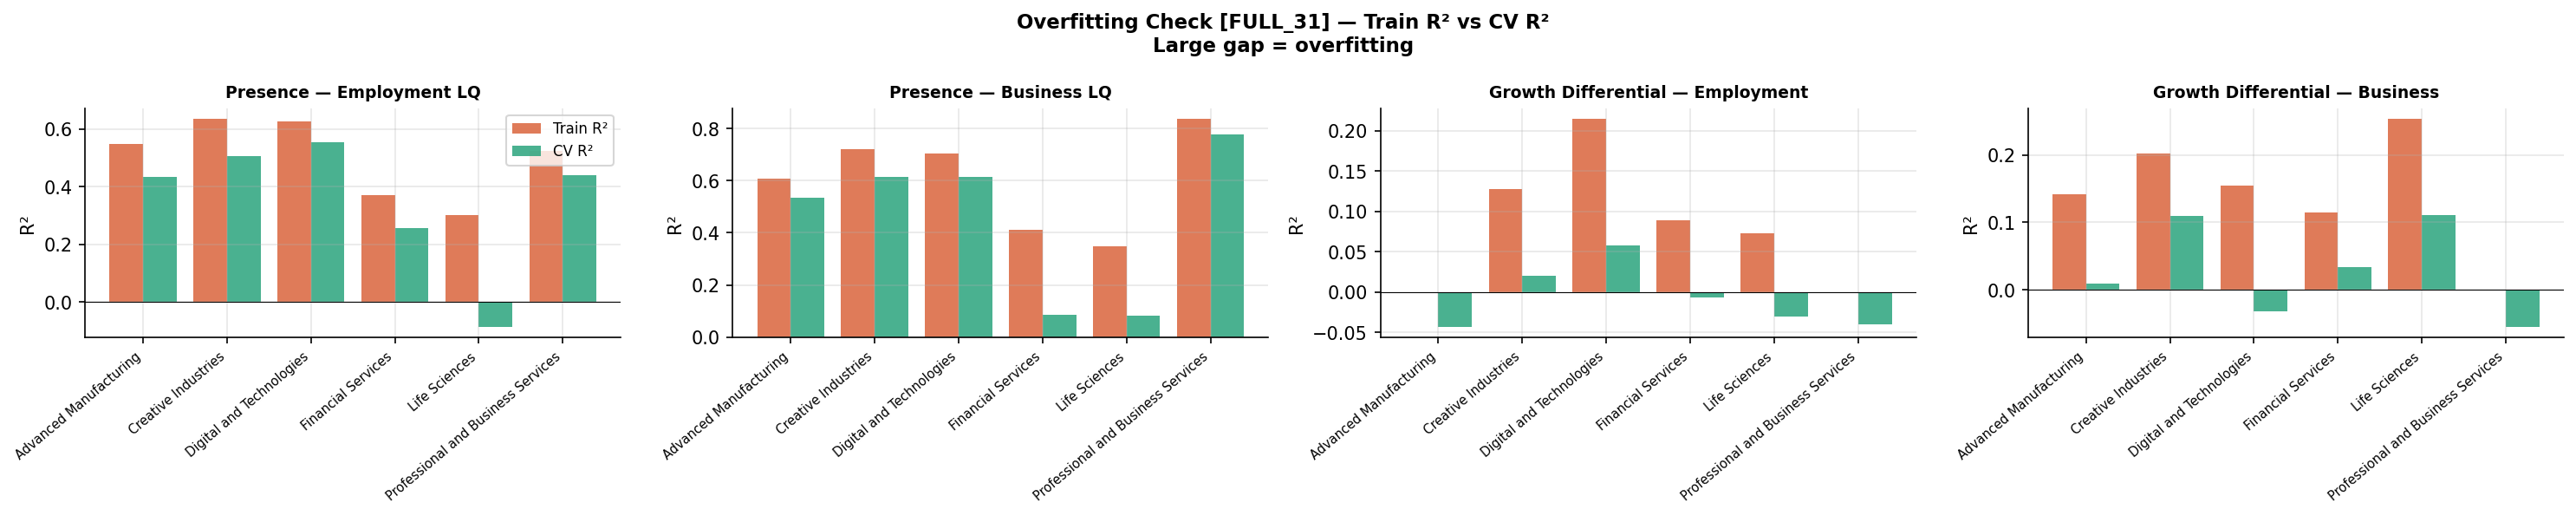


✅ [FULL_31] complete → G:\Mi unidad\Master_LSE\Git-hub\Economic_Observatory\output\Diane_final_version\lasso_full

✅ All runs complete.
   SHORT → G:\Mi unidad\Master_LSE\Git-hub\Economic_Observatory\output\Diane_final_version\lasso_short
   FULL  → G:\Mi unidad\Master_LSE\Git-hub\Economic_Observatory\output\Diane_final_version\lasso_full


In [34]:
# ============================================================
# CELL 6 — MAIN RUN LOOP
# Changes vs previous version:
#   - Prints n per run so null rate impact is visible
#   - sector filter uses SECTORS list (Defence already excluded)
# ============================================================

def run_spec(predictors, spec_label, out_dir):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    print(f"\n{'='*65}")
    print(f"SPEC: {spec_label} ({len(predictors)} predictors)")
    print(f"{'='*65}")

    all_models = {}
    all_ols    = {}
    rows_lasso = []
    rows_ols   = []

    for sector in SECTORS:
        s_df = df_cs[df_cs["is8_sector"] == sector].copy()
        n_sector = len(s_df)
        print(f"\n── {sector} (n={n_sector}) ──")

        for y_col, outcome_label in OUTCOMES.items():
            r = run_lasso_enet(s_df, y_col, predictors,
                               sector, outcome_label)
            if r is None:
                print(f"  SKIP {y_col}: n<30 or zero variance")
                continue

            all_models[(sector, y_col)] = r
            rows_lasso.append({
                "spec":              spec_label,
                "sector":            sector,
                "outcome":           y_col,
                "outcome_label":     outcome_label,
                "n":                 r["n"],
                "lasso_lambda":      r["lasso_lambda"],
                "lasso_n_vars":      r["lasso_n_vars"],
                "lasso_cv_r2":       r["lasso_cv_r2"],
                "lasso_cv_r2_std":   r["lasso_cv_r2_std"],
                "lasso_cv_rmse":     r["lasso_cv_rmse"],
                "lasso_cv_mae":      r["lasso_cv_mae"],
                "lasso_rmse_raw":    r.get("lasso_rmse_raw", np.nan),
                "lasso_r2_train":    r["lasso_r2_train"],
                "lasso_quality":     quality_label(r["lasso_cv_r2"]),
                "enet_lambda":       r["enet_lambda"],
                "enet_l1_ratio":     r["enet_l1_ratio"],
                "enet_n_vars":       r["enet_n_vars"],
                "enet_cv_r2":        r["enet_cv_r2"],
                "enet_cv_r2_std":    r["enet_cv_r2_std"],
                "enet_cv_rmse":      r["enet_cv_rmse"],
                "enet_cv_mae":       r["enet_cv_mae"],
                "enet_rmse_raw":     r.get("enet_rmse_raw", np.nan),
                "enet_r2_train":     r["enet_r2_train"],
                "enet_quality":      quality_label(r["enet_cv_r2"]),
                "best_model":        r["best_model"],
                "best_cv_r2":        r["best_cv_r2"],
                "overfit_gap_lasso": round(
                    r["lasso_r2_train"] - r["lasso_cv_r2"], 3),
            })

            print(f"  {y_col:10} n={r['n']:3d} | "
                  f"LASSO R²={r['lasso_cv_r2']:.3f} "
                  f"[{quality_label(r['lasso_cv_r2'])}] | "
                  f"ENet R²={r['enet_cv_r2']:.3f} | "
                  f"Best={r['best_model']}")

            sel_vars = r["results"][
                r["results"]["selected_both"]
            ]["variable"].tolist()

            ols = run_post_ols(s_df, y_col, sel_vars,
                               sector, outcome_label)
            if ols:
                all_ols[(sector, y_col)] = ols
                rows_ols.append({
                    "spec":    spec_label,
                    "sector":  sector,
                    "outcome": y_col,
                    "n":       ols["n"],
                    "r2":      ols["r2"],
                    "r2_adj":  ols["r2_adj"],
                    "n_sig":   ols["n_sig"],
                    "n_vars":  len(sel_vars),
                })

    lasso_df = pd.DataFrame(rows_lasso)
    ols_df   = pd.DataFrame(rows_ols)

    lasso_df.to_csv(
        out_dir / f"lasso_metrics_{spec_label}_fv.csv",
        index=False)
    ols_df.to_csv(
        out_dir / f"ols_summary_{spec_label}_fv.csv",
        index=False)

    ols_rows = []
    for (sec, y_col), o in all_ols.items():
        rr = o["results"].copy()
        rr["sector"]  = sec
        rr["outcome"] = y_col
        rr["n"]       = o["n"]
        rr["r2"]      = o["r2"]
        ols_rows.append(rr)
    if ols_rows:
        pd.concat(ols_rows, ignore_index=True).to_csv(
            out_dir / f"ols_coefficients_{spec_label}_fv.csv",
            index=False)

    _plot_selection_heatmap(all_models, predictors,
                            spec_label, out_dir)
    _plot_lasso_coefs(all_models, spec_label, out_dir)
    _plot_ols_coefs(all_ols, spec_label, out_dir)
    _plot_cv_r2_heatmap(lasso_df, spec_label, out_dir)
    _plot_best_model(lasso_df, spec_label, out_dir)
    _plot_overfit_check(lasso_df, spec_label, out_dir)

    print(f"\n✅ [{spec_label}] complete → {out_dir}")
    return all_models, all_ols, lasso_df, ols_df


# ── RUN BOTH SPECS ────────────────────────────────────────────
models_short, ols_short, metrics_short, ols_sum_short = run_spec(
    predictors=PREDICTORS_SHORT,
    spec_label="SHORT_12",
    out_dir=OUT_SHORT,
)

models_full, ols_full, metrics_full, ols_sum_full = run_spec(
    predictors=PREDICTORS_FULL,
    spec_label="FULL_31",
    out_dir=OUT_FULL,
)

print("\n✅ All runs complete.")
print(f"   SHORT → {OUT_SHORT}")
print(f"   FULL  → {OUT_FULL}")

In [35]:
# ============================================================
# CELL 7 — SHORT vs FULL COMPARISON + RF TEMPLATE
# Unchanged from previous version
# ============================================================

comp = metrics_short[[
    "sector", "outcome",
    "lasso_cv_r2", "lasso_cv_rmse", "lasso_n_vars",
    "enet_cv_r2",  "enet_cv_rmse",  "enet_n_vars",
    "best_model",  "best_cv_r2",    "n",
]].merge(
    metrics_full[[
        "sector", "outcome",
        "lasso_cv_r2", "lasso_cv_rmse",
        "enet_cv_r2",  "enet_cv_rmse",
        "best_model",  "best_cv_r2",
    ]],
    on=["sector", "outcome"],
    suffixes=("_short", "_full"),
    how="outer"
)

comp["r2_gain_full_vs_short"] = (
    comp["best_cv_r2_full"] - comp["best_cv_r2_short"]
).round(3)

comp["recommended_spec"] = np.where(
    comp["r2_gain_full_vs_short"] > 0.02,
    "FULL_31", "SHORT_12"
)

comp["quality_short"] = comp["best_cv_r2_short"].apply(quality_label)
comp["quality_full"]  = comp["best_cv_r2_full"].apply(quality_label)

print("SHORT vs FULL COMPARISON")
print(comp[[
    "sector", "outcome",
    "best_cv_r2_short", "quality_short",
    "best_cv_r2_full",  "quality_full",
    "r2_gain_full_vs_short", "recommended_spec",
]].to_string(index=False))

comp.to_csv(OUT_ROOT / "comparison_short_vs_full_fv.csv", index=False)

print("\nAverage CV R² by outcome:")
avg = comp.groupby("outcome")[
    ["best_cv_r2_short", "best_cv_r2_full"]
].mean().round(3)
print(avg.to_string())

# ── RF comparison template ────────────────────────────────────
rf_template = comp[[
    "sector", "outcome", "n",
    "best_cv_r2_short", "lasso_cv_rmse_short",
    "best_cv_r2_full",  "lasso_cv_rmse_full",
]].copy()

rf_template["rf_cv_r2"]           = np.nan
rf_template["rf_cv_rmse"]         = np.nan
rf_template["rf_cv_mae"]          = np.nan
rf_template["rf_n_features_used"] = np.nan
rf_template["best_overall"]       = np.nan

rf_template.to_csv(
    OUT_ROOT / "rf_comparison_template_fv.csv", index=False)

print(f"\n📋 RF template → {OUT_ROOT}/rf_comparison_template_fv.csv")
print("   Ask RF team to fill:")
print("   rf_cv_r2 | rf_cv_rmse | rf_cv_mae | rf_n_features_used")
print("   ⚠ RF must use SAME KFold splits for valid comparison")

def plot_rf_comparison(template_path):
    df_comp = pd.read_csv(template_path).dropna(subset=["rf_cv_r2"])
    if df_comp.empty:
        print("RF template not yet filled — skipping plot.")
        return
    df_comp["best_overall"] = df_comp[[
        "best_cv_r2_short", "best_cv_r2_full", "rf_cv_r2",
    ]].idxmax(axis=1).map({
        "best_cv_r2_short": "LASSO/ENet SHORT",
        "best_cv_r2_full":  "LASSO/ENet FULL",
        "rf_cv_r2":         "Random Forest",
    })
    df_comp.to_csv(
        OUT_ROOT / "rf_comparison_filled_fv.csv", index=False)
    labels = df_comp["sector"].str[:10] + "\n" + df_comp["outcome"]
    x, width = np.arange(len(df_comp)), 0.25
    fig, axes = plt.subplots(1, 2, figsize=(22, 7))
    ax = axes[0]
    ax.bar(x-width, df_comp["best_cv_r2_short"], width,
           label="LASSO/ENet SHORT", color=TEAL,  alpha=0.9)
    ax.bar(x,       df_comp["best_cv_r2_full"],  width,
           label="LASSO/ENet FULL",  color=TEAL,  alpha=0.5)
    ax.bar(x+width, df_comp["rf_cv_r2"],         width,
           label="Random Forest",    color=CORAL, alpha=0.9)
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=45,
                                          ha="right", fontsize=7)
    ax.set_ylabel("CV R²  (higher = better)")
    ax.set_title("CV R² Comparison", fontsize=12, fontweight="bold")
    ax.axhline(0, color="black", linewidth=0.5); ax.legend(fontsize=9)
    ax = axes[1]
    ax.bar(x-width, df_comp["lasso_cv_rmse_short"], width,
           label="LASSO/ENet SHORT", color=TEAL,  alpha=0.9)
    ax.bar(x,       df_comp["lasso_cv_rmse_full"],  width,
           label="LASSO/ENet FULL",  color=TEAL,  alpha=0.5)
    ax.bar(x+width, df_comp["rf_cv_rmse"],          width,
           label="Random Forest",    color=CORAL, alpha=0.9)
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=45,
                                          ha="right", fontsize=7)
    ax.set_ylabel("CV RMSE  (lower = better)")
    ax.set_title("CV RMSE Comparison", fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)
    plt.suptitle("LASSO / Elastic Net vs Random Forest\n"
                 "(same CV folds required for valid comparison)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(OUT_ROOT / "07_model_comparison_lasso_vs_rf_fv.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print("\nWinner by sector-outcome:")
    print(df_comp[["sector","outcome","best_overall"]].to_string(index=False))
    print("\nOverall win count:")
    print(df_comp["best_overall"].value_counts())

plot_rf_comparison(OUT_ROOT / "rf_comparison_template_fv.csv")
print("\n✅ Cell 7 complete.")

SHORT vs FULL COMPARISON
                            sector outcome  best_cv_r2_short   quality_short  best_cv_r2_full    quality_full  r2_gain_full_vs_short recommended_spec
            Advanced Manufacturing  gd_bus            -0.009 Not recommended            0.009 Not recommended                  0.018         SHORT_12
            Advanced Manufacturing  gd_emp            -0.055 Not recommended           -0.043 Not recommended                  0.012         SHORT_12
            Advanced Manufacturing  lq_bus             0.366            Good            0.538            Good                  0.172          FULL_31
            Advanced Manufacturing  lq_emp             0.057 Not recommended            0.434            Good                  0.377          FULL_31
               Creative Industries  gd_bus             0.068 Not recommended            0.110        Marginal                  0.042          FULL_31
               Creative Industries  gd_emp            -0.010 Not recommende

In [36]:
# ============================================================
# CELL 8 — FORMATTED EXCEL REPORT
# Changes vs previous version:
#   - VAR_META updated with correct column names
#   - Enterprise rates added (birth/death/high_growth)
#   - OUT_ROOT uses correct path
# ============================================================

from openpyxl import Workbook
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
from openpyxl.utils import get_column_letter

OUT_ROOT = Path(r"G:\Mi unidad\Master_LSE\Git-hub\Economic_Observatory\output\Diane_final_version")
OUT_ROOT.mkdir(parents=True, exist_ok=True)

# ============================================================
# VARIABLE METADATA — corrected column names
# ============================================================
VAR_META = {
    # ── Human Capital ─────────────────────────────────────────
    "nvq_level3": {
        "group": "Human Capital",
        "definition": "Share of working-age residents holding qualifications at NVQ Level 3 or above (A-level equivalent or higher).",
    },
    "gcse_age19": {
        "group": "Human Capital",
        "definition": "Share of young people achieving a standard pass (grade 4+) in English and Maths GCSEs by age 19.",
    },
    "apprenticeship_starts": {
        "group": "Human Capital",
        "definition": "Number of apprenticeship starts in the area per period.",
    },
    "apprenticeship_achievements": {
        "group": "Human Capital",
        "definition": "Number of apprenticeships successfully completed in the area.",
    },
    "fe_participation": {
        "group": "Human Capital",
        "definition": "Total number of further education and skills participation enrolments in the area.",
    },
    # ── Entrepreneurial Discovery — rates ────────────────────
    "enterprise_birth_rate": {
        "group": "Entrepreneurial Discovery",
        "definition": "Enterprise births as a share of active enterprises — measures new firm entry rate. Normalised by active stock to remove LAD size effect.",
    },
    "enterprise_death_rate": {
        "group": "Entrepreneurial Discovery",
        "definition": "Enterprise deaths as a share of active enterprises — measures firm exit rate (creative destruction or ecosystem fragility).",
    },
    "enterprise_high_growth_rate": {
        "group": "Entrepreneurial Discovery",
        "definition": "High-growth enterprises (>20% annualised growth over 3 years) as a share of active enterprises — measures scaling intensity.",
    },
    # ── Connectivity ─────────────────────────────────────────
    "broadband": {
        "group": "Connectivity",
        "definition": "Share of premises in the area with access to superfast broadband (≥30 Mbit/s).",
    },
    "coverage_4g": {
        "group": "Connectivity",
        "definition": "Share of the geographic area with 4G mobile coverage from at least one operator. Note: near-constant across LADs (mean 99.5%).",
    },
    "transport_to_employer": {
        "group": "Connectivity",
        "definition": "Average journey time in minutes to nearest employment centre by public transport. DfT 2019 data — temporally stale.",
    },
    "drive_to_employer": {
        "group": "Connectivity",
        "definition": "Average journey time in minutes to nearest employment centre by car. DfT 2019 data — temporally stale.",
    },
    "cycle_to_employer": {
        "group": "Connectivity",
        "definition": "Average journey time in minutes to nearest employment centre by bicycle. DfT 2019 data — temporally stale.",
    },
    # ── Place Conditions ──────────────────────────────────────
    "housing_net_additions": {
        "group": "Place Conditions",
        "definition": "Net annual additions to the local housing stock (new builds minus demolitions/conversions).",
    },
    "size_large_share": {
        "group": "Place Conditions",
        "definition": "Share of enterprises in the area with 250 or more employees. Mean 0.004 — large firms are rare; low variance.",
    },
    "size_micro_share": {
        "group": "Place Conditions",
        "definition": "Share of enterprises in the area with 0–9 employees (micro enterprise share).",
    },
    # ── Derived Variables / EEG ───────────────────────────────
    "related_variety": {
        "group": "Derived Variables / EEG",
        "definition": "Degree to which a LAD's industrial mix contains sectors that are technologically or capability-adjacent to IS8 sectors. Shannon entropy approximation.",
    },
    "within_sector_diversity": {
        "group": "Derived Variables / EEG",
        "definition": "Diversity of activity within the IS8 sector in a given LAD.",
    },
    # ── Labour Market ─────────────────────────────────────────
    "unemployment_rate": {
        "group": "Labour Market",
        "definition": "Local unemployment rate. Directionally ambiguous: may signal labour flexibility (positive) or economic weakness (negative). 5.7% missing — accept as NaN.",
    },
}

def get_meta(var):
    if var in VAR_META:
        return VAR_META[var]["group"], VAR_META[var]["definition"]
    return "Other", f"No definition available for '{var}'."

def quality_label_icon(r2):
    if r2 >= 0.30:  return "✅ Recommended"
    if r2 >= 0.10:  return "⚠️ Marginal"
    return "❌ Not recommended"

# ============================================================
# BUILD REPORT DATA
# ============================================================
def build_sector_report(all_models, all_ols, spec_label):
    sector_tables = {}
    for sector in SECTORS:
        rows = []
        for y_col, outcome_label in OUTCOMES.items():
            key = (sector, y_col)
            if key not in all_models:
                continue
            r       = all_models[key]
            results = r["results"]
            best_r2 = r["best_cv_r2"]
            quality = quality_label_icon(best_r2)
            sel     = results[results["selected_both"]].copy()

            if sel.empty:
                rows.append({
                    "Dependent Variable": outcome_label,
                    "R² (best)": round(best_r2, 4),
                    "Quality":   quality,
                    "Feature":   "— No variables selected —",
                    "LASSO coef": "", "ENet coef": "",
                    "Importance": "", "Cumul.": "",
                    "Direction":  "", "Group": "",
                    "Definition": "",
                    "n": r["n"], "LASSO λ": r["lasso_lambda"],
                    "ENet λ": r["enet_lambda"],
                    "ENet l1_ratio": r["enet_l1_ratio"],
                })
                continue

            sel["abs_lasso"] = sel["lasso_coef"].abs()
            sel["abs_enet"]  = sel["enet_coef"].abs()
            sel["avg_abs"]   = (sel["abs_lasso"] + sel["abs_enet"]) / 2
            total = sel["avg_abs"].sum()
            sel["importance"] = sel["avg_abs"] / total if total > 0 else 0
            sel = sel.sort_values("importance", ascending=False)
            sel["cumul"] = sel["importance"].cumsum()

            first_row = True
            for _, row in sel.iterrows():
                grp, defn = get_meta(row["variable"])
                direction = "▲ Positive" if row["lasso_coef"] > 0 else "▼ Negative"
                rows.append({
                    "Dependent Variable": outcome_label if first_row else "",
                    "R² (best)":  round(best_r2, 4) if first_row else "",
                    "Quality":    quality if first_row else "",
                    "Feature":    row["variable"],
                    "LASSO coef": round(row["lasso_coef"], 4),
                    "ENet coef":  round(row["enet_coef"],  4),
                    "Importance": round(row["importance"],  4),
                    "Cumul.":     f"{row['cumul']*100:.1f}%",
                    "Direction":  direction,
                    "Group":      grp,
                    "Definition": defn,
                    "n":          r["n"] if first_row else "",
                    "LASSO λ":   r["lasso_lambda"] if first_row else "",
                    "ENet λ":    r["enet_lambda"]  if first_row else "",
                    "ENet l1_ratio": r["enet_l1_ratio"] if first_row else "",
                })
                first_row = False

            rows.append({k: "" for k in [
                "Dependent Variable", "R² (best)", "Quality",
                "Feature", "LASSO coef", "ENet coef",
                "Importance", "Cumul.", "Direction",
                "Group", "Definition", "n",
                "LASSO λ", "ENet λ", "ENet l1_ratio",
            ]})

        sector_tables[sector] = pd.DataFrame(rows)
    return sector_tables

# ============================================================
# EXCEL WRITER
# ============================================================
def write_excel_report(sector_tables, spec_label, out_path):
    wb = Workbook()
    wb.remove(wb.active)

    DARK_BLUE = "1F3864"; MID_BLUE = "2E75B6"
    GREEN_BG  = "E2EFDA"; GREEN_FONT  = "375623"
    YELLOW_BG = "FFEB9C"; YELLOW_FONT = "9C6500"
    RED_BG    = "FFC7CE"; RED_FONT    = "9C0006"
    WHITE = "FFFFFF";     LIGHT_GRAY  = "F2F2F2"

    thin   = Side(style="thin", color="BFBFBF")
    border = Border(left=thin, right=thin, top=thin, bottom=thin)

    COLS = [
        "Dependent Variable", "R² (best)", "Quality",
        "Feature", "LASSO coef", "ENet coef",
        "Importance", "Cumul.", "Direction",
        "Group", "Definition", "n",
        "LASSO λ", "ENet λ", "ENet l1_ratio",
    ]
    COL_WIDTHS = {
        "Dependent Variable": 28, "R² (best)": 10,
        "Quality": 18,  "Feature": 28,
        "LASSO coef": 12, "ENet coef": 12,
        "Importance": 12, "Cumul.": 10,
        "Direction": 14,  "Group": 22,
        "Definition": 55, "n": 6,
        "LASSO λ": 10,    "ENet λ": 10, "ENet l1_ratio": 14,
    }

    for sector, df_sec in sector_tables.items():
        ws = wb.create_sheet(title=sector[:31])

        ws.merge_cells(f"A1:{get_column_letter(len(COLS))}1")
        c = ws["A1"]
        c.value = f"Sector: {sector}  [{spec_label}]  —  LASSO + Elastic Net Results"
        c.font = Font(bold=True, size=13, color=WHITE)
        c.fill = PatternFill("solid", fgColor=DARK_BLUE)
        c.alignment = Alignment(horizontal="center", vertical="center")
        ws.row_dimensions[1].height = 22

        ws.merge_cells(f"A2:{get_column_letter(len(COLS))}2")
        leg = ws["A2"]
        leg.value = ("✅ Recommended (R²≥0.30)    ⚠️ Marginal (R²0.10–0.29)    "
                     "❌ Not recommended (R²<0.10)    "
                     "│  Importance = normalised mean |coef| (LASSO+ENet)    "
                     "│  selected_both rule applied")
        leg.font = Font(italic=True, size=9, color="595959")
        leg.alignment = Alignment(horizontal="center")
        ws.row_dimensions[2].height = 14

        ws.merge_cells(f"A3:{get_column_letter(len(COLS))}3")
        rh = ws["A3"]
        rh.value = "REGRESSION — Location Quotient (LQ) and Growth Differential (GD)"
        rh.font = Font(bold=True, size=11, color=WHITE)
        rh.fill = PatternFill("solid", fgColor=MID_BLUE)
        rh.alignment = Alignment(horizontal="center", vertical="center")
        ws.row_dimensions[3].height = 18

        for c_idx, col_name in enumerate(COLS, start=1):
            cell = ws.cell(row=4, column=c_idx, value=col_name)
            cell.font = Font(bold=True, color=WHITE, size=10)
            cell.fill = PatternFill("solid", fgColor=MID_BLUE)
            cell.alignment = Alignment(horizontal="center",
                                       vertical="center", wrap_text=True)
            cell.border = border
        ws.row_dimensions[4].height = 20

        fill_toggle = True
        for r_idx, row in df_sec.iterrows():
            excel_row = r_idx + 5
            dep_var = row.get("Dependent Variable", "")
            if dep_var and dep_var != "":
                fill_toggle = not fill_toggle
            is_spacer = all(str(row.get(c, "")) == "" for c in COLS)

            for c_idx, col_name in enumerate(COLS, start=1):
                cell = ws.cell(row=excel_row, column=c_idx,
                               value=row.get(col_name, ""))
                if is_spacer:
                    cell.fill = PatternFill("solid", fgColor="FFFFFF")
                elif fill_toggle:
                    cell.fill = PatternFill("solid", fgColor=LIGHT_GRAY)
                else:
                    cell.fill = PatternFill("solid", fgColor="FFFFFF")

                if col_name == "Quality":
                    q = str(row.get("Quality", ""))
                    if "Recommended" in q and "Not" not in q:
                        cell.fill = PatternFill("solid", fgColor=GREEN_BG)
                        cell.font = Font(color=GREEN_FONT, bold=True)
                    elif "Marginal" in q:
                        cell.fill = PatternFill("solid", fgColor=YELLOW_BG)
                        cell.font = Font(color=YELLOW_FONT, bold=True)
                    elif "Not recommended" in q:
                        cell.fill = PatternFill("solid", fgColor=RED_BG)
                        cell.font = Font(color=RED_FONT, bold=True)

                if col_name == "Direction":
                    d = str(row.get("Direction", ""))
                    if "Positive" in d:
                        cell.font = Font(color=GREEN_FONT, bold=True)
                    elif "Negative" in d:
                        cell.font = Font(color=RED_FONT, bold=True)

                if col_name == "R² (best)" and row.get("R² (best)", "") != "":
                    cell.font = Font(bold=True)

                cell.alignment = Alignment(
                    horizontal="left" if col_name == "Definition" else "center",
                    vertical="center",
                    wrap_text=(col_name == "Definition"),
                )
                cell.border = border

            ws.row_dimensions[excel_row].height = 35 if not is_spacer else 6

        for c_idx, col_name in enumerate(COLS, start=1):
            ws.column_dimensions[get_column_letter(c_idx)].width = \
                COL_WIDTHS.get(col_name, 14)
        ws.freeze_panes = "A5"

    wb.save(out_path)
    print(f"✅ Excel report saved → {out_path}")

# ============================================================
# RUN FOR BOTH SPECS
# ============================================================
for spec_label, all_models, all_ols in [
    ("SHORT_12", models_short, ols_short),
    ("FULL_31",  models_full,  ols_full),
]:
    sector_tables = build_sector_report(all_models, all_ols, spec_label)
    out_path = OUT_ROOT / f"lasso_report_{spec_label}_fv.xlsx"
    write_excel_report(sector_tables, spec_label, out_path)

print("\n✅ All Excel reports saved.")

✅ Excel report saved → G:\Mi unidad\Master_LSE\Git-hub\Economic_Observatory\output\Diane_final_version\lasso_report_SHORT_12_fv.xlsx
✅ Excel report saved → G:\Mi unidad\Master_LSE\Git-hub\Economic_Observatory\output\Diane_final_version\lasso_report_FULL_31_fv.xlsx

✅ All Excel reports saved.
